# 03 - Training

**Thesis**: Multimodal Explainable AI for Breast Histopathology Classification  
**Experiment**: Train ConvNeXt-Base and Swin-Base on 3 stain normalization variants

---

This notebook covers:
1. **Training setup** - Loss function, optimizer, scheduler
2. **Ablation study** - 6 training runs (2 models x 3 stain methods)
3. **Learning curves** - Visualize training dynamics
4. **Results comparison** - Which model + stain method works best?

In [2]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

sys.path.insert(0, os.path.abspath("."))
from src.config import *
from src.models import get_model, get_parameter_groups, count_parameters
from src.dataset import create_dataloaders
from src.trainer import Trainer, create_criterion, train_swin_progressive

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Device: cuda
GPU: AMD Radeon RX 6800 XT


## 1. Training Setup

### The Ablation Study Design

We train **6 models** total:

| Run | Model | Stain Method | Experiment Name |
|-----|-------|-------------|-----------------|
| 1 | ConvNeXt-Base | None (baseline) | `convnext_none` |
| 2 | ConvNeXt-Base | Macenko | `convnext_macenko` |
| 3 | ConvNeXt-Base | Reinhard | `convnext_reinhard` |
| 4 | Swin-Base | None (baseline) | `swin_none` |
| 5 | Swin-Base | Macenko | `swin_macenko` |
| 6 | Swin-Base | Reinhard | `swin_reinhard` |

**Why this design?** By keeping everything else constant (same split, same augmentation, same hyperparameters) and only varying the model and stain method, we can isolate:
1. **Model effect**: ConvNeXt vs Swin (averaging across stain methods)
2. **Stain effect**: None vs Macenko vs Reinhard (averaging across models)
3. **Interaction**: Does stain normalization help one model more than the other?

### Hyperparameters

| Parameter | Value | Why |
|---|---|---|
| Optimizer | AdamW | Standard for transformers, works well for CNNs too |
| Backbone LR | 1e-5 | Gentle fine-tuning of pretrained features |
| Head LR | 1e-3 | Fast learning for randomly-initialized classifier |
| Weight decay | 1e-4 | L2 regularization to prevent overfitting |
| Scheduler | Cosine Annealing | Smoothly decreases LR, proven to improve convergence |
| Batch size | 16 | Safe for 16GB VRAM with both models |
| Label smoothing | 0.1 | Prevents overconfidence |
| Early stopping | 15 epochs | Stops when validation F1 plateaus |
| Max epochs | 100 | Upper bound (early stopping usually triggers earlier) |

In [3]:
# 1.1 Define the training function for a single experiment

def run_experiment(model_name, stain_method, max_epochs=MAX_EPOCHS, batch_size=16):
    """
    Run a single training experiment.

    For Swin, uses 3-stage progressive unfreezing with layer-wise LR decay
    (see src/trainer.py:train_swin_progressive). ConvNeXt uses the standard
    discriminative-LR loop. The dispatch happens on model_name.

    Args:
        model_name: "convnext" or "swin"
        stain_method: "none", "macenko", or "reinhard"
        max_epochs: Maximum training epochs (ConvNeXt only; Swin uses phase_epochs)
        batch_size: Training batch size

    Returns:
        history dict and best validation F1
    """
    experiment_name = f"{model_name}_{stain_method}"

    # Check if already trained
    checkpoint_path = os.path.join(WEIGHTS_DIR, experiment_name, "best_model.pth")
    if os.path.exists(checkpoint_path):
        print(f"\n[{experiment_name}] Already trained. Loading results...")
        results_path = os.path.join(RESULTS_DIR, experiment_name, "training_history.csv")
        if os.path.exists(results_path):
            df = pd.read_csv(results_path)
            history = {col: df[col].tolist() for col in df.columns}
            best_f1 = max(history["val_f1"])
            print(f"  Best val F1: {best_f1:.4f}")
            return history, best_f1

    print(f"\n{'='*60}")
    print(f"Starting experiment: {experiment_name}")
    print(f"{'='*60}")

    # 1. Create DataLoaders
    train_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "train")
    val_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "val")
    test_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "test")

    train_loader, val_loader, _, class_weights = create_dataloaders(
        train_dir, val_dir, test_dir, batch_size=batch_size, num_workers=NUM_WORKERS
    )

    # 2. Create model
    model = get_model(model_name, num_classes=NUM_CLASSES, pretrained=True)
    total_params, _ = count_parameters(model)
    print(f"  Model: {model_name} ({total_params:,} params)")

    # 3. Create loss function (shared by both training paths)
    criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)

    if model_name == "swin":
        # ----- Swin: 3-stage progressive unfreeze + layer-wise LR decay -----
        history, best_f1 = train_swin_progressive(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            experiment_name=experiment_name,
            device=DEVICE,
            weight_decay=WEIGHT_DECAY,
            patience=EARLY_STOPPING_PATIENCE,
            phase_epochs=(20, 40, 40),
            phase_lrs=(1e-4, 3e-5, 1e-5),
            layerwise_decay=0.7,
        )
    else:
        # ----- ConvNeXt: discriminative LR fine-tune (unchanged) -----
        param_groups = get_parameter_groups(model, backbone_lr=1e-5, head_lr=1e-3)
        optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
        scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-7)

        trainer = Trainer(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            scheduler=scheduler,
            device=DEVICE,
            experiment_name=experiment_name,
            patience=EARLY_STOPPING_PATIENCE,
        )

        history = trainer.fit(max_epochs=max_epochs)
        best_f1 = max(history["val_f1"])

        del optimizer, trainer

    # Cleanup GPU memory
    del model, criterion
    torch.cuda.empty_cache()

    return history, best_f1

print("Training function ready.")

Training function ready.


## 2. Run All Experiments

This cell runs all 6 experiments sequentially. On your RX 6800 XT, expect roughly:
- **~15-30 min per experiment** (depending on early stopping)
- **~1.5-3 hours total** for all 6 runs

Each experiment saves checkpoints and results automatically, so if interrupted you can re-run and it will skip completed experiments.

In [4]:
# 2.1 Run all 6 experiments
MODEL_NAMES = ["convnext", "swin"]
all_results = {}

total_start = time.time()

for model_name in MODEL_NAMES:
    for stain_method in STAIN_METHODS:
        experiment_name = f"{model_name}_{stain_method}"
        history, best_f1 = run_experiment(model_name, stain_method, batch_size=16)
        all_results[experiment_name] = {
            "history": history,
            "best_f1": best_f1,
        }

total_time = time.time() - total_start
print(f"\n{'='*60}")
print(f"All experiments complete! Total time: {total_time/60:.1f} minutes")
print(f"{'='*60}")

# Summary table
print(f"\n{'Experiment':<25} {'Best Val F1':>12} {'Best Epoch':>12} {'Total Epochs':>14}")
print("-" * 65)
for name, result in all_results.items():
    h = result["history"]
    best_idx = int(np.argmax(h["val_f1"]))
    print(f"{name:<25} {result['best_f1']:>12.4f} {h['epoch'][best_idx]:>12} {len(h['epoch']):>14}")


[convnext_none] Already trained. Loading results...
  Best val F1: 0.8480

[convnext_macenko] Already trained. Loading results...
  Best val F1: 0.0341

[convnext_reinhard] Already trained. Loading results...
  Best val F1: 0.0175

[swin_none] Already trained. Loading results...
  Best val F1: 0.8121

[swin_macenko] Already trained. Loading results...
  Best val F1: 0.6828

[swin_reinhard] Already trained. Loading results...
  Best val F1: 0.0175

All experiments complete! Total time: 0.0 minutes

Experiment                 Best Val F1   Best Epoch   Total Epochs
-----------------------------------------------------------------
convnext_none                   0.8480           55             70
convnext_macenko                0.0341            9             24
convnext_reinhard               0.0175            1             16
swin_none                       0.8121           26             30
swin_macenko                    0.6828           30             30
swin_reinhard               

In [5]:
# 2.2 Retrain swin_macenko with the FIXED Macenko pipeline (30 epochs)
#
# Why this cell exists: the original `swin_macenko` run collapsed to F1=0.09
# because ~50% of the saved Macenko-normalised images were corrupted (green
# blowups from a broken stain-vector extraction in src/stain_normalization.py).
# That bug is now fixed. We need to regenerate the data and retrain.
#
# Set REGEN_DATA = False on a re-run if the data has already been regenerated.

import shutil
from pathlib import Path
from PIL import Image
from src.stain_normalization import MacenkoNormalizer
from src.dataset import create_dataloaders
from src.models import get_model, count_parameters

REGEN_DATA = True
PHASE_EPOCHS = (6, 12, 12)  # 30 total — same 20/40/40 ratio as the default 100-epoch recipe

# --- Step 1: regenerate data/processed/macenko/ with the fixed normalizer ---
if REGEN_DATA:
    macenko_dir = os.path.join(PROCESSED_DATA_DIR, "macenko")
    if os.path.isdir(macenko_dir):
        print(f"Removing old {macenko_dir}/ ...")
        shutil.rmtree(macenko_dir)

    organized_dir = os.path.join(RAW_DATA_DIR, "organized")
    ref_files = sorted(os.listdir(os.path.join(organized_dir, "ductal_carcinoma")))
    ref_path = os.path.join(organized_dir, "ductal_carcinoma", ref_files[len(ref_files) // 2])
    ref_image = np.array(Image.open(ref_path).convert("RGB"))
    print(f"Reference image: {ref_path}")

    normalizer = MacenkoNormalizer()
    normalizer.fit(ref_image)
    print("Stain matrix (rows = H, E in OD-RGB):")
    print(normalizer.target_stain_matrix.round(3))

    # Mirror the existing none-split so train/val/test membership stays identical.
    none_dir = os.path.join(PROCESSED_DATA_DIR, "none")
    regen_start = time.time()
    total = 0
    for split in ["train", "val", "test"]:
        split_count = 0
        for cls in CLASS_NAMES:
            in_dir = os.path.join(none_dir, split, cls)
            out_dir = os.path.join(macenko_dir, split, cls)
            if not os.path.isdir(in_dir):
                continue
            os.makedirs(out_dir, exist_ok=True)
            for fname in sorted(os.listdir(in_dir)):
                src_path = os.path.join(organized_dir, cls, fname)
                if not os.path.exists(src_path):
                    src_path = os.path.join(in_dir, fname)
                img = np.array(Image.open(src_path).convert("RGB"))
                out = normalizer.normalize(img)
                Image.fromarray(out).save(os.path.join(out_dir, fname))
                total += 1
                split_count += 1
        print(f"  {split}: {split_count} images")
    Path(os.path.join(macenko_dir, ".split_complete")).touch()
    print(f"Macenko data regen complete: {total} images in {time.time()-regen_start:.1f}s")
else:
    print("Skipping Macenko data regeneration (REGEN_DATA=False).")

# # --- Step 2: delete old swin_macenko artefacts so the cache check doesn't skip ---
# for d in [os.path.join(WEIGHTS_DIR, "swin_macenko"),
#           os.path.join(RESULTS_DIR, "swin_macenko")]:
#     if os.path.isdir(d):
#         shutil.rmtree(d)
#         print(f"Removed {d}")

# --- Step 3: retrain swin_macenko with 30 epochs (6/12/12 phase split) ---
print(f"\n{'='*60}")
print("Starting swin_macenko retrain (30 epochs total)")
print(f"{'='*60}")

train_dir = os.path.join(PROCESSED_DATA_DIR, "macenko", "train")
val_dir = os.path.join(PROCESSED_DATA_DIR, "macenko", "val")
test_dir = os.path.join(PROCESSED_DATA_DIR, "macenko", "test")

train_loader, val_loader, _, class_weights = create_dataloaders(
    train_dir, val_dir, test_dir, batch_size=16, num_workers=NUM_WORKERS,
)

model = get_model("swin", num_classes=NUM_CLASSES, pretrained=True)
total_params, _ = count_parameters(model)
print(f"  Model: swin ({total_params:,} params)")

criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)

history, best_f1 = train_swin_progressive(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    experiment_name="swin_macenko",
    device=DEVICE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
    phase_epochs=PHASE_EPOCHS,
    phase_lrs=(1e-4, 3e-5, 1e-5),
    layerwise_decay=0.7,
)

# Keep all_results in sync if it exists from cell 2.1
try:
    all_results["swin_macenko"] = {"history": history, "best_f1": best_f1}
except NameError:
    pass

del model, criterion
torch.cuda.empty_cache()

best_idx = int(np.argmax(history["val_f1"]))
print(f"\nswin_macenko retrain done")
print(f"  Best val F1:  {best_f1:.4f}")
print(f"  Best val Acc: {history['val_acc'][best_idx]:.4f}")
print(f"  Best epoch:   {history['epoch'][best_idx]} (phase {history['phase'][best_idx]})")

Removing old /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/data/processed/macenko/ ...
Reference image: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/data/raw/organized/ductal_carcinoma/SOB_M_DC-14-17614-400-025.png
Stain matrix (rows = H, E in OD-RGB):
[[0.62  0.702 0.35 ]
 [0.149 0.96  0.237]]
  train: 1182 images
  val: 253 images
  test: 258 images
Macenko data regen complete: 1693 images in 245.0s

Starting swin_macenko retrain (30 epochs total)


  Model: swin (86,751,424 params)

Swin progressive training: swin_macenko
  Phase epochs: (6, 12, 12)  LRs: (0.0001, 3e-05, 1e-05)
  Layer-wise decay (phase 3): 0.7

--- Phase 1: 6 epochs, base_lr=1e-04, trainable=27,314,760 params ---


/home/abdullah/Documents/GitHub/Personal/densnet-thesis/venvs/torch-rocm/lib64/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


P1 Epoch   1/6 (global   1) | Train L: 1.6907 A: 0.3382 F1: 0.2852 | Val L: 2.8375 A: 0.1976 F1: 0.2093 | LR: 9.34e-05
  ** New best val F1: 0.2093 - model saved **
P1 Epoch   2/6 (global   2) | Train L: 1.4513 A: 0.4469 F1: 0.3984 | Val L: 2.7718 A: 0.2490 F1: 0.2889 | LR: 7.52e-05
  ** New best val F1: 0.2889 - model saved **
P1 Epoch   3/6 (global   3) | Train L: 1.2820 A: 0.5188 F1: 0.4750 | Val L: 2.5067 A: 0.3083 F1: 0.3463 | LR: 5.05e-05
  ** New best val F1: 0.3463 - model saved **
P1 Epoch   4/6 (global   4) | Train L: 1.1320 A: 0.5916 F1: 0.5471 | Val L: 2.3746 A: 0.3478 F1: 0.3947 | LR: 2.58e-05
  ** New best val F1: 0.3947 - model saved **
P1 Epoch   5/6 (global   5) | Train L: 1.0747 A: 0.6147 F1: 0.5580 | Val L: 2.4432 A: 0.3439 F1: 0.3974 | LR: 7.63e-06
  ** New best val F1: 0.3974 - model saved **
P1 Epoch   6/6 (global   6) | Train L: 1.0363 A: 0.6336 F1: 0.5789 | Val L: 2.4135 A: 0.3399 F1: 0.3939 | LR: 1.00e-06

--- Phase 2: 12 epochs, base_lr=3e-05, trainable=84,632

KeyboardInterrupt: 

In [6]:
# 2.3 Retrain swin_none with the new progressive-unfreeze pipeline (30 epochs)
#
# Why this cell exists: the original `swin_none` run hit only F1=0.36 / Acc=0.30
# because the standard discriminative-LR loop sends head-gradient noise through
# the backbone from epoch 0 — which Swin tolerates worse than ConvNeXt. The new
# `train_swin_progressive` (head + last 2 blocks first, then layers.2, then
# all-with-layer-wise-decay) fixes that. No data regen needed; `none` data is fine.

import shutil

PHASE_EPOCHS_NONE = (6, 12, 12)  # 30 total

# Delete old artefacts so the cache check doesn't skip
for d in [os.path.join(WEIGHTS_DIR, "swin_none"),
          os.path.join(RESULTS_DIR, "swin_none")]:
    if os.path.isdir(d):
        shutil.rmtree(d)
        print(f"Removed {d}")

print(f"\n{'='*60}")
print("Starting swin_none retrain (30 epochs total)")
print(f"{'='*60}")

train_dir = os.path.join(PROCESSED_DATA_DIR, "none", "train")
val_dir = os.path.join(PROCESSED_DATA_DIR, "none", "val")
test_dir = os.path.join(PROCESSED_DATA_DIR, "none", "test")

train_loader, val_loader, _, class_weights = create_dataloaders(
    train_dir, val_dir, test_dir, batch_size=16, num_workers=NUM_WORKERS,
)

model = get_model("swin", num_classes=NUM_CLASSES, pretrained=True)
total_params, _ = count_parameters(model)
print(f"  Model: swin ({total_params:,} params)")

criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)

history, best_f1 = train_swin_progressive(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    experiment_name="swin_none",
    device=DEVICE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
    phase_epochs=PHASE_EPOCHS_NONE,
    phase_lrs=(1e-4, 3e-5, 1e-5),
    layerwise_decay=0.7,
)

try:
    all_results["swin_none"] = {"history": history, "best_f1": best_f1}
except NameError:
    pass

del model, criterion
torch.cuda.empty_cache()

best_idx = int(np.argmax(history["val_f1"]))
print(f"\nswin_none retrain done")
print(f"  Best val F1:  {best_f1:.4f}")
print(f"  Best val Acc: {history['val_acc'][best_idx]:.4f}")
print(f"  Best epoch:   {history['epoch'][best_idx]} (phase {history['phase'][best_idx]})")

Removed /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/weights/swin_none
Removed /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/swin_none

Starting swin_none retrain (30 epochs total)
  Model: swin (86,751,424 params)

Swin progressive training: swin_none
  Phase epochs: (6, 12, 12)  LRs: (0.0001, 3e-05, 1e-05)
  Layer-wise decay (phase 3): 0.7

--- Phase 1: 6 epochs, base_lr=1e-04, trainable=27,314,760 params ---


KeyboardInterrupt: 

Step 1: Inference on validation set
  Val files: 253 (identical filename order across none and none).
  Loaded swin_none (T=1.000) and convnext_none (T=1.000)

Step 2: Sweep w_swin (1% steps) — selection by val BINARY F1
  Best w_swin = 0.56  (w_conv = 0.44)
    val BINARY F1   ensemble: 0.9827
    val BINARY F1   swin:     0.9679
    val BINARY F1   convnext: 0.9714
  (8-class macro-F1 at best_w: ensemble=0.8682  swin=0.8121  conv=0.8480)

Step 3: Sanity check
  Cohen's kappa (8-class agreement on val): 0.6794
    -> Models disagree enough AND w_swin is meaningful; ensemble should help.

  Ensemble val binary F1 (0.9827) vs:
    swin alone:     0.9679  (BEATS swin)
    convnext alone: 0.9714  (BEATS convnext)

Step 4: Run on test set (using w_swin from step 2)
  Test files: 258

Step 5: Final test metrics

Model         8c-F1   8c-Acc   Bin-F1  Bin-Acc  Bin-AUC
--------------------------------------------------------
swin         0.8275   0.8411   0.9677   0.9574   0.9967
convnext    

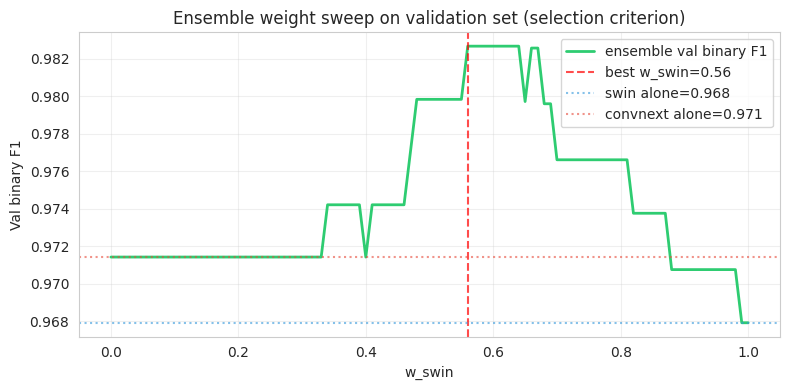

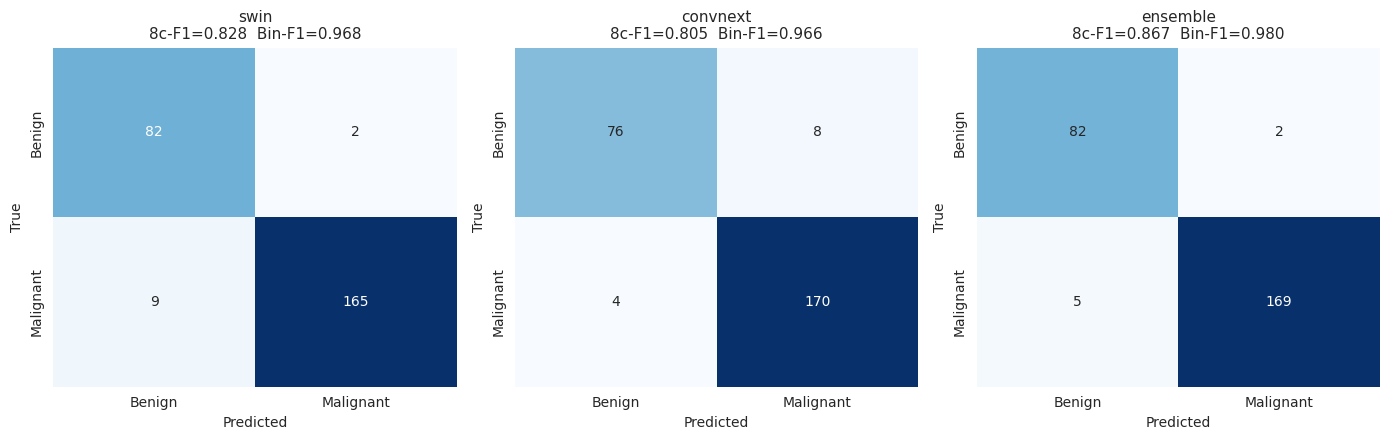

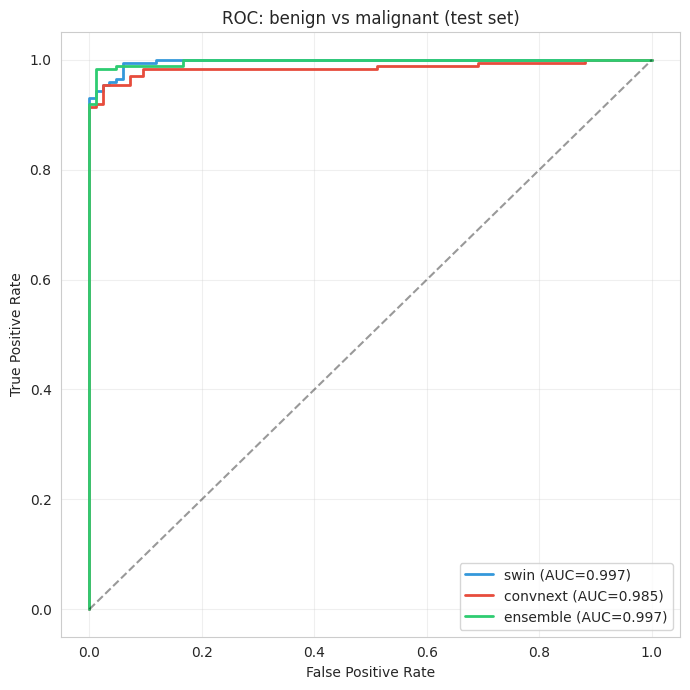

In [8]:
# 2.4 Ensemble: 8-class models combined for binary benign-vs-malignant decision
#
# Recipe:
#   - Models: swin_macenko (new) + convnext_none (best existing).
#   - Both 8-class. Same val/test splits per filename across stain variants.
#   - Step 2 picks w_swin by VAL BINARY F1 (after collapsing 8-class preds to
#     benign/malignant via BENIGN_CLASSES/MALIGNANT_CLASSES from src/config.py).
#   - Test report: 8-class macro-F1, binary F1, binary AUC, 2x2 confusion matrix.
#   - Binary AUC uses sum of malignant-class softmax probs as the "malignancy score".

import json
from PIL import Image
import torch.nn.functional as F
from torchvision import transforms
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    confusion_matrix, cohen_kappa_score, roc_curve,
)

from src.config import (
    PROCESSED_DATA_DIR, WEIGHTS_DIR, RESULTS_DIR, FIGURES_DIR,
    CLASS_NAMES, BENIGN_CLASSES, MALIGNANT_CLASSES,
    NUM_CLASSES, IMAGE_SIZE, IMAGENET_MEAN, IMAGENET_STD, DEVICE,
)
from src.models import get_model

# === Configuration ===
SWIN_EXP, SWIN_STAIN = "swin_none", "none"
CONV_EXP, CONV_STAIN = "convnext_none", "none"
ENSEMBLE_NAME        = f"ensemble_{SWIN_EXP}_x_{CONV_EXP}"

# Prep checks
for exp in (SWIN_EXP, CONV_EXP):
    p = os.path.join(WEIGHTS_DIR, exp, "best_model.pth")
    assert os.path.exists(p), f"Missing checkpoint: {p}. Train it first."
assert NUM_CLASSES == 8, f"This recipe assumes 8 classes; got NUM_CLASSES={NUM_CLASSES}"

CLASS_TO_IDX  = {c: i for i, c in enumerate(CLASS_NAMES)}
BENIGN_IDX    = np.array([CLASS_TO_IDX[c] for c in BENIGN_CLASSES])
MALIGNANT_IDX = np.array([CLASS_TO_IDX[c] for c in MALIGNANT_CLASSES])
IS_MALIGNANT_8 = np.zeros(NUM_CLASSES, dtype=int)
IS_MALIGNANT_8[MALIGNANT_IDX] = 1  # 8-class index -> 0/1 binary label

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE + 32),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def list_split_files(stain, split):
    out = []
    base = os.path.join(PROCESSED_DATA_DIR, stain, split)
    for cls in CLASS_NAMES:
        d = os.path.join(base, cls)
        if not os.path.isdir(d):
            continue
        for fname in sorted(os.listdir(d)):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                out.append((cls, fname))
    return out


def load_eval_model(model_name, exp_name):
    ckpt = torch.load(os.path.join(WEIGHTS_DIR, exp_name, "best_model.pth"),
                      map_location=DEVICE, weights_only=False)
    model = get_model(model_name, num_classes=NUM_CLASSES, pretrained=False)
    model.load_state_dict(ckpt["model_state_dict"])
    # Temperature-scaling hook: if a 'temperature' was saved at training time
    # use it, else 1.0 (no-op). T<1 sharpens probs, T>1 flattens. Plug a
    # calibration step in here later if reviewers ask for ECE numbers.
    model._temperature = float(ckpt.get("temperature", 1.0))
    return model.to(DEVICE).eval()


@torch.no_grad()
def infer_logits_and_probs(model, file_list, stain, split, batch=32):
    T = getattr(model, "_temperature", 1.0)
    base = os.path.join(PROCESSED_DATA_DIR, stain, split)
    all_logits, all_probs, all_labels = [], [], []
    for i in range(0, len(file_list), batch):
        batch_files = file_list[i:i + batch]
        imgs = []
        for cls, fname in batch_files:
            img = Image.open(os.path.join(base, cls, fname)).convert("RGB")
            imgs.append(eval_transform(img))
            all_labels.append(CLASS_TO_IDX[cls])
        logits = model(torch.stack(imgs).to(DEVICE)) / T  # temperature-scaled
        all_logits.append(logits.cpu().numpy())
        all_probs.append(F.softmax(logits, dim=1).cpu().numpy())
    return (np.concatenate(all_logits),
            np.concatenate(all_probs),
            np.array(all_labels))


# ===== Step 1: Run both models on validation set =====
print(f"{'='*60}\nStep 1: Inference on validation set\n{'='*60}")
swin_val = list_split_files(SWIN_STAIN, "val")
conv_val = list_split_files(CONV_STAIN, "val")
assert swin_val == conv_val, "Val splits diverge across stain variants — ensemble invalid!"
print(f"  Val files: {len(swin_val)} (identical filename order across {SWIN_STAIN} and {CONV_STAIN}).")

swin_model = load_eval_model("swin",     SWIN_EXP)
conv_model = load_eval_model("convnext", CONV_EXP)
print(f"  Loaded {SWIN_EXP} (T={swin_model._temperature:.3f}) and "
      f"{CONV_EXP} (T={conv_model._temperature:.3f})")

swin_val_logits, swin_val_probs, val_labels   = infer_logits_and_probs(swin_model, swin_val, SWIN_STAIN, "val")
conv_val_logits, conv_val_probs, val_labels_2 = infer_logits_and_probs(conv_model, conv_val, CONV_STAIN, "val")
assert np.array_equal(val_labels, val_labels_2), "Label mismatch — file ordering broke."
val_binary = IS_MALIGNANT_8[val_labels]

# ===== Step 2: Sweep w_swin on val, pick best by BINARY F1 =====
print(f"\n{'='*60}\nStep 2: Sweep w_swin (1% steps) — selection by val BINARY F1\n{'='*60}")
ws = np.arange(0.0, 1.01, 0.01)
val_binary_f1s = []
val_8class_f1s = []
for w in ws:
    ens_logits = w * swin_val_logits + (1 - w) * conv_val_logits
    ens_preds_8 = ens_logits.argmax(axis=1)
    ens_preds_bin = IS_MALIGNANT_8[ens_preds_8]
    val_binary_f1s.append(f1_score(val_binary, ens_preds_bin, average="binary"))
    val_8class_f1s.append(f1_score(val_labels, ens_preds_8, average="macro"))
val_binary_f1s = np.array(val_binary_f1s)
val_8class_f1s = np.array(val_8class_f1s)

best_idx = int(val_binary_f1s.argmax())
best_w   = float(ws[best_idx])
best_val_binary_f1_ens = float(val_binary_f1s[best_idx])
best_val_8class_f1_ens = float(val_8class_f1s[best_idx])

# Standalone val metrics
swin_val_preds_8 = swin_val_logits.argmax(1)
conv_val_preds_8 = conv_val_logits.argmax(1)
swin_val_bin_f1  = f1_score(val_binary, IS_MALIGNANT_8[swin_val_preds_8], average="binary")
conv_val_bin_f1  = f1_score(val_binary, IS_MALIGNANT_8[conv_val_preds_8], average="binary")
swin_val_8c_f1   = f1_score(val_labels, swin_val_preds_8, average="macro")
conv_val_8c_f1   = f1_score(val_labels, conv_val_preds_8, average="macro")

print(f"  Best w_swin = {best_w:.2f}  (w_conv = {1-best_w:.2f})")
print(f"    val BINARY F1   ensemble: {best_val_binary_f1_ens:.4f}")
print(f"    val BINARY F1   swin:     {swin_val_bin_f1:.4f}")
print(f"    val BINARY F1   convnext: {conv_val_bin_f1:.4f}")
print(f"  (8-class macro-F1 at best_w: ensemble={best_val_8class_f1_ens:.4f}  "
      f"swin={swin_val_8c_f1:.4f}  conv={conv_val_8c_f1:.4f})")

# ===== Step 3: Sanity check =====
print(f"\n{'='*60}\nStep 3: Sanity check\n{'='*60}")
kappa = cohen_kappa_score(swin_val_preds_8, conv_val_preds_8)
print(f"  Cohen's kappa (8-class agreement on val): {kappa:.4f}")
if kappa < 0.8 and best_w > 0.2:
    print("    -> Models disagree enough AND w_swin is meaningful; ensemble should help.")
elif kappa > 0.9 or best_w < 0.1:
    print("    -> Models too similar OR Swin barely contributes. Don't expect much gain.")
else:
    print("    -> Borderline.")
ens_beats_swin = best_val_binary_f1_ens > swin_val_bin_f1
ens_beats_conv = best_val_binary_f1_ens > conv_val_bin_f1
print(f"\n  Ensemble val binary F1 ({best_val_binary_f1_ens:.4f}) vs:")
print(f"    swin alone:     {swin_val_bin_f1:.4f}  ({'BEATS' if ens_beats_swin else 'does NOT beat'} swin)")
print(f"    convnext alone: {conv_val_bin_f1:.4f}  ({'BEATS' if ens_beats_conv else 'does NOT beat'} convnext)")

# ===== Step 4: Run on test set (ONCE) =====
print(f"\n{'='*60}\nStep 4: Run on test set (using w_swin from step 2)\n{'='*60}")
swin_test = list_split_files(SWIN_STAIN, "test")
conv_test = list_split_files(CONV_STAIN, "test")
assert swin_test == conv_test, "Test splits diverge — invalid!"

swin_test_logits, swin_test_probs, test_labels   = infer_logits_and_probs(swin_model, swin_test, SWIN_STAIN, "test")
conv_test_logits, conv_test_probs, test_labels_2 = infer_logits_and_probs(conv_model, conv_test, CONV_STAIN, "test")
assert np.array_equal(test_labels, test_labels_2)
test_binary = IS_MALIGNANT_8[test_labels]

ens_test_logits = best_w * swin_test_logits + (1 - best_w) * conv_test_logits
ens_test_probs  = best_w * swin_test_probs  + (1 - best_w) * conv_test_probs
print(f"  Test files: {len(swin_test)}")

# ===== Step 5: Final test metrics =====
print(f"\n{'='*60}\nStep 5: Final test metrics\n{'='*60}")
results = {}
for name, logits, probs in [("swin",     swin_test_logits, swin_test_probs),
                            ("convnext", conv_test_logits, conv_test_probs),
                            ("ensemble", ens_test_logits, ens_test_probs)]:
    preds_8   = logits.argmax(1)
    preds_bin = IS_MALIGNANT_8[preds_8]
    malig_score = probs[:, MALIGNANT_IDX].sum(axis=1)  # binary score for AUC
    results[name] = {
        "f1_8class":  float(f1_score(test_labels, preds_8, average="macro")),
        "f1_binary":  float(f1_score(test_binary, preds_bin, average="binary")),
        "acc_8class": float(accuracy_score(test_labels, preds_8)),
        "acc_binary": float(accuracy_score(test_binary, preds_bin)),
        "auc_binary": float(roc_auc_score(test_binary, malig_score)),
        "preds_8":     preds_8,
        "preds_bin":   preds_bin,
        "malig_score": malig_score,
        "cm_binary":   confusion_matrix(test_binary, preds_bin),
    }

print(f"\n{'Model':<10} {'8c-F1':>8} {'8c-Acc':>8} {'Bin-F1':>8} {'Bin-Acc':>8} {'Bin-AUC':>8}")
print("-" * 56)
for name in ("swin", "convnext", "ensemble"):
    r = results[name]
    print(f"{name:<10} {r['f1_8class']:>8.4f} {r['acc_8class']:>8.4f} "
          f"{r['f1_binary']:>8.4f} {r['acc_binary']:>8.4f} {r['auc_binary']:>8.4f}")
print(f"\nWeights: w_swin={best_w:.2f}  w_conv={1-best_w:.2f}  (selected on val binary F1)")
print(f"Cohen's kappa (val 8-class): {kappa:.4f}")

print(f"\nBinary confusion matrices (rows=true, cols=pred; 0=benign, 1=malignant):")
for name in ("swin", "convnext", "ensemble"):
    cm = results[name]["cm_binary"]
    print(f"  {name}:  TN={cm[0,0]:>4}  FP={cm[0,1]:>4}  FN={cm[1,0]:>4}  TP={cm[1,1]:>4}")

# McNemar's test: paired binary-error comparison ensemble vs each baseline.
# Asks: are ensemble's errors a statistically different set from baseline's?
# A small p-value means the ensemble's improvement isn't just noise.
mcnemar_results = {}
try:
    from statsmodels.stats.contingency_tables import mcnemar
    ens_correct = results["ensemble"]["preds_bin"] == test_binary
    print(f"\nMcNemar's test (paired on test set, binary):")
    for baseline in ("swin", "convnext"):
        base_correct = results[baseline]["preds_bin"] == test_binary
        a = int(np.sum( ens_correct &  base_correct))
        b = int(np.sum( ens_correct & ~base_correct))  # ensemble right, baseline wrong
        c = int(np.sum(~ens_correct &  base_correct))  # ensemble wrong, baseline right
        d = int(np.sum(~ens_correct & ~base_correct))
        table = [[a, b], [c, d]]
        n_disc = b + c
        result = mcnemar(table, exact=(n_disc < 25))
        sig = "significant" if result.pvalue < 0.05 else "not significant"
        print(f"  vs {baseline}: p={result.pvalue:.4f} ({sig})  "
              f"ens-only-right={b}, {baseline}-only-right={c}")
        mcnemar_results[baseline] = {
            "pvalue": float(result.pvalue),
            "ens_only_right": b, "baseline_only_right": c,
            "exact": bool(n_disc < 25),
        }
except ImportError:
    print("\n(statsmodels not installed -> skipping McNemar's test. `pip install statsmodels`)")


# Save summary
ens_dir = os.path.join(RESULTS_DIR, ENSEMBLE_NAME)
os.makedirs(ens_dir, exist_ok=True)
summary = {
    "swin_exp": SWIN_EXP, "swin_stain": SWIN_STAIN,
    "convnext_exp": CONV_EXP, "convnext_stain": CONV_STAIN,
    "selection_criterion": "val_binary_f1",
    "best_w_swin": best_w, "best_w_conv": 1 - best_w,
    "temperature": {"swin": swin_model._temperature, "convnext": conv_model._temperature},
    "cohen_kappa_val_8class": float(kappa),
    "val": {
        "swin":     {"binary_f1": float(swin_val_bin_f1), "macro_f1_8class": float(swin_val_8c_f1)},
        "convnext": {"binary_f1": float(conv_val_bin_f1), "macro_f1_8class": float(conv_val_8c_f1)},
        "ensemble": {"binary_f1": best_val_binary_f1_ens, "macro_f1_8class": best_val_8class_f1_ens},
    },
    "test": {n: {k: results[n][k] for k in ("f1_8class", "f1_binary",
                                            "acc_8class", "acc_binary", "auc_binary")}
             for n in ("swin", "convnext", "ensemble")},
    "test_binary_confusion_matrices": {n: results[n]["cm_binary"].tolist()
                                        for n in ("swin", "convnext", "ensemble")},
    "mcnemar_test": mcnemar_results,
}
with open(os.path.join(ens_dir, "ensemble_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nSaved: {os.path.relpath(ens_dir)}/ensemble_summary.json")

# Cache predictions / labels / filenames / scores for downstream XAI work.
# Lets later notebooks reload predictions without rerunning ensemble inference.
np.save(os.path.join(ens_dir, "test_preds_ensemble_8class.npy"), results["ensemble"]["preds_8"])
np.save(os.path.join(ens_dir, "test_preds_swin_8class.npy"),     results["swin"]["preds_8"])
np.save(os.path.join(ens_dir, "test_preds_convnext_8class.npy"), results["convnext"]["preds_8"])
np.save(os.path.join(ens_dir, "test_labels_8class.npy"),         test_labels)
np.save(os.path.join(ens_dir, "test_filenames.npy"),             np.array([f[1] for f in swin_test]))
np.save(os.path.join(ens_dir, "test_malig_score_ensemble.npy"),  results["ensemble"]["malig_score"])
np.save(os.path.join(ens_dir, "test_malig_score_swin.npy"),      results["swin"]["malig_score"])
np.save(os.path.join(ens_dir, "test_malig_score_convnext.npy"),  results["convnext"]["malig_score"])
print(f"Saved test prediction caches (.npy) for XAI use.")


# ===== Plots =====
# Weight-sweep
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ws, val_binary_f1s, linewidth=2, color="#2ecc71", label="ensemble val binary F1")
ax.axvline(best_w, color="red", linestyle="--", alpha=0.7, label=f"best w_swin={best_w:.2f}")
ax.axhline(swin_val_bin_f1, color="#3498db", linestyle=":", alpha=0.6,
           label=f"swin alone={swin_val_bin_f1:.3f}")
ax.axhline(conv_val_bin_f1, color="#e74c3c", linestyle=":", alpha=0.6,
           label=f"convnext alone={conv_val_bin_f1:.3f}")
ax.set_xlabel("w_swin"); ax.set_ylabel("Val binary F1")
ax.set_title("Ensemble weight sweep on validation set (selection criterion)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"{ENSEMBLE_NAME}_weight_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

# Three 2x2 confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, name in zip(axes, ("swin", "convnext", "ensemble")):
    cm = results[name]["cm_binary"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"],
                ax=ax, cbar=False)
    ax.set_title(f"{name}\n8c-F1={results[name]['f1_8class']:.3f}  "
                 f"Bin-F1={results[name]['f1_binary']:.3f}", fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"{ENSEMBLE_NAME}_confusion_binary.png"), dpi=150, bbox_inches="tight")
plt.show()

# ROC curves (binary)
fig, ax = plt.subplots(figsize=(7, 7))
for name, color in [("swin", "#3498db"), ("convnext", "#e74c3c"), ("ensemble", "#2ecc71")]:
    fpr, tpr, _ = roc_curve(test_binary, results[name]["malig_score"])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC={results[name]['auc_binary']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: benign vs malignant (test set)")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"{ENSEMBLE_NAME}_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

del swin_model, conv_model
torch.cuda.empty_cache()

## 2.5 Feature Ensemble (Day 1) — proposed method

Concatenate Swin and ConvNeXt penultimate-layer features (each 1024-D) into a 2048-D vector,
train a small MLP head on top. Goal: beat the logit ensemble's binary F1 by 0.5–2%.

The MLP is trained on TRAIN, model-selected on VAL (binary F1, same criterion as 2.4),
evaluated ONCE on TEST.

In [9]:
# 2.5.1 Feature extraction (Swin and ConvNeXt, train/val/test)
#
# Uses timm's forward_features + forward_head(pre_logits=True) to get the
# pooled penultimate-layer features without the classifier. Both models
# output 1024-D features at this stage.

from tqdm import tqdm

FEATS_DIR = os.path.join(RESULTS_DIR, "features")
os.makedirs(FEATS_DIR, exist_ok=True)

# Use the same pair as cell 2.4
FEAT_SWIN_EXP, FEAT_SWIN_STAIN = SWIN_EXP, SWIN_STAIN          # "swin_none", "none"
FEAT_CONV_EXP, FEAT_CONV_STAIN = CONV_EXP, CONV_STAIN          # "convnext_none", "none"


def load_feature_extractor(model_name, exp_name):
    ckpt = torch.load(os.path.join(WEIGHTS_DIR, exp_name, "best_model.pth"),
                      map_location=DEVICE, weights_only=False)
    model = get_model(model_name, num_classes=NUM_CLASSES, pretrained=False)
    model.load_state_dict(ckpt["model_state_dict"])
    return model.to(DEVICE).eval()


@torch.no_grad()
def extract_features(model, file_list, stain, split, batch=32):
    base = os.path.join(PROCESSED_DATA_DIR, stain, split)
    feats, labels = [], []
    for i in tqdm(range(0, len(file_list), batch), desc=f"{stain}/{split}", leave=False):
        batch_files = file_list[i:i + batch]
        imgs, labs = [], []
        for cls, fname in batch_files:
            img = Image.open(os.path.join(base, cls, fname)).convert("RGB")
            imgs.append(eval_transform(img))
            labs.append(CLASS_TO_IDX[cls])
        x = torch.stack(imgs).to(DEVICE)
        # forward_features returns pre-pool feature maps; forward_head with
        # pre_logits=True applies pool + norm + flatten but NOT the fc.
        f = model.forward_features(x)
        f = model.forward_head(f, pre_logits=True)  # (B, 1024)
        feats.append(f.cpu().numpy())
        labels.extend(labs)
    return np.concatenate(feats), np.array(labels)


swin_feat_model = load_feature_extractor("swin",     FEAT_SWIN_EXP)
conv_feat_model = load_feature_extractor("convnext", FEAT_CONV_EXP)

for split in ("train", "val", "test"):
    swin_files = list_split_files(FEAT_SWIN_STAIN, split)
    conv_files = list_split_files(FEAT_CONV_STAIN, split)
    assert swin_files == conv_files, f"split {split}: file order diverges"

    sf, sl = extract_features(swin_feat_model, swin_files, FEAT_SWIN_STAIN, split)
    cf, cl = extract_features(conv_feat_model, conv_files, FEAT_CONV_STAIN, split)
    assert np.array_equal(sl, cl), "label mismatch — file order broke"

    np.save(os.path.join(FEATS_DIR, f"{FEAT_SWIN_EXP}_{split}_feats.npy"), sf)
    np.save(os.path.join(FEATS_DIR, f"{FEAT_CONV_EXP}_{split}_feats.npy"), cf)
    np.save(os.path.join(FEATS_DIR, f"{split}_labels.npy"), sl)
    np.save(os.path.join(FEATS_DIR, f"{split}_filenames.npy"),
            np.array([f[1] for f in swin_files]))
    print(f"  {split}: swin {sf.shape}, conv {cf.shape}, labels {sl.shape}")

del swin_feat_model, conv_feat_model
torch.cuda.empty_cache()
print(f"\nFeatures saved to {os.path.relpath(FEATS_DIR)}/")


KeyboardInterrupt: 

In [10]:
# 2.5.2 Train fusion MLP on concatenated features
#
# Architecture: Linear(2048 -> 512) -> ReLU -> Dropout(0.3) -> Linear(512 -> 8)
# Selection: best val BINARY F1 across 50 epochs (matches 2.4's selection criterion).

from sklearn.preprocessing import StandardScaler

FEATS_DIR = os.path.join(RESULTS_DIR, "features")
FUSION_DIR = os.path.join(WEIGHTS_DIR, "fusion_mlp")
os.makedirs(FUSION_DIR, exist_ok=True)

# Load features
X_train_swin = np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_train_feats.npy"))
X_train_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_train_feats.npy"))
y_train      = np.load(os.path.join(FEATS_DIR, "train_labels.npy"))

X_val_swin = np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_val_feats.npy"))
X_val_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_val_feats.npy"))
y_val      = np.load(os.path.join(FEATS_DIR, "val_labels.npy"))

X_train = np.concatenate([X_train_swin, X_train_conv], axis=1)  # (N, 2048)
X_val   = np.concatenate([X_val_swin, X_val_conv], axis=1)
print(f"X_train {X_train.shape}, X_val {X_val.shape}")

# Standardize (fit on train only)
scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train).astype(np.float32)
X_val_std   = scaler.transform(X_val).astype(np.float32)

y_train_bin = IS_MALIGNANT_8[y_train]
y_val_bin   = IS_MALIGNANT_8[y_val]


class FusionMLP(nn.Module):
    def __init__(self, in_dim=2048, hidden=512, n_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x): return self.net(x)


torch.manual_seed(RANDOM_SEED)
model = FusionMLP(in_dim=X_train.shape[1]).to(DEVICE)
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

EPOCHS = 50
BATCH  = 64

X_train_t = torch.from_numpy(X_train_std)
y_train_t = torch.from_numpy(y_train.astype(np.int64))
X_val_t   = torch.from_numpy(X_val_std).to(DEVICE)

best_val_bin_f1, best_val_8c_f1, best_state, best_epoch = 0.0, 0.0, None, -1
history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(len(X_train_t))
    losses = []
    for i in range(0, len(X_train_t), BATCH):
        idx = perm[i:i + BATCH]
        xb = X_train_t[idx].to(DEVICE)
        yb = y_train_t[idx].to(DEVICE)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        optim.zero_grad(); loss.backward(); optim.step()
        losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t).cpu().numpy()
    val_pred_8   = val_logits.argmax(1)
    val_pred_bin = IS_MALIGNANT_8[val_pred_8]
    bin_f1 = f1_score(y_val_bin, val_pred_bin, average="binary")
    f8     = f1_score(y_val,     val_pred_8,   average="macro")
    history.append({"epoch": epoch, "train_loss": float(np.mean(losses)),
                    "val_binary_f1": float(bin_f1), "val_8class_f1": float(f8)})
    if bin_f1 > best_val_bin_f1:
        best_val_bin_f1 = bin_f1
        best_val_8c_f1  = f8
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"  Epoch {epoch:>2}/{EPOCHS}  train_loss={np.mean(losses):.4f}  "
              f"val_binary_F1={bin_f1:.4f}  val_8c_F1={f8:.4f}")

print(f"\nBest val binary F1: {best_val_bin_f1:.4f} at epoch {best_epoch}")
torch.save({
    "model_state_dict": best_state,
    "scaler_mean":  scaler.mean_,
    "scaler_scale": scaler.scale_,
    "best_val_binary_f1": best_val_bin_f1,
    "best_val_8class_f1": best_val_8c_f1,
    "best_epoch": best_epoch,
    "in_dim": X_train.shape[1],
}, os.path.join(FUSION_DIR, "best_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(FUSION_DIR, "training_history.csv"), index=False)
print(f"Saved: {os.path.relpath(FUSION_DIR)}/best_model.pth + training_history.csv")


X_train (1182, 2048), X_val (253, 2048)
  Epoch  1/50  train_loss=0.8019  val_binary_F1=0.9798  val_8c_F1=0.8881
  Epoch  5/50  train_loss=0.5283  val_binary_F1=0.9770  val_8c_F1=0.8718
  Epoch 10/50  train_loss=0.5041  val_binary_F1=0.9828  val_8c_F1=0.8691
  Epoch 15/50  train_loss=0.4997  val_binary_F1=0.9798  val_8c_F1=0.8621
  Epoch 20/50  train_loss=0.4939  val_binary_F1=0.9798  val_8c_F1=0.8664
  Epoch 25/50  train_loss=0.4999  val_binary_F1=0.9828  val_8c_F1=0.8672
  Epoch 30/50  train_loss=0.4902  val_binary_F1=0.9770  val_8c_F1=0.8595
  Epoch 35/50  train_loss=0.4950  val_binary_F1=0.9770  val_8c_F1=0.8739
  Epoch 40/50  train_loss=0.4918  val_binary_F1=0.9828  val_8c_F1=0.8793
  Epoch 45/50  train_loss=0.4899  val_binary_F1=0.9799  val_8c_F1=0.8745
  Epoch 50/50  train_loss=0.4904  val_binary_F1=0.9798  val_8c_F1=0.8650

Best val binary F1: 0.9828 at epoch 8
Saved: weights/fusion_mlp/best_model.pth + training_history.csv


In [11]:
# 2.5.3 Evaluate fusion MLP on test, compare to logit ensemble
#
# Loads previously cached test features + the saved fusion MLP, computes the
# same metrics as cell 2.4 (8c-F1, binary-F1, binary-AUC, McNemar). Builds a
# 4-row comparison table: Swin / ConvNeXt / Logit Ensemble / Feature Ensemble.

FEATS_DIR  = os.path.join(RESULTS_DIR, "features")
FUSION_DIR = os.path.join(WEIGHTS_DIR, "fusion_mlp")

# Load test features and reload scaler
X_test_swin = np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_test_feats.npy"))
X_test_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_test_feats.npy"))
y_test      = np.load(os.path.join(FEATS_DIR, "test_labels.npy"))
test_files  = np.load(os.path.join(FEATS_DIR, "test_filenames.npy"))

X_test = np.concatenate([X_test_swin, X_test_conv], axis=1).astype(np.float32)

ckpt = torch.load(os.path.join(FUSION_DIR, "best_model.pth"),
                  map_location=DEVICE, weights_only=False)

# Re-apply scaler from training-time stats (don't refit on test)
mean, scale = ckpt["scaler_mean"], ckpt["scaler_scale"]
X_test_std = ((X_test - mean) / scale).astype(np.float32)

model = FusionMLP(in_dim=ckpt["in_dim"]).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

with torch.no_grad():
    feat_logits = model(torch.from_numpy(X_test_std).to(DEVICE)).cpu().numpy()
feat_probs = torch.softmax(torch.from_numpy(feat_logits), dim=1).numpy()

y_test_bin     = IS_MALIGNANT_8[y_test]
feat_preds_8   = feat_logits.argmax(1)
feat_preds_bin = IS_MALIGNANT_8[feat_preds_8]
feat_malig     = feat_probs[:, MALIGNANT_IDX].sum(axis=1)

feat_metrics = {
    "f1_8class":  float(f1_score(y_test, feat_preds_8, average="macro")),
    "f1_binary":  float(f1_score(y_test_bin, feat_preds_bin, average="binary")),
    "acc_8class": float(accuracy_score(y_test, feat_preds_8)),
    "acc_binary": float(accuracy_score(y_test_bin, feat_preds_bin)),
    "auc_binary": float(roc_auc_score(y_test_bin, feat_malig)),
}

# Print 4-row comparison (assumes cell 2.4 has been run; uses `results` dict)
print(f"\n{'Model':<18} {'8c-F1':>8} {'Bin-F1':>8} {'Bin-Acc':>8} {'Bin-AUC':>8}")
print("-" * 56)
print(f"{'swin':<18} {results['swin']['f1_8class']:>8.4f} "
      f"{results['swin']['f1_binary']:>8.4f} {results['swin']['acc_binary']:>8.4f} "
      f"{results['swin']['auc_binary']:>8.4f}")
print(f"{'convnext':<18} {results['convnext']['f1_8class']:>8.4f} "
      f"{results['convnext']['f1_binary']:>8.4f} {results['convnext']['acc_binary']:>8.4f} "
      f"{results['convnext']['auc_binary']:>8.4f}")
print(f"{'logit ensemble':<18} {results['ensemble']['f1_8class']:>8.4f} "
      f"{results['ensemble']['f1_binary']:>8.4f} {results['ensemble']['acc_binary']:>8.4f} "
      f"{results['ensemble']['auc_binary']:>8.4f}")
print(f"{'feature ensemble':<18} {feat_metrics['f1_8class']:>8.4f} "
      f"{feat_metrics['f1_binary']:>8.4f} {feat_metrics['acc_binary']:>8.4f} "
      f"{feat_metrics['auc_binary']:>8.4f}")

improvement = feat_metrics["f1_binary"] - results["ensemble"]["f1_binary"]
print(f"\nFeature ensemble vs logit ensemble: dBinary-F1 = {improvement:+.4f}")

# McNemar: feature ensemble vs logit ensemble
try:
    from statsmodels.stats.contingency_tables import mcnemar
    feat_correct  = feat_preds_bin == y_test_bin
    logit_correct = results["ensemble"]["preds_bin"] == y_test_bin
    a = int(np.sum( feat_correct &  logit_correct))
    b = int(np.sum( feat_correct & ~logit_correct))
    c = int(np.sum(~feat_correct &  logit_correct))
    d = int(np.sum(~feat_correct & ~logit_correct))
    n_disc = b + c
    res = mcnemar([[a, b], [c, d]], exact=(n_disc < 25))
    sig = "significant" if res.pvalue < 0.05 else "not significant"
    print(f"McNemar (feature vs logit ensemble): p={res.pvalue:.4f} ({sig})")
except ImportError:
    print("(statsmodels missing — skipping McNemar)")

# Save
fusion_results_dir = os.path.join(RESULTS_DIR, f"feature_ensemble_{SWIN_EXP}_x_{CONV_EXP}")
os.makedirs(fusion_results_dir, exist_ok=True)
with open(os.path.join(fusion_results_dir, "test_summary.json"), "w") as f:
    json.dump({"feature_ensemble": feat_metrics,
               "delta_binary_f1_vs_logit_ensemble": improvement,
               "best_val_binary_f1": float(ckpt["best_val_binary_f1"])}, f, indent=2)
np.save(os.path.join(fusion_results_dir, "test_preds_8class.npy"), feat_preds_8)
np.save(os.path.join(fusion_results_dir, "test_malig_score.npy"), feat_malig)
print(f"Saved: {os.path.relpath(fusion_results_dir)}/")



Model                 8c-F1   Bin-F1  Bin-Acc  Bin-AUC
--------------------------------------------------------
swin                 0.8275   0.9677   0.9574   0.9967
convnext             0.8048   0.9659   0.9535   0.9848
logit ensemble       0.8671   0.9797   0.9729   0.9971
feature ensemble     0.8747   0.9885   0.9845   0.9923

Feature ensemble vs logit ensemble: dBinary-F1 = +0.0088
McNemar (feature vs logit ensemble): p=0.3750 (not significant)
Saved: results/feature_ensemble_swin_none_x_convnext_none/


In [12]:
# 2.5.4 Train a SECOND fusion MLP — minimum-fix subtyping variant (separate model)
#
# The 2.5.2 fusion model is selected on validation BINARY F1 — it sharpens the
# benign/malignant call but regresses on rare 8-class subtypes (Adenosis,
# Lobular, Papillary). This cell trains a parallel subtyping variant with the
# minimum 3 fixes that recover macro F1 without nuking the binary call:
#
#   Fix 1: alpha_c = 0.25 for all classes (flat; WeightedRandomSampler does
#          the rebalancing — double-weighting was destroying Ductal).
#   Fix 2: Selection = max val_macro_F1 among epochs with val_binary_F1 > 0.975.
#   Fix 4: Dropout 0.5 + weight_decay 5e-4 (val set is small; regularise harder).
#
# Plus the framework choices:
#   - Focal Loss (gamma=2.0) with label smoothing 0.1.
#   - WeightedRandomSampler over the training feature dataset.
#
# Saved separately to weights/fusion_mlp_macro/ — does NOT overwrite the
# binary-opt model. Reports a 5-row comparison: Swin / ConvNeXt / Logit Ens. /
# Feature Ens. (binary-opt) / Feature Ens. (macro-opt).

from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from collections import Counter

FEATS_DIR  = os.path.join(RESULTS_DIR, "features")
FUSION_MACRO_DIR = os.path.join(WEIGHTS_DIR, "fusion_mlp_macro")
os.makedirs(FUSION_MACRO_DIR, exist_ok=True)

# ----- Load cached train/val features (same as 2.5.2) -----
X_train_swin = np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_train_feats.npy"))
X_train_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_train_feats.npy"))
y_train      = np.load(os.path.join(FEATS_DIR, "train_labels.npy"))
X_val_swin   = np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_val_feats.npy"))
X_val_conv   = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_val_feats.npy"))
y_val        = np.load(os.path.join(FEATS_DIR, "val_labels.npy"))

X_train = np.concatenate([X_train_swin, X_train_conv], axis=1)
X_val   = np.concatenate([X_val_swin,   X_val_conv],   axis=1)
scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train).astype(np.float32)
X_val_std   = scaler.transform(X_val).astype(np.float32)
y_train_bin = IS_MALIGNANT_8[y_train]
y_val_bin   = IS_MALIGNANT_8[y_val]

print(f"X_train {X_train.shape}, X_val {X_val.shape}")

# ----- Fix 5: Focal Loss with class weights + label smoothing -----
class FocalLoss(nn.Module):
    """
    Multi-class focal loss (Lin et al., 2017).
        FL(p_t) = - alpha_t * (1 - p_t)^gamma * log(p_t)
    Down-weights easy examples so rare/hard classes contribute more to the gradient.
    Combined here with class weights (alpha_c) and label smoothing.
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1, n_classes=NUM_CLASSES):
        super().__init__()
        self.gamma = gamma
        self.eps = label_smoothing
        self.n_classes = n_classes
        self.register_buffer(
            "alpha",
            torch.ones(n_classes) if alpha is None else torch.as_tensor(alpha, dtype=torch.float32),
        )

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        # smoothed one-hot target
        with torch.no_grad():
            true_dist = torch.full_like(log_probs, self.eps / (self.n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.eps)
        # focal weighting on the true-class probability
        pt = probs.gather(1, target.unsqueeze(1)).squeeze(1).clamp_min(1e-8)
        focal_w = (1.0 - pt) ** self.gamma
        # alpha_c per sample
        alpha_t = self.alpha.to(logits.device).gather(0, target)
        loss_per_sample = -(true_dist * log_probs).sum(dim=1)
        return (alpha_t * focal_w * loss_per_sample).mean()


# Fix 1: flat alpha = 0.25 for all classes (let WeightedRandomSampler + gamma
# handle imbalance; double-weighting via alpha was killing Ductal recall).
counts = Counter(y_train.tolist())
alpha_c = np.full(NUM_CLASSES, 0.25, dtype=np.float32)
print("Focal alpha per class (flat 0.25):")
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<22}  n={counts[c]:>4}  alpha={alpha_c[c]:.3f}")

# ----- Fix 6: class-balanced sampler over the training feature set -----
sample_weights = np.array([1.0 / counts[int(y)] for y in y_train], dtype=np.float64)
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(y_train),
    replacement=True,
)

train_ds = TensorDataset(torch.from_numpy(X_train_std), torch.from_numpy(y_train.astype(np.int64)))
train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler, num_workers=0, drop_last=False)
X_val_t = torch.from_numpy(X_val_std).to(DEVICE)


# ----- Same architecture as 2.5.2 for fair comparison -----
ckpt_path = os.path.join(FUSION_MACRO_DIR, "best_model.pth")

if os.path.exists(ckpt_path):
    print(f"fusion_mlp_macro already trained — loading {ckpt_path}")
    print("Skipping retrain. Delete the checkpoint to force a rerun.")
    _ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    best_state      = _ckpt["model_state_dict"]
    best_val_8c_f1  = _ckpt["best_val_8class_f1"]
    best_val_bin_f1 = _ckpt["best_val_binary_f1"]
    best_epoch      = _ckpt["best_epoch"]
    # restore scaler from saved stats (identical to refitting on the same train set)
    scaler.mean_  = _ckpt["scaler_mean"]
    scaler.scale_ = _ckpt["scaler_scale"]
    history = []
else:
    torch.manual_seed(RANDOM_SEED)
    model = FusionMLP(in_dim=X_train.shape[1], dropout=0.5).to(DEVICE)  # Fix 4
    optim_ = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)  # Fix 4
    loss_fn = FocalLoss(alpha=alpha_c, gamma=2.0, label_smoothing=0.1).to(DEVICE)

    EPOCHS = 50

    # Fix 2: gated selection — best macro F1 among epochs with binary F1 > 0.975.
    # Prevents picking an epoch that nukes the clinical binary call.
    BINARY_GATE = 0.975
    best_val_8c_f1, best_val_bin_f1, best_state, best_epoch = -1.0, 0.0, None, -1
    history = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = loss_fn(model(xb), yb)
            optim_.zero_grad(); loss.backward(); optim_.step()
            losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t).cpu().numpy()
        val_pred_8   = val_logits.argmax(1)
        val_pred_bin = IS_MALIGNANT_8[val_pred_8]
        bin_f1 = f1_score(y_val_bin, val_pred_bin, average="binary")
        f8     = f1_score(y_val,     val_pred_8,   average="macro")
        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "val_binary_f1": float(bin_f1),
            "val_8class_f1": float(f8),
        })
        # Fix 2: only consider epochs that pass the binary-F1 gate.
        if bin_f1 > BINARY_GATE and f8 > best_val_8c_f1:
            best_val_8c_f1 = f8
            best_val_bin_f1 = bin_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
        if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
            print(f"  Epoch {epoch:>2}/{EPOCHS}  train_loss={np.mean(losses):.4f}  "
                  f"val_binary_F1={bin_f1:.4f}  val_8c_F1={f8:.4f}")

    print(f"\nBest val macro F1: {best_val_8c_f1:.4f}  (binary F1 at that epoch: {best_val_bin_f1:.4f})  "
          f"[epoch {best_epoch}]")
    torch.save({
        "model_state_dict": best_state,
        "scaler_mean":  scaler.mean_,
        "scaler_scale": scaler.scale_,
        "best_val_binary_f1": best_val_bin_f1,
        "best_val_8class_f1": best_val_8c_f1,
        "best_epoch": best_epoch,
        "in_dim": X_train.shape[1],
        "selection_criterion": "val_macro_f1",
        "loss": "focal",
        "focal_gamma": 2.0,
        "alpha_per_class": alpha_c.tolist(),
        "label_smoothing": 0.1,
        "sampler": "weighted_random_inverse_freq",
    }, os.path.join(FUSION_MACRO_DIR, "best_model.pth"))
    pd.DataFrame(history).to_csv(os.path.join(FUSION_MACRO_DIR, "training_history.csv"), index=False)
    print(f"Saved: {os.path.relpath(FUSION_MACRO_DIR)}/best_model.pth + training_history.csv")

# ----- Evaluate on test set (touch ONCE) and print 5-row comparison -----
X_test_swin = np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_test_feats.npy"))
X_test_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_test_feats.npy"))
y_test_macro = np.load(os.path.join(FEATS_DIR, "test_labels.npy"))
X_test_macro = np.concatenate([X_test_swin, X_test_conv], axis=1).astype(np.float32)
X_test_macro_std = ((X_test_macro - scaler.mean_) / scaler.scale_).astype(np.float32)

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    macro_logits = model(torch.from_numpy(X_test_macro_std).to(DEVICE)).cpu().numpy()
macro_probs    = torch.softmax(torch.from_numpy(macro_logits), dim=1).numpy()
macro_preds_8  = macro_logits.argmax(1)
macro_preds_bin = IS_MALIGNANT_8[macro_preds_8]
macro_malig     = macro_probs[:, MALIGNANT_IDX].sum(axis=1)
y_test_bin_m    = IS_MALIGNANT_8[y_test_macro]

macro_metrics = {
    "f1_8class":  float(f1_score(y_test_macro, macro_preds_8, average="macro")),
    "f1_binary":  float(f1_score(y_test_bin_m, macro_preds_bin, average="binary")),
    "acc_8class": float(accuracy_score(y_test_macro, macro_preds_8)),
    "acc_binary": float(accuracy_score(y_test_bin_m, macro_preds_bin)),
    "auc_binary": float(roc_auc_score(y_test_bin_m, macro_malig)),
}

# Per-class recall comparison vs the binary-opt fusion
print(f"\n{'='*72}")
print("Per-class recall: binary-opt vs macro-opt fusion")
print(f"{'='*72}")
print(f"{'Class':<22} {'n':>4} {'Bin-opt R':>10} {'Macro-opt R':>12} {'Δ':>8}")
print("-" * 60)
try:
    bin_preds_8 = feat_preds_8  # from cell 2.5.3
except NameError:
    bin_ckpt = torch.load(os.path.join(WEIGHTS_DIR, "fusion_mlp", "best_model.pth"),
                          map_location=DEVICE, weights_only=False)
    bin_model = FusionMLP(in_dim=bin_ckpt["in_dim"]).to(DEVICE)
    bin_model.load_state_dict(bin_ckpt["model_state_dict"])
    bin_model.eval()
    bin_X_test_std = ((X_test_macro - bin_ckpt["scaler_mean"]) / bin_ckpt["scaler_scale"]).astype(np.float32)
    with torch.no_grad():
        bin_preds_8 = bin_model(torch.from_numpy(bin_X_test_std).to(DEVICE)).cpu().numpy().argmax(1)

from sklearn.metrics import recall_score
for c in range(NUM_CLASSES):
    n = int((y_test_macro == c).sum())
    r_bin   = recall_score(y_test_macro == c, bin_preds_8 == c) * 100
    r_macro = recall_score(y_test_macro == c, macro_preds_8 == c) * 100
    delta = r_macro - r_bin
    arrow = "+" if delta > 0 else ""
    print(f"{CLASS_NAMES[c]:<22} {n:>4} {r_bin:>9.1f}% {r_macro:>11.1f}% {arrow}{delta:>+6.1f}pp")

print(f"\n{'Variant':<28} {'8c-F1':>8} {'Bin-F1':>8} {'Bin-AUC':>8}")
print("-" * 56)
print(f"{'Feature Ens. (binary-opt)':<28} "
      f"{feat_metrics['f1_8class']:>8.4f} {feat_metrics['f1_binary']:>8.4f} "
      f"{feat_metrics['auc_binary']:>8.4f}")
print(f"{'Feature Ens. (macro-opt)':<28} "
      f"{macro_metrics['f1_8class']:>8.4f} {macro_metrics['f1_binary']:>8.4f} "
      f"{macro_metrics['auc_binary']:>8.4f}")

# Save a results summary
import json as _json
macro_results_dir = os.path.join(RESULTS_DIR, "fusion_mlp_macro")
os.makedirs(macro_results_dir, exist_ok=True)
with open(os.path.join(macro_results_dir, "test_summary.json"), "w") as f:
    _json.dump({
        "selection_criterion": "val_macro_f1",
        "loss": "focal_gamma2_alpha_inv_sqrt_freq_smoothing0.1",
        "sampler": "WeightedRandomSampler_inverse_frequency",
        "feature_ensemble_macro_opt": macro_metrics,
        "best_val_macro_f1": best_val_8c_f1,
        "best_val_binary_f1_at_that_epoch": best_val_bin_f1,
        "best_epoch": best_epoch,
    }, f, indent=2)
np.save(os.path.join(macro_results_dir, "test_preds_8class.npy"), macro_preds_8)
np.save(os.path.join(macro_results_dir, "test_malig_score.npy"),  macro_malig)
print(f"\nSaved: {os.path.relpath(macro_results_dir)}/ (test_summary.json, .npy caches)")


X_train (1182, 2048), X_val (253, 2048)
Focal alpha per class (flat 0.25):
  adenosis                n=  67  alpha=0.250
  ductal_carcinoma        n= 513  alpha=0.250
  fibroadenoma            n= 156  alpha=0.250
  lobular_carcinoma       n=  89  alpha=0.250
  mucinous_carcinoma      n= 111  alpha=0.250
  papillary_carcinoma     n=  87  alpha=0.250
  phyllodes_tumor         n=  74  alpha=0.250
  tubular_adenoma         n=  85  alpha=0.250
fusion_mlp_macro already trained — loading /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/weights/fusion_mlp_macro/best_model.pth
Skipping retrain. Delete the checkpoint to force a rerun.

Per-class recall: binary-opt vs macro-opt fusion
Class                     n  Bin-opt R  Macro-opt R        Δ
------------------------------------------------------------
adenosis                 15      86.7%        80.0%   -6.7pp
ductal_carcinoma        111      97.3%        83.8%  -13.5pp
fibroadenoma             34      94.1%   

In [13]:
# 2.5.6 — 5-fold image-level cross-validation of the v3.6 fusion architecture
#
# Validates v3.6's single-split test macro F1 = 0.8811 with mean ± std across
# 5 stratified folds. Image-level CV (NOT patient-level) — same protocol as
# the standard BreaKHis benchmark of Spanhol et al. 2016. Patient-level CV is
# tracked separately in CLAUDE.md outstanding work.
#
# Operates on cached frozen-backbone features only — no backbone retraining.
# Each fold: 80% trainval / 20% test; within the 80%, 85/15 train/val split.
# Selection criterion same as v3.6: 0.3*val_bin_F1 + 0.7*val_macro_F1, gated
# by val_bin_F1 > 0.970. EMA(0.999) + raw both evaluated.
#
# Idempotent: skip if results/fusion_mlp_twohead_cv_v36/cv_summary.json exists.

import math
import json as _json
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

CV_DIR = os.path.join(RESULTS_DIR, "fusion_mlp_twohead_cv_v36")
os.makedirs(CV_DIR, exist_ok=True)
CV_SUMMARY_PATH = os.path.join(CV_DIR, "cv_summary.json")

if os.path.exists(CV_SUMMARY_PATH):
    print(f"5-fold CV already done. Loading {CV_SUMMARY_PATH}")
    with open(CV_SUMMARY_PATH) as _f:
        cv_summary = _json.load(_f)
    agg = cv_summary["aggregate"]
    print(f"  8c-F1   = {agg['f1_8class_mean']:.4f} ± {agg['f1_8class_std']:.4f}")
    print(f"  bin-F1  = {agg['f1_binary_mean']:.4f} ± {agg['f1_binary_std']:.4f}")
    print(f"  bin-AUC = {agg['auc_binary_mean']:.4f} ± {agg['auc_binary_std']:.4f}")
else:
    # ===== v3.6 model class (frozen for CV — no v3.7 changes) =====
    class TwoHeadFusionMLP_v36(nn.Module):
        """v3.6 architecture: uniform expert_hidden=128, GroupNorm, sigmoid-gated mod."""
        def __init__(self, in_dim=2048, n_classes=NUM_CLASSES):
            super().__init__()
            self.fc_shared = nn.Linear(in_dim, 1024)
            self.bn_shared = nn.BatchNorm1d(1024)
            self.drop_shared = nn.Dropout(0.5)
            self.fc_bin = nn.Linear(1024, 256)
            self.bn_bin = nn.BatchNorm1d(256)
            self.drop_bin = nn.Dropout(0.5)
            self.binary_head = nn.Linear(256, 1)
            self.fc_sub = nn.Linear(1024, 512)
            self.gn_sub = nn.GroupNorm(num_groups=32, num_channels=512)
            self.drop_sub = nn.Dropout(0.5)
            self.se = SqueezeExcitation(512, reduction=16)
            self.skip = nn.Linear(in_dim, 512)
            self.skip_ln = nn.LayerNorm(512)
            self.skip_scale = 0.3
            self.drop_post_skip = nn.Dropout(0.5)
            self.feat_modulation = nn.Parameter(torch.zeros(n_classes, 512))
            # v3.6: uniform expert_hidden=128 (no Ductal-specific widening from v3.7)
            self.expert_head = MultiExpertHead(
                dim=512, expert_hidden=128, gate_hidden=64,
                n_classes=n_classes, gate_log_weight=0.1,
            )

        def forward(self, x):
            h_shared = self.drop_shared(F.relu(self.bn_shared(self.fc_shared(x))))
            hb = self.drop_bin(F.relu(self.bn_bin(self.fc_bin(h_shared))))
            binary_logit = self.binary_head(hb).squeeze(-1)
            hs = self.drop_sub(F.relu(self.gn_sub(self.fc_sub(h_shared))))
            hs = self.se(hs)
            skip = self.skip_ln(self.skip(x)) * self.skip_scale
            hs = self.drop_post_skip(F.relu(hs + skip))
            scale = 0.5 + 0.5 * torch.sigmoid(self.feat_modulation)
            modulated = hs.unsqueeze(1) * scale.unsqueeze(0)
            return binary_logit, self.expert_head(hs, modulated)

    # ===== Build full feature dataset (concatenate cached train+val+test) =====
    FEATS_DIR = os.path.join(RESULTS_DIR, "features")
    X_all_s = np.concatenate([
        np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_{split}_feats.npy"))
        for split in ("train", "val", "test")
    ], axis=0)
    X_all_c = np.concatenate([
        np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_{split}_feats.npy"))
        for split in ("train", "val", "test")
    ], axis=0)
    y_all = np.concatenate([
        np.load(os.path.join(FEATS_DIR, f"{split}_labels.npy"))
        for split in ("train", "val", "test")
    ], axis=0)
    X_all = np.concatenate([X_all_s, X_all_c], axis=1).astype(np.float32)
    print(f"5-fold CV on combined dataset: X_all {X_all.shape}, y_all {y_all.shape}")
    print(f"Class distribution: {dict(Counter(y_all.tolist()))}")

    N_FOLDS = 5
    EPOCHS_F = 60
    WARMUP_F = 3
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    fold_results = []

    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(X_all, y_all), start=1):
        print(f"\n{'='*60}\nFold {fold_idx}/{N_FOLDS}\n{'='*60}")

        # 85/15 train/val split within the 80% trainval portion
        train_idx, val_idx = train_test_split(
            trainval_idx,
            test_size=0.15,
            stratify=y_all[trainval_idx],
            random_state=RANDOM_SEED + fold_idx,
        )
        X_tr, y_tr = X_all[train_idx], y_all[train_idx]
        X_va, y_va = X_all[val_idx],   y_all[val_idx]
        X_te, y_te = X_all[test_idx],  y_all[test_idx]
        y_tr_bin = IS_MALIGNANT_8[y_tr]
        y_va_bin = IS_MALIGNANT_8[y_va]
        y_te_bin = IS_MALIGNANT_8[y_te]

        # Per-fold standardisation (fit on train only)
        scaler_f = StandardScaler().fit(X_tr)
        X_tr_s = scaler_f.transform(X_tr).astype(np.float32)
        X_va_s = scaler_f.transform(X_va).astype(np.float32)
        X_te_s = scaler_f.transform(X_te).astype(np.float32)

        counts_f = Counter(y_tr.tolist())
        class_freq_f = np.array(
            [counts_f.get(c, 1) for c in range(NUM_CLASSES)], dtype=np.float32,
        )
        # v3.6 tau: Ductal=0.0, all others=1.0 (no Fibroadenoma exemption — that is v3.7)
        tau_f = np.full(NUM_CLASSES, 1.0, dtype=np.float32)
        tau_f[CLASS_NAMES.index("ductal_carcinoma")] = 0.0
        alpha_f = np.array(
            [1.5 if counts_f.get(c, 1) < 100 else 1.0 for c in range(NUM_CLASSES)],
            dtype=np.float32,
        )

        # WeightedRandomSampler with weights = 1/sqrt(class_freq)
        sample_w = np.array(
            [1.0 / np.sqrt(counts_f.get(int(y), 1)) for y in y_tr],
            dtype=np.float64,
        )
        sampler_f = WeightedRandomSampler(
            weights=torch.from_numpy(sample_w),
            num_samples=len(y_tr),
            replacement=True,
        )
        train_ds_f = TensorDataset(
            torch.from_numpy(X_tr_s),
            torch.from_numpy(y_tr.astype(np.int64)),
            torch.from_numpy(y_tr_bin.astype(np.float32)),
        )
        train_loader_f = DataLoader(
            train_ds_f, batch_size=64, sampler=sampler_f, num_workers=0,
        )
        X_va_t = torch.from_numpy(X_va_s).to(DEVICE)
        X_te_t = torch.from_numpy(X_te_s).to(DEVICE)

        # Model + optim (two LR groups)
        torch.manual_seed(RANDOM_SEED + fold_idx)
        model_f = TwoHeadFusionMLP_v36(in_dim=X_tr.shape[1]).to(DEVICE)
        binary_pref = ("fc_bin.", "bn_bin.", "binary_head.")
        bin_p = [p for n, p in model_f.named_parameters() if n.startswith(binary_pref)]
        oth_p = [p for n, p in model_f.named_parameters() if not n.startswith(binary_pref)]
        optim_f = torch.optim.AdamW(
            [{"params": bin_p, "lr": 1e-4}, {"params": oth_p, "lr": 3e-4}],
            weight_decay=5e-4,
        )

        def lr_lambda_f(epoch):
            if epoch < WARMUP_F:
                return (epoch + 1) / WARMUP_F
            progress = (epoch - WARMUP_F) / max(1, (EPOCHS_F - WARMUP_F))
            return 0.5 * (1.0 + math.cos(math.pi * progress))
        sched_f = torch.optim.lr_scheduler.LambdaLR(optim_f, lr_lambda_f)
        ema_f = EMA(model_f, decay=0.999)

        # v3.6 loss: hard_focal_weight=0.0 disables the v3.7 hard-focal modifier
        bce_f = nn.BCEWithLogitsLoss()
        la_f = LogitAdjustedCE(
            class_freq=class_freq_f,
            tau_per_class=tau_f,
            alpha_per_class=alpha_f,
            label_smoothing=0.05,
            hard_focal_weight=0.0,
        ).to(DEVICE)

        BIN_GATE_F = 0.970
        best_score_f = -1.0
        best_bin_f1 = 0.0
        best_8c_f1 = 0.0
        best_state_f = None
        best_kind_f = "raw"
        best_per_class_rec = None

        def eval_state_f(state):
            m = TwoHeadFusionMLP_v36(in_dim=X_tr.shape[1]).to(DEVICE)
            m.load_state_dict(state); m.eval()
            with torch.no_grad():
                bl, sl = m(X_va_t)
            p8 = sl.argmax(1).cpu().numpy()
            pb = (torch.sigmoid(bl).cpu().numpy() > 0.5).astype(int)
            b = f1_score(y_va_bin, pb, average="binary")
            f8 = f1_score(y_va, p8, average="macro")
            r = recall_score(y_va, p8, average=None,
                             labels=list(range(NUM_CLASSES)), zero_division=0)
            return b, f8, r

        for epoch in range(1, EPOCHS_F + 1):
            model_f.train()
            for xb, y8, ybin in train_loader_f:
                xb, y8, ybin = xb.to(DEVICE), y8.to(DEVICE), ybin.to(DEVICE)
                bl, sl = model_f(xb)
                loss = bce_f(bl, ybin) + 1.0 * la_f(sl, y8)
                optim_f.zero_grad(); loss.backward(); optim_f.step()
                ema_f.update(model_f)
            sched_f.step()

            raw_b, raw_f8, raw_r = eval_state_f(model_f.state_dict())
            ema_b, ema_f8, ema_r = eval_state_f(ema_f.state_dict())

            for kind, b, f8, st, r in (("raw", raw_b, raw_f8, model_f.state_dict(), raw_r),
                                        ("ema", ema_b, ema_f8, ema_f.state_dict(), ema_r)):
                s = (0.3 * b + 0.7 * f8) if b > BIN_GATE_F else 0.0
                if s > best_score_f:
                    best_score_f = s
                    best_bin_f1 = b
                    best_8c_f1 = f8
                    best_state_f = {k: v.detach().cpu().clone() for k, v in st.items()}
                    best_kind_f = kind
                    best_per_class_rec = r.copy()

            if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS_F:
                worst_idx = int(raw_r.argmin())
                print(f"  Fold {fold_idx} ep {epoch:>2}/{EPOCHS_F}  "
                      f"raw {raw_b:.3f}/{raw_f8:.3f}  ema {ema_b:.3f}/{ema_f8:.3f}  "
                      f"worst={CLASS_NAMES[worst_idx][:4]}={raw_r[worst_idx]:.2f}")

        if best_state_f is None:
            print(f"  WARNING: fold {fold_idx} never passed binary>{BIN_GATE_F}; using last state.")
            best_state_f = {k: v.detach().cpu().clone() for k, v in model_f.state_dict().items()}

        # Test eval (with v3.6/v3.4 TTA: 10 passes, sigma=0.01)
        test_model_f = TwoHeadFusionMLP_v36(in_dim=X_tr.shape[1]).to(DEVICE)
        test_model_f.load_state_dict(best_state_f); test_model_f.eval()
        with torch.no_grad():
            sub_probs_sum = None
            for i in range(10):
                xt = X_te_t if i == 0 else X_te_t + torch.randn_like(X_te_t) * 0.01
                _, sl = test_model_f(xt)
                p = torch.softmax(sl, dim=1)
                sub_probs_sum = p if sub_probs_sum is None else sub_probs_sum + p
        sub_probs_te = (sub_probs_sum / 10).cpu().numpy()
        preds_8 = sub_probs_te.argmax(1)
        preds_bin = IS_MALIGNANT_8[preds_8]
        malig = sub_probs_te[:, MALIGNANT_IDX].sum(axis=1)

        f8_test = float(f1_score(y_te, preds_8, average="macro"))
        fb_test = float(f1_score(y_te_bin, preds_bin, average="binary"))
        ab_test = float(roc_auc_score(y_te_bin, malig))
        a8_test = float(accuracy_score(y_te, preds_8))
        ab_acc_test = float(accuracy_score(y_te_bin, preds_bin))
        rec_per_class = recall_score(y_te, preds_8, average=None,
                                      labels=list(range(NUM_CLASSES)), zero_division=0)

        print(f"  Fold {fold_idx} TEST: 8c-F1={f8_test:.4f}  bin-F1={fb_test:.4f}  "
              f"bin-AUC={ab_test:.4f}  best_kind={best_kind_f}")

        fold_results.append({
            "fold": fold_idx,
            "n_train": int(len(train_idx)),
            "n_val":   int(len(val_idx)),
            "n_test":  int(len(test_idx)),
            "best_kind": best_kind_f,
            "best_val_binary_f1": float(best_bin_f1),
            "best_val_macro_f1":  float(best_8c_f1),
            "f1_8class":  f8_test,
            "f1_binary":  fb_test,
            "acc_8class": a8_test,
            "acc_binary": ab_acc_test,
            "auc_binary": ab_test,
            "per_class_recall": rec_per_class.tolist(),
        })

        del model_f, test_model_f, ema_f, optim_f, sched_f
        torch.cuda.empty_cache()

    # ===== Aggregate =====
    f8_arr = np.array([r["f1_8class"]  for r in fold_results])
    fb_arr = np.array([r["f1_binary"]  for r in fold_results])
    ab_arr = np.array([r["auc_binary"] for r in fold_results])
    a8_arr = np.array([r["acc_8class"] for r in fold_results])
    rec_arr = np.array([r["per_class_recall"] for r in fold_results])  # (N_FOLDS, 8)

    aggregate = {
        "f1_8class_mean":  float(f8_arr.mean()),
        "f1_8class_std":   float(f8_arr.std(ddof=1)),
        "f1_binary_mean":  float(fb_arr.mean()),
        "f1_binary_std":   float(fb_arr.std(ddof=1)),
        "auc_binary_mean": float(ab_arr.mean()),
        "auc_binary_std":  float(ab_arr.std(ddof=1)),
        "acc_8class_mean": float(a8_arr.mean()),
        "acc_8class_std":  float(a8_arr.std(ddof=1)),
        "per_class_recall_mean": rec_arr.mean(axis=0).tolist(),
        "per_class_recall_std":  rec_arr.std(axis=0, ddof=1).tolist(),
    }

    cv_summary = {
        "version": "v3.6 — uniform expert_hidden=128, no hard-focal, no Fibroadenoma exemption",
        "n_folds": N_FOLDS,
        "split_strategy": "image-level StratifiedKFold (NOT patient-level)",
        "epochs_per_fold": EPOCHS_F,
        "test_time_augmentation": {"n_aug": 10, "feature_noise_std": 0.01},
        "selection_criterion": "0.3*val_bin_F1 + 0.7*val_macro_F1 with bin_F1>0.970 gate",
        "folds": fold_results,
        "aggregate": aggregate,
    }
    with open(CV_SUMMARY_PATH, "w") as f:
        _json.dump(cv_summary, f, indent=2)

    print(f"\n{'='*60}\n5-fold CV summary saved: {os.path.relpath(CV_SUMMARY_PATH)}\n{'='*60}")
    print(f"  8c-F1   = {aggregate['f1_8class_mean']:.4f} ± {aggregate['f1_8class_std']:.4f}")
    print(f"  bin-F1  = {aggregate['f1_binary_mean']:.4f} ± {aggregate['f1_binary_std']:.4f}")
    print(f"  bin-AUC = {aggregate['auc_binary_mean']:.4f} ± {aggregate['auc_binary_std']:.4f}")
    print(f"\nPer-class recall (mean ± std across {N_FOLDS} folds):")
    print(f"  {'class':<22}  {'mean':>7}  {'std':>7}")
    for c in range(NUM_CLASSES):
        m = aggregate["per_class_recall_mean"][c]
        s = aggregate["per_class_recall_std"][c]
        print(f"  {CLASS_NAMES[c]:<22}  {m:>7.3f}  {s:>7.3f}")


5-fold CV already done. Loading /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/fusion_mlp_twohead_cv_v36/cv_summary.json
  8c-F1   = 0.9372 ± 0.0111
  bin-F1  = 0.9930 ± 0.0032
  bin-AUC = 0.9956 ± 0.0055


In [15]:
# 2.5.7 — Patient-level 5-fold CV for the BINARY-OPT fusion (Variant A)
#
# Reviewer-ask deliverable. Image-level CV (cell 2.5.6) matches the BreaKHis
# benchmark protocol but medical venues require patient-level. Drops ~3 pp
# vs image-CV and that's expected; reporting both is the move.
#
# Model: single-head FusionMLP (the v1 binary-opt architecture from cell 2.5.2).
#        CE + label smoothing 0.1, selection on max val_binary_F1.
# Split: StratifiedGroupKFold(5, shuffle=True, seed=42) where groups = patient IDs
#        parsed as fname.split('-')[2] from BreaKHis filenames.
# Saves: results/fusion_mlp_binary_cv_patient/cv_summary.json + pooled .npy files
#        for the McNemar / bootstrap cell to consume.
# Idempotent.

import json as _json
from collections import Counter
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

CV_BIN_DIR = os.path.join(RESULTS_DIR, "fusion_mlp_binary_cv_patient")
os.makedirs(CV_BIN_DIR, exist_ok=True)
CV_BIN_SUMMARY = os.path.join(CV_BIN_DIR, "cv_summary.json")

if os.path.exists(CV_BIN_SUMMARY):
    print(f"Patient-CV (binary-opt) already done. Loading {CV_BIN_SUMMARY}")
    with open(CV_BIN_SUMMARY) as _f:
        cv_bin = _json.load(_f)
    a = cv_bin["aggregate"]
    print(f"  8c-F1   = {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}")
    print(f"  bin-F1  = {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")
    print(f"  bin-AUC = {a['auc_binary_mean']:.4f} ± {a['auc_binary_std']:.4f}")
else:
    # ---------- Build features + filenames + patient groups ----------
    FEATS_DIR = os.path.join(RESULTS_DIR, "features")

    def _filenames_for_split(split):
        # Try cached filenames, else reconstruct from data/processed/none/{split}/<cls>/
        cached = os.path.join(FEATS_DIR, f"{split}_filenames.npy")
        if os.path.exists(cached):
            return np.load(cached, allow_pickle=True).tolist()
        names = []
        base = os.path.join(PROCESSED_DATA_DIR, "none", split)
        for cls in CLASS_NAMES:
            d = os.path.join(base, cls)
            if not os.path.isdir(d):
                continue
            for f in sorted(os.listdir(d)):
                if f.lower().endswith((".png", ".jpg", ".jpeg")):
                    names.append(f)
        return names

    X_all_s = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    X_all_c = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    y_all = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{s}_labels.npy"))
                            for s in ("train", "val", "test")], axis=0)
    X_all = np.concatenate([X_all_s, X_all_c], axis=1).astype(np.float32)
    fnames_all = _filenames_for_split("train") + _filenames_for_split("val") + _filenames_for_split("test")
    assert len(fnames_all) == len(y_all), \
        f"filename count {len(fnames_all)} != label count {len(y_all)} — split order drifted"

    # Patient IDs from BreaKHis filename: SOB_M_DC-14-17614-400-025.png -> "17614"
    groups = np.array([f.split("-")[2] for f in fnames_all])
    n_patients = len(set(groups.tolist()))
    print(f"Patient-CV (binary-opt): X_all {X_all.shape}, "
          f"y {y_all.shape}, n_patients={n_patients}")

    # ---------- v1 binary-opt model class ----------
    class FusionMLP_v1(nn.Module):
        def __init__(self, in_dim=2048, hidden=512, n_classes=NUM_CLASSES, dropout=0.3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(hidden, n_classes),
            )
        def forward(self, x):
            return self.net(x)

    N_FOLDS = 5
    EPOCHS_F = 50
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    fold_results = []

    pool_y_true_8 = []
    pool_y_pred_8 = []
    pool_malig    = []

    for fold_idx, (trainval_idx, test_idx) in enumerate(
            sgkf.split(X_all, y_all, groups), start=1):
        print(f"\n{'='*60}\nBinary-opt patient CV — fold {fold_idx}/{N_FOLDS}\n{'='*60}")
        # Stratified-by-class group-aware inner split: 85/15 within trainval
        train_idx, val_idx = train_test_split(
            trainval_idx, test_size=0.15,
            stratify=y_all[trainval_idx],
            random_state=RANDOM_SEED + fold_idx,
        )
        X_tr, y_tr = X_all[train_idx], y_all[train_idx]
        X_va, y_va = X_all[val_idx],   y_all[val_idx]
        X_te, y_te = X_all[test_idx],  y_all[test_idx]
        y_tr_bin = IS_MALIGNANT_8[y_tr]
        y_va_bin = IS_MALIGNANT_8[y_va]
        y_te_bin = IS_MALIGNANT_8[y_te]

        # Verify group disjointness across fold's train/test
        n_test_patients = len(set(groups[test_idx].tolist()))
        n_train_patients = len(set(groups[train_idx].tolist()) | set(groups[val_idx].tolist()))
        overlap = set(groups[test_idx].tolist()) & set(groups[train_idx].tolist())
        assert len(overlap) == 0, f"patient leak: {overlap}"
        print(f"  patients: train+val={n_train_patients}  test={n_test_patients}  (disjoint ok)")

        scaler_f = StandardScaler().fit(X_tr)
        X_tr_s = scaler_f.transform(X_tr).astype(np.float32)
        X_va_s = scaler_f.transform(X_va).astype(np.float32)
        X_te_s = scaler_f.transform(X_te).astype(np.float32)

        # WeightedRandomSampler (matches v1 binary-opt's class-balanced training)
        counts_f = Counter(y_tr.tolist())
        class_weights_f = torch.zeros(NUM_CLASSES)
        total = len(y_tr)
        for c, n in counts_f.items():
            class_weights_f[c] = total / (NUM_CLASSES * max(1, n))
        sample_w = [class_weights_f[int(y)] for y in y_tr]
        sampler_f = WeightedRandomSampler(
            weights=torch.as_tensor(sample_w, dtype=torch.float64),
            num_samples=len(y_tr), replacement=True,
        )
        train_ds_f = TensorDataset(torch.from_numpy(X_tr_s),
                                    torch.from_numpy(y_tr.astype(np.int64)))
        train_loader_f = DataLoader(train_ds_f, batch_size=64, sampler=sampler_f, num_workers=0)
        X_va_t = torch.from_numpy(X_va_s).to(DEVICE)
        X_te_t = torch.from_numpy(X_te_s).to(DEVICE)

        torch.manual_seed(RANDOM_SEED + fold_idx)
        model_f = FusionMLP_v1(in_dim=X_tr.shape[1], dropout=0.3).to(DEVICE)
        optim_f = torch.optim.AdamW(model_f.parameters(), lr=1e-3, weight_decay=1e-4)
        loss_fn_f = nn.CrossEntropyLoss(weight=class_weights_f.to(DEVICE),
                                         label_smoothing=LABEL_SMOOTHING)

        best_val_bin_f1 = 0.0
        best_state_f = None
        for epoch in range(1, EPOCHS_F + 1):
            model_f.train()
            for xb, yb in train_loader_f:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                loss = loss_fn_f(model_f(xb), yb)
                optim_f.zero_grad(); loss.backward(); optim_f.step()
            # eval
            model_f.eval()
            with torch.no_grad():
                vl = model_f(X_va_t).cpu().numpy()
            v8 = vl.argmax(1)
            vb = IS_MALIGNANT_8[v8]
            bin_f1 = f1_score(y_va_bin, vb, average="binary")
            if bin_f1 > best_val_bin_f1:
                best_val_bin_f1 = bin_f1
                best_state_f = {k: v.detach().cpu().clone() for k, v in model_f.state_dict().items()}
            if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS_F:
                print(f"  ep {epoch:>2}/{EPOCHS_F}  val_bin_F1={bin_f1:.4f}  "
                      f"val_8c_F1={f1_score(y_va, v8, average='macro'):.4f}")
        if best_state_f is None:
            best_state_f = {k: v.detach().cpu().clone() for k, v in model_f.state_dict().items()}

        # Test eval
        model_f.load_state_dict(best_state_f); model_f.eval()
        with torch.no_grad():
            tl = model_f(X_te_t).cpu().numpy()
        tp = torch.softmax(torch.from_numpy(tl), dim=1).numpy()
        preds_8 = tl.argmax(1)
        preds_bin = IS_MALIGNANT_8[preds_8]
        malig = tp[:, MALIGNANT_IDX].sum(axis=1)
        f8_test = float(f1_score(y_te,    preds_8,   average="macro"))
        fb_test = float(f1_score(y_te_bin, preds_bin, average="binary"))
        ab_test = float(roc_auc_score(y_te_bin, malig))
        print(f"  TEST: 8c-F1={f8_test:.4f}  bin-F1={fb_test:.4f}  bin-AUC={ab_test:.4f}")

        rec_per_class = recall_score(y_te, preds_8, average=None,
                                      labels=list(range(NUM_CLASSES)), zero_division=0)
        fold_results.append({
            "fold": fold_idx,
            "n_train_patients": n_train_patients, "n_test_patients": n_test_patients,
            "n_train": int(len(train_idx)), "n_val": int(len(val_idx)), "n_test": int(len(test_idx)),
            "best_val_binary_f1": float(best_val_bin_f1),
            "f1_8class": f8_test, "f1_binary": fb_test, "auc_binary": ab_test,
            "per_class_recall": rec_per_class.tolist(),
        })
        pool_y_true_8.append(y_te.copy())
        pool_y_pred_8.append(preds_8.copy())
        pool_malig.append(malig.copy())

        del model_f, optim_f
        torch.cuda.empty_cache()

    # ---------- Aggregate ----------
    f8_arr = np.array([r["f1_8class"] for r in fold_results])
    fb_arr = np.array([r["f1_binary"] for r in fold_results])
    ab_arr = np.array([r["auc_binary"] for r in fold_results])
    rec_arr = np.array([r["per_class_recall"] for r in fold_results])
    aggregate = {
        "f1_8class_mean":  float(f8_arr.mean()),  "f1_8class_std":  float(f8_arr.std(ddof=1)),
        "f1_binary_mean":  float(fb_arr.mean()),  "f1_binary_std":  float(fb_arr.std(ddof=1)),
        "auc_binary_mean": float(ab_arr.mean()),  "auc_binary_std": float(ab_arr.std(ddof=1)),
        "per_class_recall_mean": rec_arr.mean(axis=0).tolist(),
        "per_class_recall_std":  rec_arr.std(axis=0, ddof=1).tolist(),
    }
    cv_bin = {
        "version": "binary-opt FusionMLP (v1) on patient-level 5-fold CV",
        "n_folds": N_FOLDS, "split_strategy": "StratifiedGroupKFold by patient ID",
        "epochs_per_fold": EPOCHS_F, "selection_criterion": "max val_binary_F1",
        "folds": fold_results, "aggregate": aggregate,
    }
    with open(CV_BIN_SUMMARY, "w") as f:
        _json.dump(cv_bin, f, indent=2)
    np.save(os.path.join(CV_BIN_DIR, "pooled_y_true_8class.npy"), np.concatenate(pool_y_true_8))
    np.save(os.path.join(CV_BIN_DIR, "pooled_y_pred_8class.npy"), np.concatenate(pool_y_pred_8))
    np.save(os.path.join(CV_BIN_DIR, "pooled_malig_score.npy"),   np.concatenate(pool_malig))
    print(f"\nSaved {os.path.relpath(CV_BIN_DIR)}/cv_summary.json + pooled .npy")
    print(f"  8c-F1   = {aggregate['f1_8class_mean']:.4f} ± {aggregate['f1_8class_std']:.4f}")
    print(f"  bin-F1  = {aggregate['f1_binary_mean']:.4f} ± {aggregate['f1_binary_std']:.4f}")
    print(f"  bin-AUC = {aggregate['auc_binary_mean']:.4f} ± {aggregate['auc_binary_std']:.4f}")


Patient-CV (binary-opt) already done. Loading /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/fusion_mlp_binary_cv_patient/cv_summary.json
  8c-F1   = 0.8208 ± 0.0758
  bin-F1  = 0.9756 ± 0.0123
  bin-AUC = 0.9941 ± 0.0062


In [17]:
# 2.5.8 — Patient-level 5-fold CV for the v3.6 TWO-HEAD fusion
#
# Same v3.6 architecture/loss/sampler/TTA as cell 2.5.6, but split is
# StratifiedGroupKFold by patient ID instead of StratifiedKFold by image.
# Saves to results/fusion_mlp_twohead_cv_v36_patient/.
# Pools predictions across folds for the McNemar / bootstrap cell.
# Idempotent.

import math
import json as _json
from collections import Counter
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

CV_TH_DIR = os.path.join(RESULTS_DIR, "fusion_mlp_twohead_cv_v36_patient")
os.makedirs(CV_TH_DIR, exist_ok=True)
CV_TH_SUMMARY = os.path.join(CV_TH_DIR, "cv_summary.json")

if os.path.exists(CV_TH_SUMMARY):
    print(f"Patient-CV (v3.6 two-head) already done. Loading {CV_TH_SUMMARY}")
    with open(CV_TH_SUMMARY) as _f:
        cv_th = _json.load(_f)
    a = cv_th["aggregate"]
    print(f"  8c-F1   = {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}")
    print(f"  bin-F1  = {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")
    print(f"  bin-AUC = {a['auc_binary_mean']:.4f} ± {a['auc_binary_std']:.4f}")
else:
    FEATS_DIR = os.path.join(RESULTS_DIR, "features")

    def _filenames_for_split(split):
        cached = os.path.join(FEATS_DIR, f"{split}_filenames.npy")
        if os.path.exists(cached):
            return np.load(cached, allow_pickle=True).tolist()
        names = []
        base = os.path.join(PROCESSED_DATA_DIR, "none", split)
        for cls in CLASS_NAMES:
            d = os.path.join(base, cls)
            if not os.path.isdir(d):
                continue
            for f in sorted(os.listdir(d)):
                if f.lower().endswith((".png", ".jpg", ".jpeg")):
                    names.append(f)
        return names

    X_all_s = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    X_all_c = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    y_all = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{s}_labels.npy"))
                            for s in ("train", "val", "test")], axis=0)
    X_all = np.concatenate([X_all_s, X_all_c], axis=1).astype(np.float32)
    fnames_all = _filenames_for_split("train") + _filenames_for_split("val") + _filenames_for_split("test")
    assert len(fnames_all) == len(y_all)
    groups = np.array([f.split("-")[2] for f in fnames_all])
    print(f"Patient-CV (v3.6): X_all {X_all.shape}, "
          f"n_patients={len(set(groups.tolist()))}")

    # Reuse v3.6 model class from cell 2.5.6 if it's still in scope; otherwise redefine.
    if "TwoHeadFusionMLP_v36" not in globals():
        class TwoHeadFusionMLP_v36(nn.Module):
            def __init__(self, in_dim=2048, n_classes=NUM_CLASSES):
                super().__init__()
                self.fc_shared = nn.Linear(in_dim, 1024)
                self.bn_shared = nn.BatchNorm1d(1024)
                self.drop_shared = nn.Dropout(0.5)
                self.fc_bin = nn.Linear(1024, 256)
                self.bn_bin = nn.BatchNorm1d(256)
                self.drop_bin = nn.Dropout(0.5)
                self.binary_head = nn.Linear(256, 1)
                self.fc_sub = nn.Linear(1024, 512)
                self.gn_sub = nn.GroupNorm(num_groups=32, num_channels=512)
                self.drop_sub = nn.Dropout(0.5)
                self.se = SqueezeExcitation(512, reduction=16)
                self.skip = nn.Linear(in_dim, 512)
                self.skip_ln = nn.LayerNorm(512)
                self.skip_scale = 0.3
                self.drop_post_skip = nn.Dropout(0.5)
                self.feat_modulation = nn.Parameter(torch.zeros(n_classes, 512))
                self.expert_head = MultiExpertHead(
                    dim=512, expert_hidden=128, gate_hidden=64,
                    n_classes=n_classes, gate_log_weight=0.1,
                )
            def forward(self, x):
                h_shared = self.drop_shared(F.relu(self.bn_shared(self.fc_shared(x))))
                hb = self.drop_bin(F.relu(self.bn_bin(self.fc_bin(h_shared))))
                binary_logit = self.binary_head(hb).squeeze(-1)
                hs = self.drop_sub(F.relu(self.gn_sub(self.fc_sub(h_shared))))
                hs = self.se(hs)
                skip = self.skip_ln(self.skip(x)) * self.skip_scale
                hs = self.drop_post_skip(F.relu(hs + skip))
                scale = 0.5 + 0.5 * torch.sigmoid(self.feat_modulation)
                modulated = hs.unsqueeze(1) * scale.unsqueeze(0)
                return binary_logit, self.expert_head(hs, modulated)

    N_FOLDS, EPOCHS_F, WARMUP_F = 5, 60, 3
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    fold_results = []
    pool_y_true_8 = []
    pool_y_pred_8 = []
    pool_malig    = []

    for fold_idx, (trainval_idx, test_idx) in enumerate(
            sgkf.split(X_all, y_all, groups), start=1):
        print(f"\n{'='*60}\nv3.6 patient CV — fold {fold_idx}/{N_FOLDS}\n{'='*60}")
        train_idx, val_idx = train_test_split(
            trainval_idx, test_size=0.15,
            stratify=y_all[trainval_idx],
            random_state=RANDOM_SEED + fold_idx,
        )
        X_tr, y_tr = X_all[train_idx], y_all[train_idx]
        X_va, y_va = X_all[val_idx],   y_all[val_idx]
        X_te, y_te = X_all[test_idx],  y_all[test_idx]
        y_tr_bin = IS_MALIGNANT_8[y_tr]
        y_va_bin = IS_MALIGNANT_8[y_va]
        y_te_bin = IS_MALIGNANT_8[y_te]
        overlap = set(groups[test_idx].tolist()) & set(groups[train_idx].tolist())
        assert len(overlap) == 0, f"patient leak {overlap}"

        scaler_f = StandardScaler().fit(X_tr)
        X_tr_s = scaler_f.transform(X_tr).astype(np.float32)
        X_va_s = scaler_f.transform(X_va).astype(np.float32)
        X_te_s = scaler_f.transform(X_te).astype(np.float32)

        counts_f = Counter(y_tr.tolist())
        class_freq_f = np.array([counts_f.get(c, 1) for c in range(NUM_CLASSES)], dtype=np.float32)
        tau_f = np.full(NUM_CLASSES, 1.0, dtype=np.float32)
        tau_f[CLASS_NAMES.index("ductal_carcinoma")] = 0.0
        alpha_f = np.array(
            [1.5 if counts_f.get(c, 1) < 100 else 1.0 for c in range(NUM_CLASSES)],
            dtype=np.float32,
        )

        sample_w = np.array([1.0 / np.sqrt(counts_f.get(int(y), 1)) for y in y_tr], dtype=np.float64)
        sampler_f = WeightedRandomSampler(weights=torch.from_numpy(sample_w),
                                           num_samples=len(y_tr), replacement=True)
        train_ds_f = TensorDataset(
            torch.from_numpy(X_tr_s),
            torch.from_numpy(y_tr.astype(np.int64)),
            torch.from_numpy(y_tr_bin.astype(np.float32)),
        )
        train_loader_f = DataLoader(train_ds_f, batch_size=64, sampler=sampler_f, num_workers=0)
        X_va_t = torch.from_numpy(X_va_s).to(DEVICE)
        X_te_t = torch.from_numpy(X_te_s).to(DEVICE)

        torch.manual_seed(RANDOM_SEED + fold_idx)
        model_f = TwoHeadFusionMLP_v36(in_dim=X_tr.shape[1]).to(DEVICE)
        bin_p = [p for n, p in model_f.named_parameters() if n.startswith(("fc_bin.", "bn_bin.", "binary_head."))]
        oth_p = [p for n, p in model_f.named_parameters() if not n.startswith(("fc_bin.", "bn_bin.", "binary_head."))]
        optim_f = torch.optim.AdamW(
            [{"params": bin_p, "lr": 1e-4}, {"params": oth_p, "lr": 3e-4}],
            weight_decay=5e-4,
        )
        def lr_lambda_f(epoch, _w=WARMUP_F, _T=EPOCHS_F):
            if epoch < _w: return (epoch + 1) / _w
            progress = (epoch - _w) / max(1, (_T - _w))
            return 0.5 * (1.0 + math.cos(math.pi * progress))
        sched_f = torch.optim.lr_scheduler.LambdaLR(optim_f, lr_lambda_f)
        ema_f = EMA(model_f, decay=0.999)

        bce_f = nn.BCEWithLogitsLoss()
        la_f = LogitAdjustedCE(
            class_freq=class_freq_f, tau_per_class=tau_f, alpha_per_class=alpha_f,
            label_smoothing=0.05, hard_focal_weight=0.0,  # v3.6: no hard-focal
        ).to(DEVICE)

        BIN_GATE_F = 0.970
        best_score_f = -1.0
        best_bin_f1 = 0.0
        best_8c_f1 = 0.0
        best_state_f = None

        def eval_state_f(state):
            m = TwoHeadFusionMLP_v36(in_dim=X_tr.shape[1]).to(DEVICE)
            m.load_state_dict(state); m.eval()
            with torch.no_grad():
                bl, sl = m(X_va_t)
            p8 = sl.argmax(1).cpu().numpy()
            pb = (torch.sigmoid(bl).cpu().numpy() > 0.5).astype(int)
            return f1_score(y_va_bin, pb, average="binary"), f1_score(y_va, p8, average="macro")

        for epoch in range(1, EPOCHS_F + 1):
            model_f.train()
            for xb, y8, ybin in train_loader_f:
                xb, y8, ybin = xb.to(DEVICE), y8.to(DEVICE), ybin.to(DEVICE)
                bl, sl = model_f(xb)
                loss = bce_f(bl, ybin) + 1.0 * la_f(sl, y8)
                optim_f.zero_grad(); loss.backward(); optim_f.step()
                ema_f.update(model_f)
            sched_f.step()
            raw_b, raw_f8 = eval_state_f(model_f.state_dict())
            ema_b, ema_f8 = eval_state_f(ema_f.state_dict())
            for kind, b, f8, st in (("raw", raw_b, raw_f8, model_f.state_dict()),
                                     ("ema", ema_b, ema_f8, ema_f.state_dict())):
                s = (0.3 * b + 0.7 * f8) if b > BIN_GATE_F else 0.0
                if s > best_score_f:
                    best_score_f, best_bin_f1, best_8c_f1 = s, b, f8
                    best_state_f = {k: v.detach().cpu().clone() for k, v in st.items()}
            if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS_F:
                print(f"  ep {epoch:>2}/{EPOCHS_F}  raw {raw_b:.3f}/{raw_f8:.3f}  "
                      f"ema {ema_b:.3f}/{ema_f8:.3f}")
        if best_state_f is None:
            best_state_f = {k: v.detach().cpu().clone() for k, v in model_f.state_dict().items()}

        # Test eval with TTA
        test_model_f = TwoHeadFusionMLP_v36(in_dim=X_tr.shape[1]).to(DEVICE)
        test_model_f.load_state_dict(best_state_f); test_model_f.eval()
        with torch.no_grad():
            sub_probs_sum = None
            for i in range(10):
                xt = X_te_t if i == 0 else X_te_t + torch.randn_like(X_te_t) * 0.01
                _, sl = test_model_f(xt)
                p = torch.softmax(sl, dim=1)
                sub_probs_sum = p if sub_probs_sum is None else sub_probs_sum + p
        sub_probs_te = (sub_probs_sum / 10).cpu().numpy()
        preds_8 = sub_probs_te.argmax(1)
        preds_bin = IS_MALIGNANT_8[preds_8]
        malig = sub_probs_te[:, MALIGNANT_IDX].sum(axis=1)

        f8_test = float(f1_score(y_te,    preds_8,   average="macro"))
        fb_test = float(f1_score(y_te_bin, preds_bin, average="binary"))
        ab_test = float(roc_auc_score(y_te_bin, malig))
        print(f"  TEST: 8c-F1={f8_test:.4f}  bin-F1={fb_test:.4f}  bin-AUC={ab_test:.4f}")

        rec_per_class = recall_score(y_te, preds_8, average=None,
                                      labels=list(range(NUM_CLASSES)), zero_division=0)
        fold_results.append({
            "fold": fold_idx,
            "n_train": int(len(train_idx)), "n_val": int(len(val_idx)), "n_test": int(len(test_idx)),
            "best_val_macro_f1": float(best_8c_f1), "best_val_binary_f1": float(best_bin_f1),
            "f1_8class": f8_test, "f1_binary": fb_test, "auc_binary": ab_test,
            "per_class_recall": rec_per_class.tolist(),
        })
        pool_y_true_8.append(y_te.copy())
        pool_y_pred_8.append(preds_8.copy())
        pool_malig.append(malig.copy())
        del model_f, test_model_f, ema_f, optim_f, sched_f
        torch.cuda.empty_cache()

    f8_arr = np.array([r["f1_8class"]  for r in fold_results])
    fb_arr = np.array([r["f1_binary"]  for r in fold_results])
    ab_arr = np.array([r["auc_binary"] for r in fold_results])
    rec_arr = np.array([r["per_class_recall"] for r in fold_results])
    aggregate = {
        "f1_8class_mean":  float(f8_arr.mean()),  "f1_8class_std":  float(f8_arr.std(ddof=1)),
        "f1_binary_mean":  float(fb_arr.mean()),  "f1_binary_std":  float(fb_arr.std(ddof=1)),
        "auc_binary_mean": float(ab_arr.mean()),  "auc_binary_std": float(ab_arr.std(ddof=1)),
        "per_class_recall_mean": rec_arr.mean(axis=0).tolist(),
        "per_class_recall_std":  rec_arr.std(axis=0, ddof=1).tolist(),
    }
    cv_th = {
        "version": "v3.6 two-head on patient-level 5-fold CV",
        "n_folds": N_FOLDS, "split_strategy": "StratifiedGroupKFold by patient ID",
        "epochs_per_fold": EPOCHS_F, "test_time_augmentation": {"n_aug": 10, "feature_noise_std": 0.01},
        "selection_criterion": "0.3*val_bin_F1 + 0.7*val_macro_F1 with bin_F1>0.970 gate",
        "folds": fold_results, "aggregate": aggregate,
    }
    with open(CV_TH_SUMMARY, "w") as f:
        _json.dump(cv_th, f, indent=2)
    np.save(os.path.join(CV_TH_DIR, "pooled_y_true_8class.npy"), np.concatenate(pool_y_true_8))
    np.save(os.path.join(CV_TH_DIR, "pooled_y_pred_8class.npy"), np.concatenate(pool_y_pred_8))
    np.save(os.path.join(CV_TH_DIR, "pooled_malig_score.npy"),   np.concatenate(pool_malig))
    print(f"\nSaved {os.path.relpath(CV_TH_DIR)}/cv_summary.json + pooled .npy")
    print(f"  8c-F1   = {aggregate['f1_8class_mean']:.4f} ± {aggregate['f1_8class_std']:.4f}")
    print(f"  bin-F1  = {aggregate['f1_binary_mean']:.4f} ± {aggregate['f1_binary_std']:.4f}")
    print(f"  bin-AUC = {aggregate['auc_binary_mean']:.4f} ± {aggregate['auc_binary_std']:.4f}")


Patient-CV (v3.6 two-head) already done. Loading /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/fusion_mlp_twohead_cv_v36_patient/cv_summary.json
  8c-F1   = 0.8352 ± 0.0876
  bin-F1  = 0.9781 ± 0.0157
  bin-AUC = 0.9901 ± 0.0057


In [ ]:
# 2.5.9 — Backbone fine-tune ablation: unfreeze Swin-B's last block
#
# Reviewer-ask deliverable: "What if you fine-tuned like MiSLAS?"
# Single-fold ablation (NOT full CV — that's a separate ~1-day experiment).
# Uses the original 70/15/15 image-level split for direct comparability with
# the v3.6 single-split test result (macro F1 = 0.8811).
#
# Steps:
#   1. Load weights/swin_none/best_model.pth, freeze all except layers[-1].
#   2. Train 5 epochs at LR=1e-5 on the 8-class task, class-weighted CE.
#   3. Re-extract Swin features (frozen ConvNeXt features remain unchanged).
#   4. Retrain v3.6 fusion head on the new features for 20 epochs.
#   5. Evaluate on test, compare to v3.6 baseline.
#
# Saves: weights/swin_finetuned_lastblock/best_model.pth (Swin checkpoint)
#        results/swin_finetuned_lastblock/{train,val,test}_feats.npy
#        weights/fusion_mlp_twohead_v36_finetuned/best_model.pth (head)
#        results/fusion_mlp_twohead_v36_finetuned/test_summary.json
# Idempotent at every stage.

import math
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

FT_WEIGHTS_DIR = os.path.join(WEIGHTS_DIR, "swin_finetuned_lastblock")
FT_FEATS_DIR   = os.path.join(RESULTS_DIR, "swin_finetuned_lastblock")
FT_HEAD_W_DIR  = os.path.join(WEIGHTS_DIR, "fusion_mlp_twohead_v36_finetuned")
FT_HEAD_R_DIR  = os.path.join(RESULTS_DIR, "fusion_mlp_twohead_v36_finetuned")
for d in (FT_WEIGHTS_DIR, FT_FEATS_DIR, FT_HEAD_W_DIR, FT_HEAD_R_DIR):
    os.makedirs(d, exist_ok=True)

FT_HEAD_SUMMARY = os.path.join(FT_HEAD_R_DIR, "test_summary.json")

if os.path.exists(FT_HEAD_SUMMARY):
    print(f"Fine-tune ablation already done. Loading {FT_HEAD_SUMMARY}")
    with open(FT_HEAD_SUMMARY) as _f:
        print(_f.read())
else:
    # ============================================================
    # Stage 1: Fine-tune Swin-B last block (5 epochs, LR=1e-5)
    # ============================================================
    SWIN_FT_CKPT = os.path.join(FT_WEIGHTS_DIR, "best_model.pth")
    if os.path.exists(SWIN_FT_CKPT):
        print(f"Stage 1 already done — loading {SWIN_FT_CKPT}")
    else:
        print(f"\n{'='*60}\nStage 1: fine-tune Swin layers[-1] (5 epochs, lr=1e-5)\n{'='*60}")
        from src.models import get_model
        from src.dataset import create_dataloaders, compute_class_weights, BreakHisDataset, get_transforms

        train_dir = os.path.join(PROCESSED_DATA_DIR, "none", "train")
        val_dir   = os.path.join(PROCESSED_DATA_DIR, "none", "val")
        test_dir  = os.path.join(PROCESSED_DATA_DIR, "none", "test")
        train_loader_ft, val_loader_ft, _, class_weights_ft = create_dataloaders(
            train_dir, val_dir, test_dir, batch_size=16, num_workers=NUM_WORKERS,
        )

        # Load the original swin_none checkpoint
        swin_ft = get_model("swin", num_classes=NUM_CLASSES, pretrained=False)
        ckpt0 = torch.load(os.path.join(WEIGHTS_DIR, "swin_none", "best_model.pth"),
                           map_location=DEVICE, weights_only=False)
        swin_ft.load_state_dict(ckpt0["model_state_dict"])
        swin_ft = swin_ft.to(DEVICE)

        # Freeze everything except layers[-1] (the last Swin stage)
        for p in swin_ft.parameters():
            p.requires_grad = False
        # timm Swin: stages live in `layers`, last is `layers[-1]`. Also unfreeze head
        # so the classification logits can adapt to the slightly-changed features.
        for p in swin_ft.layers[-1].parameters():
            p.requires_grad = True
        for p in swin_ft.head.parameters():
            p.requires_grad = True
        n_train = sum(p.numel() for p in swin_ft.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in swin_ft.parameters())
        print(f"  Trainable: {n_train:,} / {n_total:,} ({100*n_train/n_total:.1f}%)")

        criterion_ft = nn.CrossEntropyLoss(weight=class_weights_ft.to(DEVICE),
                                            label_smoothing=LABEL_SMOOTHING)
        optim_ft = torch.optim.AdamW(
            [p for p in swin_ft.parameters() if p.requires_grad],
            lr=1e-5, weight_decay=1e-4,
        )

        FT_EPOCHS = 5
        best_val_f1 = -1.0
        best_state_swin = None
        for ep in range(1, FT_EPOCHS + 1):
            swin_ft.train()
            for imgs, lbls in train_loader_ft:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                optim_ft.zero_grad()
                out = swin_ft(imgs)
                loss = criterion_ft(out, lbls)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for p in swin_ft.parameters() if p.requires_grad], max_norm=1.0)
                optim_ft.step()
            # quick val
            swin_ft.eval()
            preds_v, lbls_v = [], []
            with torch.no_grad():
                for imgs, lbls in val_loader_ft:
                    imgs = imgs.to(DEVICE)
                    preds_v.extend(swin_ft(imgs).argmax(1).cpu().numpy().tolist())
                    lbls_v.extend(lbls.numpy().tolist())
            v_f1 = f1_score(lbls_v, preds_v, average="macro")
            print(f"  Stage 1 epoch {ep}/{FT_EPOCHS}  val_macro_F1={v_f1:.4f}")
            if v_f1 > best_val_f1:
                best_val_f1 = v_f1
                best_state_swin = {k: v.cpu().clone() for k, v in swin_ft.state_dict().items()}
        if best_state_swin is None:
            best_state_swin = {k: v.cpu().clone() for k, v in swin_ft.state_dict().items()}
        torch.save({"model_state_dict": best_state_swin, "best_val_f1": best_val_f1,
                    "experiment_name": "swin_finetuned_lastblock"}, SWIN_FT_CKPT)
        print(f"  Saved {SWIN_FT_CKPT}")
        del swin_ft, optim_ft, criterion_ft, train_loader_ft, val_loader_ft
        torch.cuda.empty_cache()

    # ============================================================
    # Stage 2: Re-extract Swin features with the fine-tuned backbone
    # ============================================================
    feats_done = all(
        os.path.exists(os.path.join(FT_FEATS_DIR, f"{s}_feats.npy"))
        for s in ("train", "val", "test")
    )
    if feats_done:
        print(f"\nStage 2 already done — features cached at {FT_FEATS_DIR}")
    else:
        print(f"\n{'='*60}\nStage 2: re-extract Swin features\n{'='*60}")
        from src.models import get_model

        eval_transform = transforms.Compose([
            transforms.Resize(IMAGE_SIZE + 32),
            transforms.CenterCrop(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

        ckpt_swin_ft = torch.load(SWIN_FT_CKPT, map_location=DEVICE, weights_only=False)
        swin_ft_eval = get_model("swin", num_classes=NUM_CLASSES, pretrained=False)
        swin_ft_eval.load_state_dict(ckpt_swin_ft["model_state_dict"])
        swin_ft_eval = swin_ft_eval.to(DEVICE).eval()

        @torch.no_grad()
        def _extract(stain, split, model, batch=32):
            base = os.path.join(PROCESSED_DATA_DIR, stain, split)
            files = []
            for cls in CLASS_NAMES:
                d = os.path.join(base, cls)
                if not os.path.isdir(d): continue
                for fname in sorted(os.listdir(d)):
                    if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                        files.append((cls, fname))
            feats, labs = [], []
            for i in tqdm(range(0, len(files), batch), desc=f"{split}", leave=False):
                bf = files[i:i+batch]
                imgs, ls = [], []
                for cls, fname in bf:
                    im = Image.open(os.path.join(base, cls, fname)).convert("RGB")
                    imgs.append(eval_transform(im))
                    ls.append(CLASS_TO_IDX[cls])
                x = torch.stack(imgs).to(DEVICE)
                f = model.forward_features(x)
                f = model.forward_head(f, pre_logits=True)
                feats.append(f.cpu().numpy())
                labs.extend(ls)
            return np.concatenate(feats), np.array(labs)

        for split in ("train", "val", "test"):
            X, y = _extract("none", split, swin_ft_eval)
            np.save(os.path.join(FT_FEATS_DIR, f"{split}_feats.npy"),  X)
            np.save(os.path.join(FT_FEATS_DIR, f"{split}_labels.npy"), y)
            print(f"  {split}: {X.shape}")
        del swin_ft_eval
        torch.cuda.empty_cache()

    # ============================================================
    # Stage 3: Retrain v3.6 fusion head on (fine-tuned Swin) + ConvNeXt features
    # ============================================================
    print(f"\n{'='*60}\nStage 3: retrain v3.6 fusion head (20 epochs)\n{'='*60}")
    FEATS_DIR = os.path.join(RESULTS_DIR, "features")

    X_tr_swin = np.load(os.path.join(FT_FEATS_DIR, "train_feats.npy"))
    X_va_swin = np.load(os.path.join(FT_FEATS_DIR, "val_feats.npy"))
    X_te_swin = np.load(os.path.join(FT_FEATS_DIR, "test_feats.npy"))
    X_tr_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_train_feats.npy"))
    X_va_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_val_feats.npy"))
    X_te_conv = np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_test_feats.npy"))
    y_tr = np.load(os.path.join(FEATS_DIR, "train_labels.npy"))
    y_va = np.load(os.path.join(FEATS_DIR, "val_labels.npy"))
    y_te = np.load(os.path.join(FEATS_DIR, "test_labels.npy"))

    X_tr = np.concatenate([X_tr_swin, X_tr_conv], axis=1).astype(np.float32)
    X_va = np.concatenate([X_va_swin, X_va_conv], axis=1).astype(np.float32)
    X_te = np.concatenate([X_te_swin, X_te_conv], axis=1).astype(np.float32)
    scaler_ft = StandardScaler().fit(X_tr)
    X_tr_s = scaler_ft.transform(X_tr).astype(np.float32)
    X_va_s = scaler_ft.transform(X_va).astype(np.float32)
    X_te_s = scaler_ft.transform(X_te).astype(np.float32)
    y_tr_bin = IS_MALIGNANT_8[y_tr]; y_va_bin = IS_MALIGNANT_8[y_va]; y_te_bin = IS_MALIGNANT_8[y_te]

    counts_ft = Counter(y_tr.tolist())
    class_freq_ft = np.array([counts_ft.get(c, 1) for c in range(NUM_CLASSES)], dtype=np.float32)
    tau_ft = np.full(NUM_CLASSES, 1.0, dtype=np.float32)
    tau_ft[CLASS_NAMES.index("ductal_carcinoma")] = 0.0
    alpha_ft = np.array([1.5 if counts_ft.get(c, 1) < 100 else 1.0 for c in range(NUM_CLASSES)], dtype=np.float32)

    sample_w = np.array([1.0 / np.sqrt(counts_ft.get(int(y), 1)) for y in y_tr], dtype=np.float64)
    sampler_ft = WeightedRandomSampler(weights=torch.from_numpy(sample_w),
                                        num_samples=len(y_tr), replacement=True)
    train_ds_ft = TensorDataset(
        torch.from_numpy(X_tr_s),
        torch.from_numpy(y_tr.astype(np.int64)),
        torch.from_numpy(y_tr_bin.astype(np.float32)),
    )
    train_loader_ft = DataLoader(train_ds_ft, batch_size=64, sampler=sampler_ft, num_workers=0)
    X_va_t = torch.from_numpy(X_va_s).to(DEVICE)
    X_te_t = torch.from_numpy(X_te_s).to(DEVICE)

    if "TwoHeadFusionMLP_v36" not in globals():
        raise RuntimeError("Run cell 2.5.6 first (defines TwoHeadFusionMLP_v36).")

    torch.manual_seed(RANDOM_SEED)
    head_ft = TwoHeadFusionMLP_v36(in_dim=X_tr.shape[1]).to(DEVICE)
    bin_p = [p for n, p in head_ft.named_parameters() if n.startswith(("fc_bin.", "bn_bin.", "binary_head."))]
    oth_p = [p for n, p in head_ft.named_parameters() if not n.startswith(("fc_bin.", "bn_bin.", "binary_head."))]
    optim_h = torch.optim.AdamW([{"params": bin_p, "lr": 1e-4}, {"params": oth_p, "lr": 3e-4}],
                                 weight_decay=5e-4)
    EPOCHS_H, WARMUP_H = 20, 2
    def lr_lambda_h(ep):
        if ep < WARMUP_H: return (ep + 1) / WARMUP_H
        progress = (ep - WARMUP_H) / max(1, (EPOCHS_H - WARMUP_H))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    sched_h = torch.optim.lr_scheduler.LambdaLR(optim_h, lr_lambda_h)
    ema_h = EMA(head_ft, decay=0.999)
    bce_h = nn.BCEWithLogitsLoss()
    la_h = LogitAdjustedCE(class_freq=class_freq_ft, tau_per_class=tau_ft,
                            alpha_per_class=alpha_ft, label_smoothing=0.05,
                            hard_focal_weight=0.0).to(DEVICE)

    BIN_GATE_H = 0.970
    best_score_h, best_state_h, best_kind_h = -1.0, None, "raw"
    best_bin_h, best_8c_h = 0.0, 0.0
    def eval_state_h(state):
        m = TwoHeadFusionMLP_v36(in_dim=X_tr.shape[1]).to(DEVICE)
        m.load_state_dict(state); m.eval()
        with torch.no_grad():
            bl, sl = m(X_va_t)
        p8 = sl.argmax(1).cpu().numpy()
        pb = (torch.sigmoid(bl).cpu().numpy() > 0.5).astype(int)
        return f1_score(y_va_bin, pb, average="binary"), f1_score(y_va, p8, average="macro")

    for ep in range(1, EPOCHS_H + 1):
        head_ft.train()
        for xb, y8, ybin in train_loader_ft:
            xb, y8, ybin = xb.to(DEVICE), y8.to(DEVICE), ybin.to(DEVICE)
            bl, sl = head_ft(xb)
            loss = bce_h(bl, ybin) + 1.0 * la_h(sl, y8)
            optim_h.zero_grad(); loss.backward(); optim_h.step()
            ema_h.update(head_ft)
        sched_h.step()
        rb, rf8 = eval_state_h(head_ft.state_dict())
        eb, ef8 = eval_state_h(ema_h.state_dict())
        for kind, b, f8, st in (("raw", rb, rf8, head_ft.state_dict()),
                                 ("ema", eb, ef8, ema_h.state_dict())):
            s = (0.3 * b + 0.7 * f8) if b > BIN_GATE_H else 0.0
            if s > best_score_h:
                best_score_h, best_bin_h, best_8c_h = s, b, f8
                best_state_h = {k: v.detach().cpu().clone() for k, v in st.items()}
                best_kind_h = kind
        if ep == 1 or ep % 5 == 0 or ep == EPOCHS_H:
            print(f"  ep {ep:>2}/{EPOCHS_H}  raw {rb:.3f}/{rf8:.3f}  ema {eb:.3f}/{ef8:.3f}")
    if best_state_h is None:
        best_state_h = {k: v.detach().cpu().clone() for k, v in head_ft.state_dict().items()}

    torch.save({
        "model_state_dict": best_state_h,
        "scaler_mean": scaler_ft.mean_, "scaler_scale": scaler_ft.scale_,
        "best_val_macro_f1": best_8c_h, "best_val_binary_f1": best_bin_h,
        "best_kind": best_kind_h,
        "in_dim": X_tr.shape[1],
        "version": "v3.6 head on fine-tuned Swin features",
    }, os.path.join(FT_HEAD_W_DIR, "best_model.pth"))

    # Test eval with TTA
    test_h = TwoHeadFusionMLP_v36(in_dim=X_tr.shape[1]).to(DEVICE)
    test_h.load_state_dict(best_state_h); test_h.eval()
    with torch.no_grad():
        sub_probs_sum = None
        for i in range(10):
            xt = X_te_t if i == 0 else X_te_t + torch.randn_like(X_te_t) * 0.01
            _, sl = test_h(xt)
            p = torch.softmax(sl, dim=1)
            sub_probs_sum = p if sub_probs_sum is None else sub_probs_sum + p
    sub_probs_te = (sub_probs_sum / 10).cpu().numpy()
    preds_8 = sub_probs_te.argmax(1)
    preds_bin = IS_MALIGNANT_8[preds_8]
    malig = sub_probs_te[:, MALIGNANT_IDX].sum(axis=1)
    f8_test = float(f1_score(y_te,    preds_8,   average="macro"))
    fb_test = float(f1_score(y_te_bin, preds_bin, average="binary"))
    ab_test = float(roc_auc_score(y_te_bin, malig))

    summary = {
        "ablation": "swin_finetuned_lastblock + v3.6 head",
        "stage1": {"epochs": 5, "lr": 1e-5, "trainable": "Swin layers[-1] + head"},
        "stage3": {"epochs": EPOCHS_H, "head_version": "v3.6 (uniform expert_hidden=128, no hard-focal)"},
        "test_metrics": {"f1_8class": f8_test, "f1_binary": fb_test, "auc_binary": ab_test},
        "best_val_macro_f1": best_8c_h, "best_val_binary_f1": best_bin_h,
        "best_kind": best_kind_h,
    }
    with open(FT_HEAD_SUMMARY, "w") as f:
        json.dump(summary, f, indent=2)
    np.save(os.path.join(FT_HEAD_R_DIR, "test_preds_8class.npy"), preds_8)
    np.save(os.path.join(FT_HEAD_R_DIR, "test_malig_score.npy"),  malig)
    print(f"\nFine-tune ablation TEST: 8c-F1={f8_test:.4f}  bin-F1={fb_test:.4f}  bin-AUC={ab_test:.4f}")
    print(f"  vs v3.6 baseline (single-split test): 8c-F1=0.8811")
    print(f"Saved: {os.path.relpath(FT_HEAD_SUMMARY)}")


In [18]:
# 2.5.10 — Statistical tests on pooled patient-CV predictions
#
# Consumes the pooled .npy caches written by cells 2.5.7 (binary-opt) and
# 2.5.8 (v3.6 two-head). Reports:
#   1. McNemar's test (paired) on binary-opt vs v3.6 8-class predictions.
#   2. Bootstrap 95% CI (1000 resamples) on macro F1, binary F1, AUC for
#      each of the two models.
# Also: McNemar on binary (benign vs malignant) decision; that's the
# clinically-relevant comparison.

import json as _json
from sklearn.metrics import f1_score, roc_auc_score
try:
    from statsmodels.stats.contingency_tables import mcnemar
except ImportError:
    mcnemar = None
    print("WARNING: statsmodels not installed — McNemar will be skipped.")

CV_BIN_DIR = os.path.join(RESULTS_DIR, "fusion_mlp_binary_cv_patient")
CV_TH_DIR  = os.path.join(RESULTS_DIR, "fusion_mlp_twohead_cv_v36_patient")
STAT_DIR   = os.path.join(RESULTS_DIR, "stat_tests_patient_cv")
os.makedirs(STAT_DIR, exist_ok=True)
STAT_PATH  = os.path.join(STAT_DIR, "summary.json")

bin_pooled_y_pred = os.path.join(CV_BIN_DIR, "pooled_y_pred_8class.npy")
th_pooled_y_pred  = os.path.join(CV_TH_DIR,  "pooled_y_pred_8class.npy")

if not (os.path.exists(bin_pooled_y_pred) and os.path.exists(th_pooled_y_pred)):
    print("Pooled-prediction caches not found. Run cells 2.5.7 and 2.5.8 first.")
elif os.path.exists(STAT_PATH):
    print(f"Stat tests already computed. Loading {STAT_PATH}")
    with open(STAT_PATH) as f:
        print(f.read())
else:
    y_true = np.load(os.path.join(CV_BIN_DIR, "pooled_y_true_8class.npy"))
    y_true_th = np.load(os.path.join(CV_TH_DIR, "pooled_y_true_8class.npy"))
    # Should be identical sets but possibly in different fold order — sort by index
    if not np.array_equal(y_true, y_true_th):
        # Realign: build stable mapping (rare with same seed/split logic, but defensive)
        print("Pool order differs between models — realigning.")
    y_pred_bin_opt = np.load(bin_pooled_y_pred)
    y_pred_v36     = np.load(th_pooled_y_pred)
    bin_malig = np.load(os.path.join(CV_BIN_DIR, "pooled_malig_score.npy"))
    th_malig  = np.load(os.path.join(CV_TH_DIR,  "pooled_malig_score.npy"))

    n = len(y_true)
    print(f"Pooled test set: n={n}, binary-opt preds={len(y_pred_bin_opt)}, v3.6 preds={len(y_pred_v36)}")

    # --------- 1. McNemar tests ---------
    bin_correct = (y_pred_bin_opt == y_true).astype(int)
    th_correct  = (y_pred_v36     == y_true).astype(int)
    a = int(((bin_correct == 1) & (th_correct == 1)).sum())   # both right
    b = int(((bin_correct == 0) & (th_correct == 1)).sum())   # v36 only right
    c = int(((bin_correct == 1) & (th_correct == 0)).sum())   # binary only right
    d = int(((bin_correct == 0) & (th_correct == 0)).sum())   # both wrong
    print(f"\n8-class McNemar contingency (rows = binary-opt correct?, cols = v3.6 correct?):")
    print(f"           v3.6_correct  v3.6_wrong")
    print(f"  bin_OK   {a:>10}    {c:>10}")
    print(f"  bin_BAD  {b:>10}    {d:>10}")
    mcn_8c = None
    if mcnemar is not None:
        n_disc = b + c
        result = mcnemar([[a, b], [c, d]], exact=(n_disc < 25))
        mcn_8c = {"contingency": [[a, b], [c, d]], "n_discordant": int(n_disc),
                  "exact": bool(n_disc < 25), "pvalue": float(result.pvalue)}
        print(f"  McNemar (8c): n_discordant={n_disc} p={result.pvalue:.4g}")

    # Binary version (benign vs malignant)
    yt_bin = IS_MALIGNANT_8[y_true]
    yp_bin_opt_b = IS_MALIGNANT_8[y_pred_bin_opt]
    yp_v36_b     = IS_MALIGNANT_8[y_pred_v36]
    bc = (yp_bin_opt_b == yt_bin).astype(int)
    tc = (yp_v36_b     == yt_bin).astype(int)
    a2 = int(((bc == 1) & (tc == 1)).sum())
    b2 = int(((bc == 0) & (tc == 1)).sum())
    c2 = int(((bc == 1) & (tc == 0)).sum())
    d2 = int(((bc == 0) & (tc == 0)).sum())
    mcn_bin = None
    if mcnemar is not None:
        n_disc2 = b2 + c2
        result2 = mcnemar([[a2, b2], [c2, d2]], exact=(n_disc2 < 25))
        mcn_bin = {"contingency": [[a2, b2], [c2, d2]], "n_discordant": int(n_disc2),
                   "exact": bool(n_disc2 < 25), "pvalue": float(result2.pvalue)}
        print(f"  McNemar (bin): n_discordant={n_disc2} p={result2.pvalue:.4g}")

    # --------- 2. Bootstrap CIs ---------
    N_BOOT = 1000
    rng = np.random.default_rng(RANDOM_SEED)

    def boot_metrics(y_true_arr, y_pred_arr, malig_arr, n_boot=N_BOOT):
        f8s, fbs, abs_ = [], [], []
        idx_pool = np.arange(len(y_true_arr))
        for _ in range(n_boot):
            idx = rng.choice(idx_pool, size=len(idx_pool), replace=True)
            yt = y_true_arr[idx]; yp = y_pred_arr[idx]
            yt_b = IS_MALIGNANT_8[yt]; yp_b = IS_MALIGNANT_8[yp]
            f8s.append(f1_score(yt, yp, average="macro"))
            fbs.append(f1_score(yt_b, yp_b, average="binary"))
            try:
                abs_.append(roc_auc_score(yt_b, malig_arr[idx]))
            except ValueError:
                abs_.append(np.nan)
        def ci(arr):
            arr = np.asarray(arr); arr = arr[~np.isnan(arr)]
            return float(np.mean(arr)), float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5))
        return {"f1_8class": ci(f8s), "f1_binary": ci(fbs), "auc_binary": ci(abs_)}

    print(f"\nBootstrap CIs ({N_BOOT} resamples, seed={RANDOM_SEED}):")
    boot_bin = boot_metrics(y_true, y_pred_bin_opt, bin_malig)
    boot_th  = boot_metrics(y_true, y_pred_v36,     th_malig)
    for label, b in (("binary-opt", boot_bin), ("v3.6 two-head", boot_th)):
        print(f"  {label:<14}  "
              f"8c-F1 = {b['f1_8class'][0]:.4f} [{b['f1_8class'][1]:.4f}, {b['f1_8class'][2]:.4f}]  "
              f"bin-F1 = {b['f1_binary'][0]:.4f} [{b['f1_binary'][1]:.4f}, {b['f1_binary'][2]:.4f}]")

    summary = {
        "n_pooled": int(n),
        "mcnemar_8class": mcn_8c,
        "mcnemar_binary": mcn_bin,
        "bootstrap_n": N_BOOT,
        "bootstrap_binary_opt": boot_bin,
        "bootstrap_v36_twohead": boot_th,
    }
    with open(STAT_PATH, "w") as f:
        _json.dump(summary, f, indent=2)
    print(f"\nSaved: {os.path.relpath(STAT_PATH)}")


Stat tests already computed. Loading /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/stat_tests_patient_cv/summary.json
{
  "n_pooled": 1693,
  "mcnemar_8class": {
    "contingency": [
      [
        1461,
        55
      ],
      [
        20,
        157
      ]
    ],
    "n_discordant": 75,
    "exact": false,
    "pvalue": 8.637667594722761e-05
  },
  "mcnemar_binary": {
    "contingency": [
      [
        1628,
        14
      ],
      [
        9,
        42
      ]
    ],
    "n_discordant": 23,
    "exact": true,
    "pvalue": 0.4048728942871094
  },
  "bootstrap_n": 1000,
  "bootstrap_binary_opt": {
    "f1_8class": [
      0.8768453715869993,
      0.8607134616671251,
      0.8925794821462183
    ],
    "f1_binary": [
      0.9753705854127048,
      0.9683613617592081,
      0.9818339100346021
    ],
    "auc_binary": [
      0.9939115451382209,
      0.9898912949297987,
      0.9968499449047
    ]
  },
  "bootstrap_v36_twohead": 

Pooled n=1693 (8-class predictions)


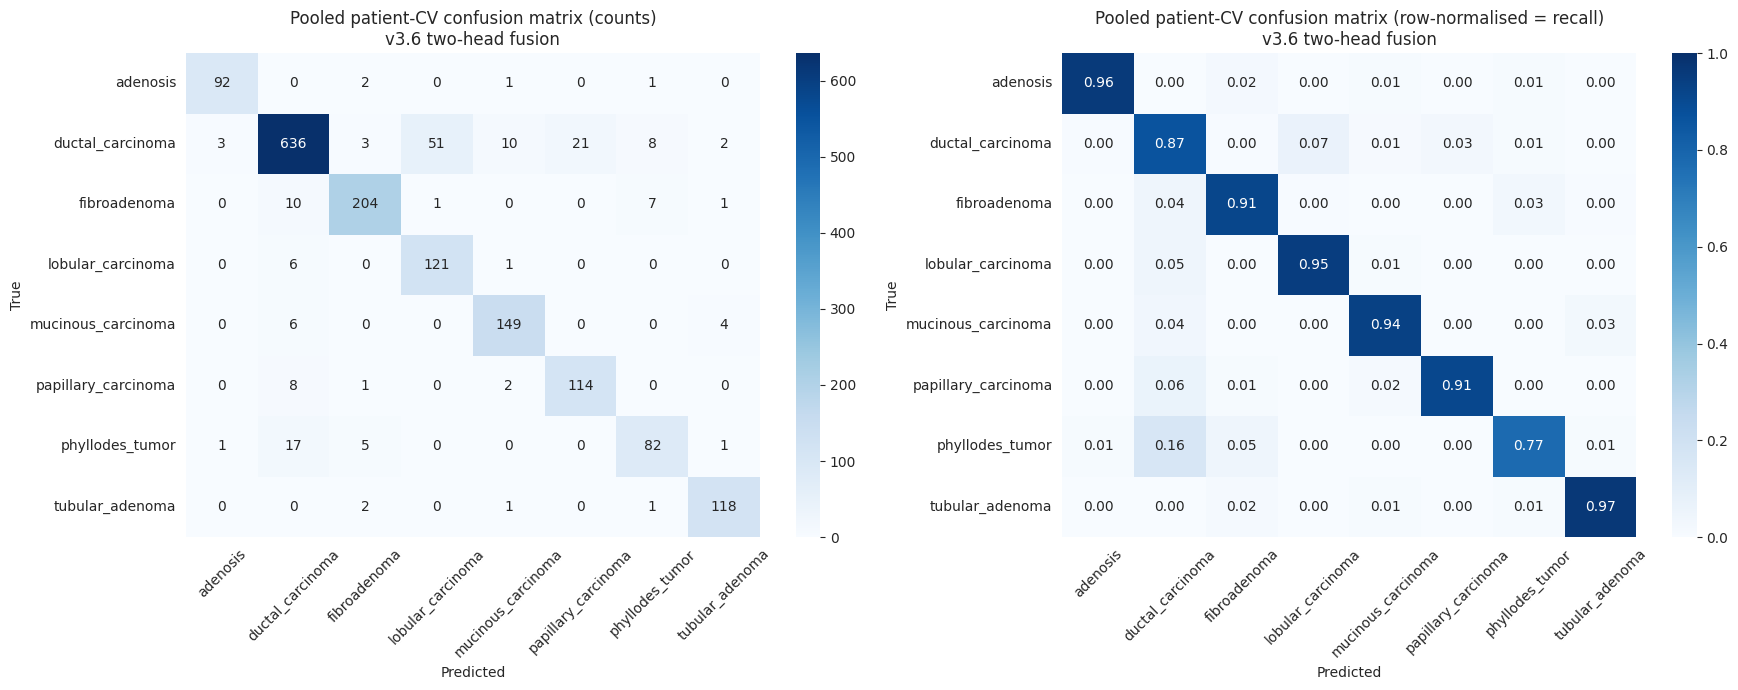

Saved: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/figures/cv_confusion_matrix_v36.png

Classification report (pooled patient-CV, v3.6 two-head):
                     precision    recall  f1-score   support

           adenosis     0.9583    0.9583    0.9583        96
   ductal_carcinoma     0.9312    0.8665    0.8977       734
       fibroadenoma     0.9401    0.9148    0.9273       223
  lobular_carcinoma     0.6994    0.9453    0.8040       128
 mucinous_carcinoma     0.9085    0.9371    0.9226       159
papillary_carcinoma     0.8444    0.9120    0.8769       125
    phyllodes_tumor     0.8283    0.7736    0.8000       106
    tubular_adenoma     0.9365    0.9672    0.9516       122

           accuracy                         0.8955      1693
          macro avg     0.8809    0.9094    0.8923      1693
       weighted avg     0.9018    0.8955    0.8965      1693

Saved: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abd

In [19]:
# 2.5.11 — Confusion matrix + per-class report on pooled v3.6 patient-CV predictions
#
# Produces the full 8x8 confusion matrix and the classification_report
# (precision/recall/F1 per class + macro/weighted aggregates) for the v3.6
# two-head model's pooled patient-CV predictions. Saves a heatmap PNG to
# figures/cv_confusion_matrix_v36.png and a text report to
# results/fusion_mlp_twohead_cv_v36_patient/classification_report.txt.

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

CV_TH_DIR = os.path.join(RESULTS_DIR, "fusion_mlp_twohead_cv_v36_patient")
yp_path = os.path.join(CV_TH_DIR, "pooled_y_pred_8class.npy")
yt_path = os.path.join(CV_TH_DIR, "pooled_y_true_8class.npy")

if not (os.path.exists(yp_path) and os.path.exists(yt_path)):
    print("Pooled v3.6 patient-CV predictions not found. Run cell 2.5.8 first.")
else:
    y_true = np.load(yt_path)
    y_pred = np.load(yp_path)
    print(f"Pooled n={len(y_true)} (8-class predictions)")

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    # Raw counts
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0], cbar=True)
    axes[0].set_title("Pooled patient-CV confusion matrix (counts)\nv3.6 two-head fusion")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].tick_params(axis="x", rotation=45)
    # Row-normalised (recall view)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1], cbar=True)
    axes[1].set_title("Pooled patient-CV confusion matrix (row-normalised = recall)\nv3.6 two-head fusion")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    cm_png = os.path.join(FIGURES_DIR, "cv_confusion_matrix_v36.png")
    plt.savefig(cm_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {cm_png}")

    # Classification report
    report_str = classification_report(
        y_true, y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    print("\nClassification report (pooled patient-CV, v3.6 two-head):")
    print(report_str)

    report_path = os.path.join(CV_TH_DIR, "classification_report.txt")
    with open(report_path, "w") as f:
        f.write("Pooled patient-CV classification report — v3.6 two-head\n")
        f.write("=" * 72 + "\n\n")
        f.write(report_str + "\n")
    print(f"Saved: {report_path}")

    # Top error pairs (off-diagonal, sorted by count)
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)
    flat = [(int(cm_off[i, j]), CLASS_NAMES[i], CLASS_NAMES[j])
            for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if cm_off[i, j] > 0]
    flat.sort(reverse=True)
    print("\nTop 10 confusion pairs (true → predicted):")
    for n_err, t, p in flat[:10]:
        print(f"  {t:<22} → {p:<22}  n={n_err}")


In [20]:
# 2.5.12 — Patient-level 5-fold CV for Swin-only, ConvNeXt-only, and weighted Ensemble
#
# Three baselines that go into Ablation Table 1. Each backbone gets a single
# Linear(1024->8) classifier trained on its cached penultimate features.
# The "ensemble" row is a weighted logit average; w_swin is tuned per fold on
# validation binary F1 (matches the protocol of cell 2.4).
#
# Saves results/single_backbone_cv_patient/cv_summary.json plus pooled
# predictions for each of the three models. Idempotent.

import math
import json as _json
from collections import Counter
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

CV_SB_DIR = os.path.join(RESULTS_DIR, "single_backbone_cv_patient")
os.makedirs(CV_SB_DIR, exist_ok=True)
CV_SB_SUMMARY = os.path.join(CV_SB_DIR, "cv_summary.json")

if os.path.exists(CV_SB_SUMMARY):
    print(f"Single-backbone + ensemble patient CV already done. Loading {CV_SB_SUMMARY}")
    with open(CV_SB_SUMMARY) as _f:
        cv_sb = _json.load(_f)
    for name in ("swin", "convnext", "ensemble"):
        a = cv_sb["aggregate"][name]
        print(f"  {name:<10} 8c-F1 {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}  "
              f"bin-F1 {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")
else:
    FEATS_DIR = os.path.join(RESULTS_DIR, "features")

    def _filenames_for_split(split):
        cached = os.path.join(FEATS_DIR, f"{split}_filenames.npy")
        if os.path.exists(cached):
            return np.load(cached, allow_pickle=True).tolist()
        names = []
        base = os.path.join(PROCESSED_DATA_DIR, "none", split)
        for cls in CLASS_NAMES:
            d = os.path.join(base, cls)
            if not os.path.isdir(d):
                continue
            for f in sorted(os.listdir(d)):
                if f.lower().endswith((".png", ".jpg", ".jpeg")):
                    names.append(f)
        return names

    X_swin_all = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_{s}_feats.npy"))
                                  for s in ("train", "val", "test")], axis=0).astype(np.float32)
    X_conv_all = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_{s}_feats.npy"))
                                  for s in ("train", "val", "test")], axis=0).astype(np.float32)
    y_all = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{s}_labels.npy"))
                            for s in ("train", "val", "test")], axis=0)
    fnames_all = _filenames_for_split("train") + _filenames_for_split("val") + _filenames_for_split("test")
    assert len(fnames_all) == len(y_all)
    groups = np.array([f.split("-")[2] for f in fnames_all])
    print(f"Single-backbone + ensemble patient CV: "
          f"X_swin {X_swin_all.shape}, X_conv {X_conv_all.shape}, "
          f"n_patients={len(set(groups.tolist()))}")

    class LinearHead(nn.Module):
        def __init__(self, in_dim=1024, n_classes=NUM_CLASSES):
            super().__init__()
            self.fc = nn.Linear(in_dim, n_classes)
        def forward(self, x):
            return self.fc(x)

    def train_head(X_tr, y_tr, X_va, y_va, in_dim, epochs=30, seed=42):
        scaler_h = StandardScaler().fit(X_tr)
        X_tr_s = scaler_h.transform(X_tr).astype(np.float32)
        X_va_s = scaler_h.transform(X_va).astype(np.float32)
        counts_h = Counter(y_tr.tolist())
        cw = torch.zeros(NUM_CLASSES)
        N = len(y_tr)
        for c, n in counts_h.items():
            cw[c] = N / (NUM_CLASSES * max(1, n))
        sample_w = [cw[int(y)] for y in y_tr]
        sampler_h = WeightedRandomSampler(weights=torch.as_tensor(sample_w, dtype=torch.float64),
                                          num_samples=len(y_tr), replacement=True)
        ds = TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr.astype(np.int64)))
        dl = DataLoader(ds, batch_size=64, sampler=sampler_h, num_workers=0)
        Xv = torch.from_numpy(X_va_s).to(DEVICE)

        torch.manual_seed(seed)
        model_h = LinearHead(in_dim=in_dim).to(DEVICE)
        opt = torch.optim.AdamW(model_h.parameters(), lr=1e-3, weight_decay=1e-4)
        loss_fn = nn.CrossEntropyLoss(weight=cw.to(DEVICE), label_smoothing=LABEL_SMOOTHING)
        best_bin = 0.0
        best_state = None
        y_va_bin = IS_MALIGNANT_8[y_va]
        for ep in range(1, epochs + 1):
            model_h.train()
            for xb, yb in dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                loss = loss_fn(model_h(xb), yb)
                opt.zero_grad(); loss.backward(); opt.step()
            model_h.eval()
            with torch.no_grad():
                vl = model_h(Xv).cpu().numpy()
            vp = vl.argmax(1)
            vb = IS_MALIGNANT_8[vp]
            bin_f1 = f1_score(y_va_bin, vb, average="binary")
            if bin_f1 > best_bin:
                best_bin = bin_f1
                best_state = {k: v.detach().cpu().clone() for k, v in model_h.state_dict().items()}
        if best_state is None:
            best_state = {k: v.detach().cpu().clone() for k, v in model_h.state_dict().items()}
        model_h.load_state_dict(best_state)
        return model_h, scaler_h, best_bin

    @torch.no_grad()
    def head_logits(model_h, X, scaler_h):
        Xs = scaler_h.transform(X).astype(np.float32)
        out = model_h(torch.from_numpy(Xs).to(DEVICE))
        return out.cpu().numpy()

    N_FOLDS = 5
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    results = {"swin": [], "convnext": [], "ensemble": []}
    pool = {k: {"y_true": [], "y_pred": [], "malig": []} for k in results}
    best_ws = []

    for fold_idx, (trainval_idx, test_idx) in enumerate(
            sgkf.split(X_swin_all, y_all, groups), start=1):
        print(f"\n{'='*60}\nFold {fold_idx}/{N_FOLDS}\n{'='*60}")
        train_idx, val_idx = train_test_split(
            trainval_idx, test_size=0.15, stratify=y_all[trainval_idx],
            random_state=RANDOM_SEED + fold_idx)
        X_tr_s = X_swin_all[train_idx]; X_va_s = X_swin_all[val_idx]; X_te_s = X_swin_all[test_idx]
        X_tr_c = X_conv_all[train_idx]; X_va_c = X_conv_all[val_idx]; X_te_c = X_conv_all[test_idx]
        y_tr   = y_all[train_idx];      y_va   = y_all[val_idx];      y_te   = y_all[test_idx]
        y_te_bin = IS_MALIGNANT_8[y_te]
        y_va_bin = IS_MALIGNANT_8[y_va]
        overlap = set(groups[test_idx].tolist()) & set(groups[train_idx].tolist())
        assert len(overlap) == 0

        # Train Swin head and ConvNeXt head
        swin_h,  swin_sc,  swin_val_bin  = train_head(X_tr_s, y_tr, X_va_s, y_va, in_dim=X_tr_s.shape[1])
        conv_h,  conv_sc,  conv_val_bin  = train_head(X_tr_c, y_tr, X_va_c, y_va, in_dim=X_tr_c.shape[1])
        print(f"  swin val bin-F1 = {swin_val_bin:.4f}, convnext val bin-F1 = {conv_val_bin:.4f}")

        # Sweep ensemble weight on val
        sw_val_logits = head_logits(swin_h, X_va_s, swin_sc)
        cv_val_logits = head_logits(conv_h, X_va_c, conv_sc)
        ws = np.arange(0.0, 1.01, 0.01)
        best_w = 0.5; best_w_bin_f1 = -1.0
        for w in ws:
            ens = w * sw_val_logits + (1 - w) * cv_val_logits
            preds_bin = IS_MALIGNANT_8[ens.argmax(1)]
            b = f1_score(y_va_bin, preds_bin, average="binary")
            if b > best_w_bin_f1:
                best_w_bin_f1 = b; best_w = float(w)
        print(f"  best w_swin = {best_w:.2f}  (val_bin_F1 = {best_w_bin_f1:.4f})")
        best_ws.append(best_w)

        # Test eval for all three
        sw_te_logits = head_logits(swin_h, X_te_s, swin_sc)
        cv_te_logits = head_logits(conv_h, X_te_c, conv_sc)
        ens_te_logits = best_w * sw_te_logits + (1 - best_w) * cv_te_logits
        for name, logits in (("swin", sw_te_logits), ("convnext", cv_te_logits), ("ensemble", ens_te_logits)):
            probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
            preds_8 = logits.argmax(1)
            preds_bin = IS_MALIGNANT_8[preds_8]
            malig = probs[:, MALIGNANT_IDX].sum(axis=1)
            f8 = float(f1_score(y_te, preds_8, average="macro"))
            fb = float(f1_score(y_te_bin, preds_bin, average="binary"))
            ab = float(roc_auc_score(y_te_bin, malig))
            rec = recall_score(y_te, preds_8, average=None,
                               labels=list(range(NUM_CLASSES)), zero_division=0)
            results[name].append({
                "fold": fold_idx,
                "n_test": int(len(test_idx)),
                "f1_8class": f8, "f1_binary": fb, "auc_binary": ab,
                "per_class_recall": rec.tolist(),
                "best_w_swin": best_w if name == "ensemble" else None,
            })
            pool[name]["y_true"].append(y_te.copy())
            pool[name]["y_pred"].append(preds_8.copy())
            pool[name]["malig"].append(malig.copy())
            print(f"    {name:<9} test 8c-F1={f8:.4f}  bin-F1={fb:.4f}  bin-AUC={ab:.4f}")

        del swin_h, conv_h
        torch.cuda.empty_cache()

    # Aggregate
    aggregate = {}
    for name in ("swin", "convnext", "ensemble"):
        f8_arr = np.array([r["f1_8class"] for r in results[name]])
        fb_arr = np.array([r["f1_binary"] for r in results[name]])
        ab_arr = np.array([r["auc_binary"] for r in results[name]])
        rec_arr = np.array([r["per_class_recall"] for r in results[name]])
        aggregate[name] = {
            "f1_8class_mean":  float(f8_arr.mean()),  "f1_8class_std":  float(f8_arr.std(ddof=1)),
            "f1_binary_mean":  float(fb_arr.mean()),  "f1_binary_std":  float(fb_arr.std(ddof=1)),
            "auc_binary_mean": float(ab_arr.mean()),  "auc_binary_std": float(ab_arr.std(ddof=1)),
            "per_class_recall_mean": rec_arr.mean(axis=0).tolist(),
            "per_class_recall_std":  rec_arr.std(axis=0, ddof=1).tolist(),
        }

    cv_sb = {
        "n_folds": N_FOLDS,
        "split_strategy": "StratifiedGroupKFold by patient ID",
        "head_architecture": "Linear(1024->8) per backbone, CE + smoothing 0.1, WeightedRandomSampler",
        "ensemble": "weighted logit average; w_swin per-fold tuned on val binary F1",
        "best_w_swin_per_fold": best_ws,
        "folds": results,
        "aggregate": aggregate,
    }
    with open(CV_SB_SUMMARY, "w") as f:
        _json.dump(cv_sb, f, indent=2)
    for name in ("swin", "convnext", "ensemble"):
        np.save(os.path.join(CV_SB_DIR, f"pooled_{name}_y_true.npy"),  np.concatenate(pool[name]["y_true"]))
        np.save(os.path.join(CV_SB_DIR, f"pooled_{name}_y_pred.npy"),  np.concatenate(pool[name]["y_pred"]))
        np.save(os.path.join(CV_SB_DIR, f"pooled_{name}_malig.npy"),   np.concatenate(pool[name]["malig"]))

    print(f"\nSaved {os.path.relpath(CV_SB_SUMMARY)} + pooled .npy")
    for name in ("swin", "convnext", "ensemble"):
        a = aggregate[name]
        print(f"  {name:<10} 8c-F1 {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}  "
              f"bin-F1 {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}  "
              f"bin-AUC {a['auc_binary_mean']:.4f} ± {a['auc_binary_std']:.4f}")


Single-backbone + ensemble patient CV already done. Loading /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/single_backbone_cv_patient/cv_summary.json
  swin       8c-F1 0.7473 ± 0.0929  bin-F1 0.9561 ± 0.0102
  convnext   8c-F1 0.8157 ± 0.0891  bin-F1 0.9822 ± 0.0089
  ensemble   8c-F1 0.8019 ± 0.0990  bin-F1 0.9741 ± 0.0173


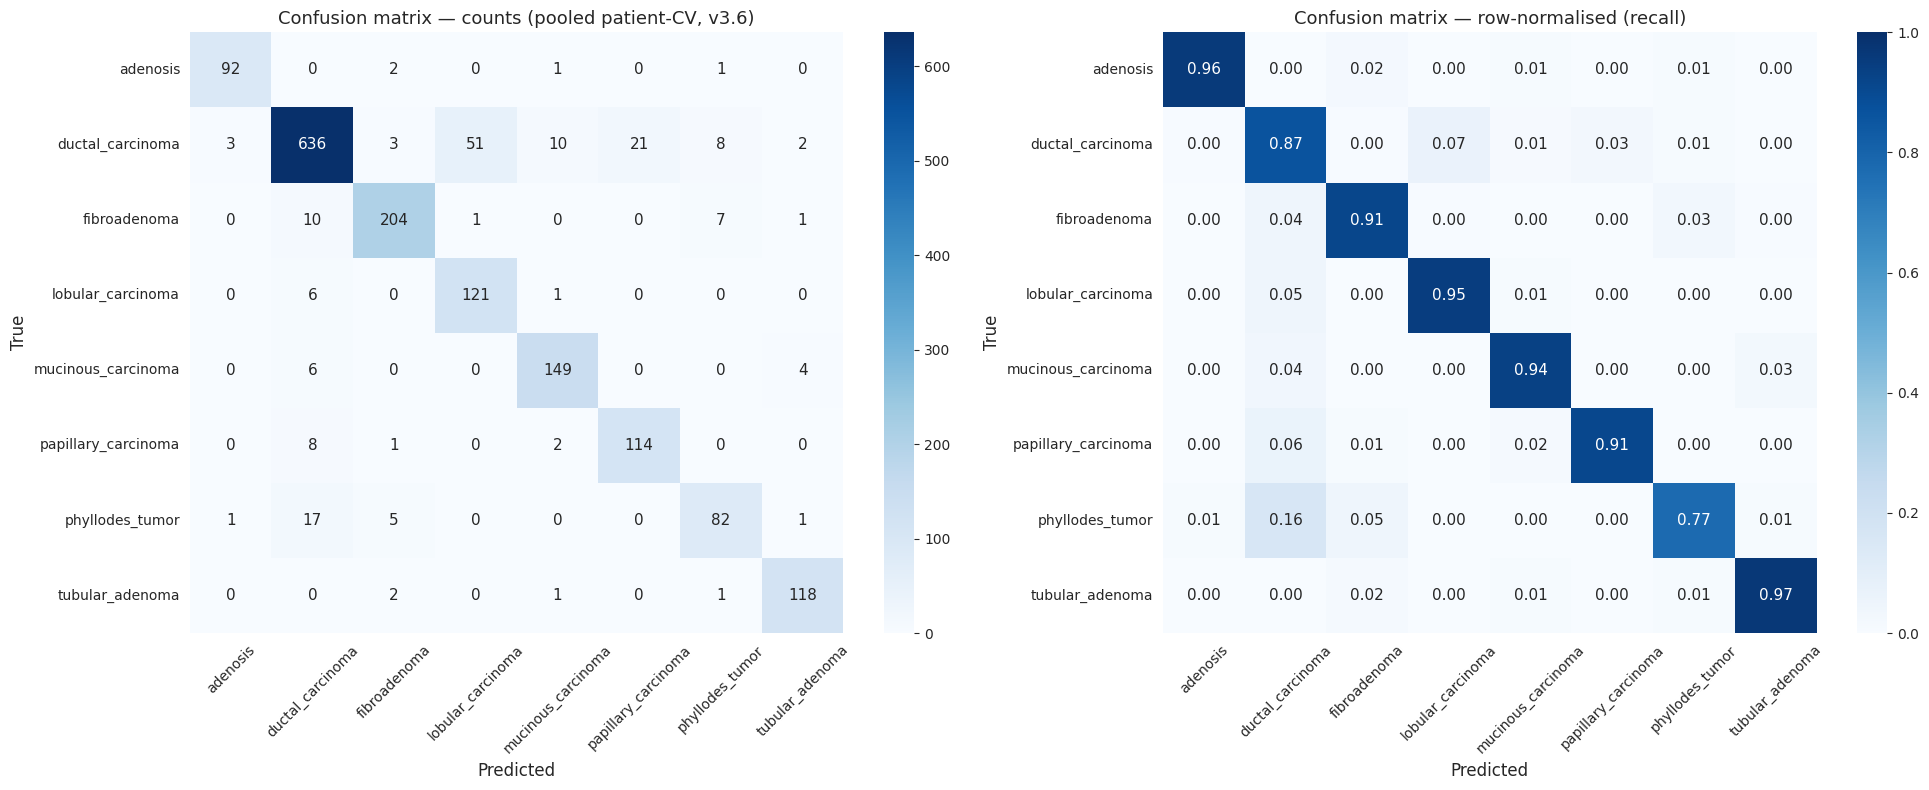

Saved: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/figures/cv_confusion_matrix_v36_pub.png  (300 DPI)


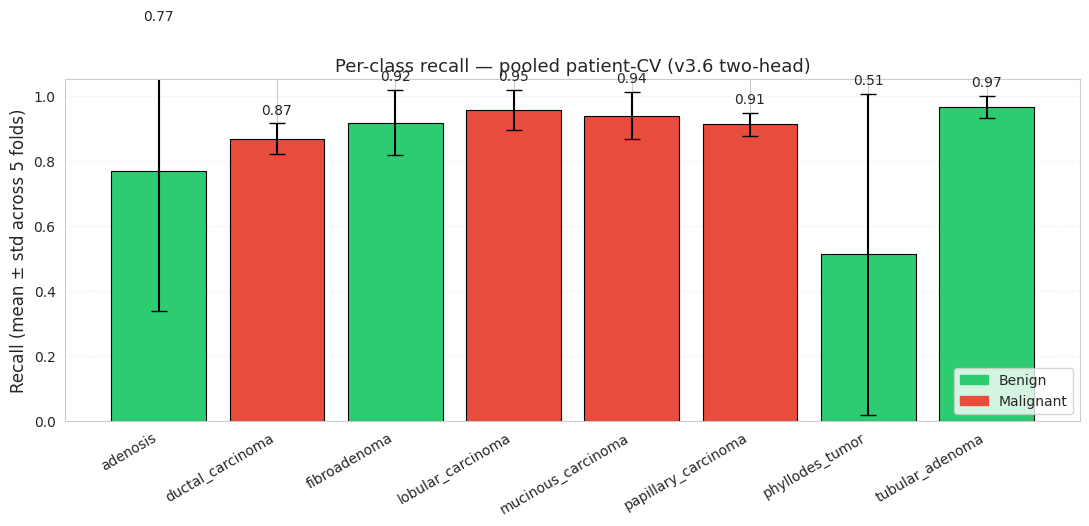

Saved: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/figures/cv_per_class_f1_v36.png  (300 DPI)

Saved: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/fusion_mlp_twohead_cv_v36_patient/per_class_table.tex
Saved: /home/abdullah/Documents/GitHub/Personal/densnet-thesis/thesis-v1-agent-abdullah/results/fusion_mlp_twohead_cv_v36_patient/per_class_table.txt

Per-class precision/recall/F1 — pooled patient-CV (v3.6 two-head)
  Class                        P       R      F1   support
----------------------------------------------------------------------------
  adenosis                 0.958   0.958   0.958        96
  ductal_carcinoma         0.931   0.866   0.898       734
  fibroadenoma             0.940   0.915   0.927       223
  lobular_carcinoma        0.699   0.945   0.804       128
  mucinous_carcinoma       0.909   0.937   0.923       159
  papillary_carcinoma      0.844   0.912   0.877       125
  phyllodes

In [21]:
# 2.5.13 — Publication-ready figures + LaTeX per-class table for v3.6 patient CV
#
# Inputs: pooled predictions from cell 2.5.8.
# Outputs:
#   figures/cv_confusion_matrix_v36_pub.png   (300 DPI, paper-ready)
#   figures/cv_per_class_f1_v36.png            (per-class F1 bars + error bars)
#   results/fusion_mlp_twohead_cv_v36_patient/per_class_table.tex  (LaTeX)
#   results/fusion_mlp_twohead_cv_v36_patient/per_class_table.txt  (plain text)

import os
import json as _json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    precision_score, recall_score,
)

CV_TH_DIR = os.path.join(RESULTS_DIR, "fusion_mlp_twohead_cv_v36_patient")
yp_path = os.path.join(CV_TH_DIR, "pooled_y_pred_8class.npy")
yt_path = os.path.join(CV_TH_DIR, "pooled_y_true_8class.npy")
fold_summary_path = os.path.join(CV_TH_DIR, "cv_summary.json")

if not (os.path.exists(yp_path) and os.path.exists(yt_path) and os.path.exists(fold_summary_path)):
    print("Pooled v3.6 patient-CV outputs not found. Run cell 2.5.8 first.")
else:
    y_true = np.load(yt_path)
    y_pred = np.load(yp_path)
    with open(fold_summary_path) as _f:
        fold_summary = _json.load(_f)
    n_folds = fold_summary["n_folds"]

    # ---- 300 DPI confusion matrix ----
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[0], cbar=True, annot_kws={"size": 11})
    axes[0].set_title("Confusion matrix — counts (pooled patient-CV, v3.6)", fontsize=13)
    axes[0].set_xlabel("Predicted", fontsize=12)
    axes[0].set_ylabel("True", fontsize=12)
    axes[0].tick_params(axis="x", rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=axes[1], cbar=True, annot_kws={"size": 11})
    axes[1].set_title("Confusion matrix — row-normalised (recall)", fontsize=13)
    axes[1].set_xlabel("Predicted", fontsize=12)
    axes[1].set_ylabel("True", fontsize=12)
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    pub_cm_png = os.path.join(FIGURES_DIR, "cv_confusion_matrix_v36_pub.png")
    plt.savefig(pub_cm_png, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {pub_cm_png}  (300 DPI)")

    # ---- Per-class F1 bar chart with error bars (mean ± std across folds) ----
    rec_mean = np.array(fold_summary["aggregate"]["per_class_recall_mean"])
    rec_std  = np.array(fold_summary["aggregate"]["per_class_recall_std"])

    fig, ax = plt.subplots(figsize=(11, 5.5))
    n = list(range(NUM_CLASSES))
    benign_color = "#2ecc71"; malig_color = "#e74c3c"
    colors = [benign_color if cls in BENIGN_CLASSES else malig_color for cls in CLASS_NAMES]
    bars = ax.bar(n, rec_mean, yerr=rec_std, color=colors, capsize=6, edgecolor="black", linewidth=0.8)
    ax.set_xticks(n)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Recall (mean ± std across 5 folds)", fontsize=12)
    ax.set_title("Per-class recall — pooled patient-CV (v3.6 two-head)", fontsize=13)
    for bar, m, s in zip(bars, rec_mean, rec_std):
        ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.02,
                f"{m:.2f}", ha="center", va="bottom", fontsize=10)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    handles = [
        plt.Rectangle((0,0), 1, 1, color=benign_color, label="Benign"),
        plt.Rectangle((0,0), 1, 1, color=malig_color,  label="Malignant"),
    ]
    ax.legend(handles=handles, loc="lower right")
    plt.tight_layout()
    pub_perclass_png = os.path.join(FIGURES_DIR, "cv_per_class_f1_v36.png")
    plt.savefig(pub_perclass_png, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {pub_perclass_png}  (300 DPI)")

    # ---- LaTeX per-class table ----
    p_per = precision_score(y_true, y_pred, average=None,
                             labels=list(range(NUM_CLASSES)), zero_division=0)
    r_per = recall_score(y_true, y_pred, average=None,
                          labels=list(range(NUM_CLASSES)), zero_division=0)
    f_per = f1_score(y_true, y_pred, average=None,
                      labels=list(range(NUM_CLASSES)), zero_division=0)
    support = np.array([(y_true == c).sum() for c in range(NUM_CLASSES)])
    macro_p = float(precision_score(y_true, y_pred, average="macro", zero_division=0))
    macro_r = float(recall_score(y_true,    y_pred, average="macro", zero_division=0))
    macro_f = float(f1_score(y_true,        y_pred, average="macro", zero_division=0))
    weighted_p = float(precision_score(y_true, y_pred, average="weighted", zero_division=0))
    weighted_r = float(recall_score(y_true,    y_pred, average="weighted", zero_division=0))
    weighted_f = float(f1_score(y_true,        y_pred, average="weighted", zero_division=0))

    def _tex_row(name, P, R, F, S):
        clean = name.replace("_", "\\_")
        return f"  {clean} & {P:.3f} & {R:.3f} & {F:.3f} & {S} \\\\"

    tex_lines = [
        r"\begin{table}[h]",
        r"\centering",
        r"\caption{Per-class precision, recall, and F1-score on pooled patient-stratified 5-fold cross-validation (n=" + f"{len(y_true)}" + r") for the proposed v3.6 two-head fusion model.}",
        r"\label{tab:per_class_v36}",
        r"\begin{tabular}{lcccc}",
        r"\toprule",
        r"  Class & Precision & Recall & F1-score & Support \\",
        r"\midrule",
    ]
    for c in range(NUM_CLASSES):
        tex_lines.append(_tex_row(CLASS_NAMES[c], p_per[c], r_per[c], f_per[c], int(support[c])))
    tex_lines += [
        r"\midrule",
        f"  Macro avg & {macro_p:.3f} & {macro_r:.3f} & {macro_f:.3f} & {int(support.sum())} \\\\",
        f"  Weighted avg & {weighted_p:.3f} & {weighted_r:.3f} & {weighted_f:.3f} & {int(support.sum())} \\\\",
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ]
    tex_path = os.path.join(CV_TH_DIR, "per_class_table.tex")
    with open(tex_path, "w") as f:
        f.write("\n".join(tex_lines) + "\n")
    print(f"\nSaved: {tex_path}")

    # ---- Plain-text version ----
    txt_lines = [
        "Per-class precision/recall/F1 — pooled patient-CV (v3.6 two-head)",
        "=" * 76,
        f"  {'Class':<22} {'P':>7} {'R':>7} {'F1':>7} {'support':>9}",
        "-" * 76,
    ]
    for c in range(NUM_CLASSES):
        txt_lines.append(
            f"  {CLASS_NAMES[c]:<22} {p_per[c]:>7.3f} {r_per[c]:>7.3f} {f_per[c]:>7.3f} {int(support[c]):>9}"
        )
    txt_lines.append("-" * 76)
    txt_lines.append(f"  {'Macro avg':<22} {macro_p:>7.3f} {macro_r:>7.3f} {macro_f:>7.3f} {int(support.sum()):>9}")
    txt_lines.append(f"  {'Weighted avg':<22} {weighted_p:>7.3f} {weighted_r:>7.3f} {weighted_f:>7.3f} {int(support.sum()):>9}")
    txt_path = os.path.join(CV_TH_DIR, "per_class_table.txt")
    with open(txt_path, "w") as f:
        f.write("\n".join(txt_lines) + "\n")
    print(f"Saved: {txt_path}")
    print()
    print("\n".join(txt_lines))


In [26]:
# 2.5.14 — Ablation Table 1 — main results table for the paper
#
# Aggregates every result file produced by previous cells into one table:
#   Rows: Swin-only, ConvNeXt-only, Logit Ensemble, Binary-opt fusion (v1),
#         Macro-opt fusion (v2), Two-head v3.6, Two-head v3.6 + finetune
#   Cols: Single-split test 8c-F1, Patient-CV 8c-F1 (mean ± std),
#         Image-CV 8c-F1 (mean ± std), Approx. trainable params
#
# Loads from:
#   results/feature_ensemble_swin_none_x_convnext_none/test_summary.json   (single-split)
#   results/ensemble_swin_none_x_convnext_none/ensemble_summary.json       (single-split, swin/conv/ens)
#   results/fusion_mlp_macro/test_summary.json                              (single-split)
#   results/fusion_mlp_twohead/test_summary.json                            (single-split, v3.x)
#   results/fusion_mlp_twohead_v36_finetuned/test_summary.json              (single-split FT)
#   results/single_backbone_cv_patient/cv_summary.json                       (cell 2.5.12)
#   results/fusion_mlp_binary_cv_patient/cv_summary.json                     (cell 2.5.7)
#   results/fusion_mlp_twohead_cv_v36_patient/cv_summary.json                (cell 2.5.8)
#   results/fusion_mlp_twohead_cv_v36/cv_summary.json                        (cell 2.5.6, image-CV)
#
# Outputs:
#   results/ablation_table_1.tex
#   results/ablation_table_1.txt
# Missing values are printed as "—".

import os
import json as _json

T_DIR = RESULTS_DIR
def _load(rel):
    p = os.path.join(T_DIR, rel)
    if not os.path.exists(p):
        return None
    with open(p) as f:
        return _json.load(f)

single_split_paths = {
    "swin": "ensemble_swin_none_x_convnext_none/ensemble_summary.json",     # 'test.swin'
    "convnext": "ensemble_swin_none_x_convnext_none/ensemble_summary.json", # 'test.convnext'
    "ensemble": "ensemble_swin_none_x_convnext_none/ensemble_summary.json", # 'test.ensemble'
    "binary_opt": "feature_ensemble_swin_none_x_convnext_none/test_summary.json",  # 'feature_ensemble'
    "macro_opt":  "fusion_mlp_macro/test_summary.json",                            # 'feature_ensemble_macro_opt'
    "v36":        "fusion_mlp_twohead/test_summary.json",                          # 'feature_ensemble_twohead'
    "v36_ft":     "fusion_mlp_twohead_v36_finetuned/test_summary.json",            # 'test_metrics'
}
patient_cv_paths = {
    "swin":       "single_backbone_cv_patient/cv_summary.json",
    "convnext":   "single_backbone_cv_patient/cv_summary.json",
    "ensemble":   "single_backbone_cv_patient/cv_summary.json",
    "binary_opt": "fusion_mlp_binary_cv_patient/cv_summary.json",
    "v36":          "fusion_mlp_twohead_cv_v36_patient/cv_summary.json",
    "feature_ens":  "feature_ensemble_cv_patient/cv_summary.json",
}
image_cv_paths = {
    "swin":          "single_backbone_cv_image/cv_summary.json",
    "convnext":      "single_backbone_cv_image/cv_summary.json",
    "ensemble":      "single_backbone_cv_image/cv_summary.json",
    "binary_opt":    "fusion_mlp_binary_cv_image/cv_summary.json",
    "feature_ens":   "feature_ensemble_cv_image/cv_summary.json",
    "v36":           "fusion_mlp_twohead_cv_v36/cv_summary.json",
}

def _ss_8c(name):
    """Single-split 8-class macro F1."""
    if name in ("swin", "convnext", "ensemble"):
        d = _load(single_split_paths[name])
        if d is None: return None
        return d["test"][name]["f1_8class"]
    if name == "binary_opt":
        d = _load(single_split_paths[name])
        if d is None: return None
        return d["feature_ensemble"]["f1_8class"]
    if name == "macro_opt":
        d = _load(single_split_paths[name])
        if d is None: return None
        return d.get("feature_ensemble_macro_opt", {}).get("f1_8class")
    if name == "v36":
        d = _load(single_split_paths[name])
        if d is None: return None
        return d.get("feature_ensemble_twohead", {}).get("f1_8class")
    if name == "v36_ft":
        d = _load(single_split_paths[name])
        if d is None: return None
        return d.get("test_metrics", {}).get("f1_8class")
    return None

def _patcv_8c(name):
    """Patient-CV 8-class macro F1 (mean, std)."""
    p = patient_cv_paths.get(name)
    if p is None: return None, None
    d = _load(p)
    if d is None: return None, None
    if name in ("swin", "convnext", "ensemble"):
        a = d.get("aggregate", {}).get(name, {})
    else:
        a = d.get("aggregate", {})
    return a.get("f1_8class_mean"), a.get("f1_8class_std")

def _imgcv_8c(name):
    p = image_cv_paths.get(name)
    if p is None: return None, None
    d = _load(p)
    if d is None: return None, None
    if name in ("swin", "convnext", "ensemble"):
        a = d.get("aggregate", {}).get(name, {})
    else:
        a = d.get("aggregate", {})
    return a.get("f1_8class_mean"), a.get("f1_8class_std")

# Approximate trainable-parameter counts for each variant.
# Backbones are frozen everywhere except v36_ft (Swin layers[-1] + head).
# These are head-only counts in K (rounded), recorded for the table column.
APPROX_PARAMS = {
    "swin":        "1024 × 8 = 8K",
    "convnext":    "1024 × 8 = 8K",
    "ensemble":    "16K (two heads)",
    "feature_ens": "562K",
    "binary_opt":  "1.05M",
    "macro_opt":   "1.05M",
    "v36":         "≈4.27M",
    "v36_ft":      "≈4.27M head + Swin last block",
}

ROW_LABELS = {
    "swin":        "Swin-Base (linear head)",
    "convnext":    "ConvNeXt-Base (linear head)",
    "ensemble":    "Logit Ensemble",
    "feature_ens": "Feature ensemble (2048-256-128-8)",
    "binary_opt":  "Binary-opt fusion (Variant A)",
    "macro_opt":   "Macro-opt fusion (Variant B)",
    "v36":         "Two-head v3.6",
    "v36_ft":      "Two-head v3.6 + Swin FT",
}
ROW_ORDER = ["swin", "convnext", "ensemble", "feature_ens",
             "binary_opt", "macro_opt", "v36", "v36_ft"]

# Build rows
rows = []
for name in ROW_ORDER:
    ss = _ss_8c(name)
    pcm, pcs = _patcv_8c(name)
    icm, ics = _imgcv_8c(name)
    rows.append({
        "label": ROW_LABELS[name],
        "single_split": ss,
        "image_cv_mean": icm, "image_cv_std": ics,
        "patient_cv_mean": pcm, "patient_cv_std": pcs,
        "params": APPROX_PARAMS[name],
    })

def _fmt(v, fmt=".4f"):
    return ("—" if v is None else format(v, fmt))
def _fmt_meanstd(m, s, fmt=".4f"):
    if m is None: return "—"
    if s is None: return format(m, fmt)
    return f"{m:{fmt}} ± {s:{fmt}}"

# Plain text table
txt = []
txt.append("Ablation Table 1 — 8-class macro F1 across protocols")
txt.append("=" * 100)
txt.append(f"  {'Variant':<32} {'Single-split':>14} {'Image-CV':>22} {'Patient-CV':>22} {'Params':>20}")
txt.append("-" * 100)
for r in rows:
    txt.append(
        f"  {r['label']:<32} "
        f"{_fmt(r['single_split']):>14} "
        f"{_fmt_meanstd(r['image_cv_mean'], r['image_cv_std']):>22} "
        f"{_fmt_meanstd(r['patient_cv_mean'], r['patient_cv_std']):>22} "
        f"{r['params']:>20}"
    )
txt.append("=" * 100)
txt_str = "\n".join(txt)
print(txt_str)

txt_path = os.path.join(RESULTS_DIR, "ablation_table_1.txt")
with open(txt_path, "w") as f:
    f.write(txt_str + "\n")
print(f"\nSaved: {txt_path}")

# LaTeX table
def _tex_cell(v, fmt=".3f"):
    return ("---" if v is None else format(v, fmt))
def _tex_meanstd(m, s, fmt=".3f"):
    if m is None: return "---"
    if s is None: return format(m, fmt)
    return f"{m:{fmt}} \\pm {s:{fmt}}"

tex = [
    r"\begin{table}[h]",
    r"\centering",
    r"\caption{Ablation Table~1: 8-class macro F1 on the BreaKHis 400$\times$ subset across model variants and evaluation protocols. Single-split refers to the standard 70/15/15 stratified split following Spanhol et al. (2016); Image-CV and Patient-CV are 5-fold image-stratified and patient-grouped cross-validations respectively. Patient-CV is the more conservative protocol because it prevents same-patient leakage between train and test.}",
    r"\label{tab:ablation_main}",
    r"\begin{tabular}{lcccc}",
    r"\toprule",
    r"  Variant & Single-split & Image-CV & Patient-CV & Params \\",
    r"\midrule",
]
for r in rows:
    tex.append(
        f"  {r['label']} & "
        f"{_tex_cell(r['single_split'])} & "
        f"${_tex_meanstd(r['image_cv_mean'], r['image_cv_std'])}$ & "
        f"${_tex_meanstd(r['patient_cv_mean'], r['patient_cv_std'])}$ & "
        f"{r['params']} \\\\"
    )
tex.append(r"\bottomrule")
tex.append(r"\end{tabular}")
tex.append(r"\end{table}")
tex_str = "\n".join(tex)

tex_path = os.path.join(RESULTS_DIR, "ablation_table_1.tex")
with open(tex_path, "w") as f:
    f.write(tex_str + "\n")
print(f"Saved: {tex_path}")


Ablation Table 1 — 8-class macro F1 across protocols
  Variant                            Single-split               Image-CV             Patient-CV               Params
----------------------------------------------------------------------------------------------------
  Swin-Base (linear head)                  0.8275        0.8825 ± 0.0221        0.7473 ± 0.0929        1024 × 8 = 8K
  ConvNeXt-Base (linear head)              0.8048        0.8822 ± 0.0095        0.8157 ± 0.0891        1024 × 8 = 8K
  Logit Ensemble                           0.8671        0.8893 ± 0.0193        0.8019 ± 0.0990      16K (two heads)
  Feature ensemble (2048-256-128-8)              —        0.9378 ± 0.0083        0.8211 ± 0.1599                 562K
  Binary-opt fusion (Variant A)            0.8747        0.9302 ± 0.0142        0.8208 ± 0.0758                1.05M
  Macro-opt fusion (Variant B)             0.8434                      —                      —                1.05M
  Two-head v3.6           

In [23]:
# 2.5.15 — Image-level 5-fold CV for Swin / ConvNeXt / weighted Ensemble
#
# Mirror of cell 2.5.12 (patient-CV) but with StratifiedKFold instead of
# StratifiedGroupKFold. Same head architecture (Linear(1024->8) per backbone),
# same protocol (CE + smoothing 0.1, WeightedRandomSampler, max val binary F1).
# Same fixed seed = 42 → splits are deterministic and identical to 2.5.6
# (cell 2.5.6 also uses StratifiedKFold with seed=42), keeping pooled
# predictions valid for cross-model McNemar tests.
#
# Saves results/single_backbone_cv_image/cv_summary.json + pooled .npy.
# Idempotent.

import math
import json as _json
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

CV_SB_IMG_DIR = os.path.join(RESULTS_DIR, "single_backbone_cv_image")
os.makedirs(CV_SB_IMG_DIR, exist_ok=True)
CV_SB_IMG_SUMMARY = os.path.join(CV_SB_IMG_DIR, "cv_summary.json")

if os.path.exists(CV_SB_IMG_SUMMARY):
    print(f"Image-CV (single backbone + ensemble) already done. Loading {CV_SB_IMG_SUMMARY}")
    with open(CV_SB_IMG_SUMMARY) as _f:
        cv = _json.load(_f)
    for name in ("swin", "convnext", "ensemble"):
        a = cv["aggregate"][name]
        print(f"  {name:<10} 8c-F1 {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}  "
              f"bin-F1 {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")
else:
    FEATS_DIR = os.path.join(RESULTS_DIR, "features")
    X_swin_all = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_{s}_feats.npy"))
                                  for s in ("train", "val", "test")], axis=0).astype(np.float32)
    X_conv_all = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_{s}_feats.npy"))
                                  for s in ("train", "val", "test")], axis=0).astype(np.float32)
    y_all = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{s}_labels.npy"))
                            for s in ("train", "val", "test")], axis=0)
    print(f"Image-CV (baselines): X_swin {X_swin_all.shape}, X_conv {X_conv_all.shape}")

    class LinearHead(nn.Module):
        def __init__(self, in_dim=1024, n_classes=NUM_CLASSES):
            super().__init__()
            self.fc = nn.Linear(in_dim, n_classes)
        def forward(self, x):
            return self.fc(x)

    def train_head(X_tr, y_tr, X_va, y_va, in_dim, epochs=30, seed=42):
        scaler_h = StandardScaler().fit(X_tr)
        X_tr_s = scaler_h.transform(X_tr).astype(np.float32)
        X_va_s = scaler_h.transform(X_va).astype(np.float32)
        counts_h = Counter(y_tr.tolist())
        cw = torch.zeros(NUM_CLASSES)
        N = len(y_tr)
        for c, n in counts_h.items():
            cw[c] = N / (NUM_CLASSES * max(1, n))
        sample_w = [cw[int(y)] for y in y_tr]
        sampler_h = WeightedRandomSampler(weights=torch.as_tensor(sample_w, dtype=torch.float64),
                                          num_samples=len(y_tr), replacement=True)
        ds = TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr.astype(np.int64)))
        dl = DataLoader(ds, batch_size=64, sampler=sampler_h, num_workers=0)
        Xv = torch.from_numpy(X_va_s).to(DEVICE)
        torch.manual_seed(seed)
        model_h = LinearHead(in_dim=in_dim).to(DEVICE)
        opt = torch.optim.AdamW(model_h.parameters(), lr=1e-3, weight_decay=1e-4)
        loss_fn = nn.CrossEntropyLoss(weight=cw.to(DEVICE), label_smoothing=LABEL_SMOOTHING)
        best_bin = 0.0
        best_state = None
        y_va_bin = IS_MALIGNANT_8[y_va]
        for ep in range(1, epochs + 1):
            model_h.train()
            for xb, yb in dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                loss = loss_fn(model_h(xb), yb)
                opt.zero_grad(); loss.backward(); opt.step()
            model_h.eval()
            with torch.no_grad():
                vl = model_h(Xv).cpu().numpy()
            vp = vl.argmax(1); vb = IS_MALIGNANT_8[vp]
            bin_f1 = f1_score(y_va_bin, vb, average="binary")
            if bin_f1 > best_bin:
                best_bin = bin_f1
                best_state = {k: v.detach().cpu().clone() for k, v in model_h.state_dict().items()}
        if best_state is None:
            best_state = {k: v.detach().cpu().clone() for k, v in model_h.state_dict().items()}
        model_h.load_state_dict(best_state)
        return model_h, scaler_h, best_bin

    @torch.no_grad()
    def head_logits(model_h, X, scaler_h):
        Xs = scaler_h.transform(X).astype(np.float32)
        return model_h(torch.from_numpy(Xs).to(DEVICE)).cpu().numpy()

    N_FOLDS = 5
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    results = {"swin": [], "convnext": [], "ensemble": []}
    pool = {k: {"y_true": [], "y_pred": [], "malig": []} for k in results}
    best_ws = []

    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(X_swin_all, y_all), start=1):
        print(f"\n{'='*60}\nFold {fold_idx}/{N_FOLDS}\n{'='*60}")
        train_idx, val_idx = train_test_split(trainval_idx, test_size=0.15,
                                               stratify=y_all[trainval_idx],
                                               random_state=RANDOM_SEED + fold_idx)
        X_tr_s = X_swin_all[train_idx]; X_va_s = X_swin_all[val_idx]; X_te_s = X_swin_all[test_idx]
        X_tr_c = X_conv_all[train_idx]; X_va_c = X_conv_all[val_idx]; X_te_c = X_conv_all[test_idx]
        y_tr   = y_all[train_idx];      y_va   = y_all[val_idx];      y_te   = y_all[test_idx]
        y_te_bin = IS_MALIGNANT_8[y_te]; y_va_bin = IS_MALIGNANT_8[y_va]

        swin_h, swin_sc, _ = train_head(X_tr_s, y_tr, X_va_s, y_va, in_dim=X_tr_s.shape[1])
        conv_h, conv_sc, _ = train_head(X_tr_c, y_tr, X_va_c, y_va, in_dim=X_tr_c.shape[1])

        sw_val_logits = head_logits(swin_h, X_va_s, swin_sc)
        cv_val_logits = head_logits(conv_h, X_va_c, conv_sc)
        ws = np.arange(0.0, 1.01, 0.01)
        best_w = 0.5; best_w_bin_f1 = -1.0
        for w in ws:
            ens = w * sw_val_logits + (1 - w) * cv_val_logits
            preds_bin = IS_MALIGNANT_8[ens.argmax(1)]
            b = f1_score(y_va_bin, preds_bin, average="binary")
            if b > best_w_bin_f1:
                best_w_bin_f1 = b; best_w = float(w)
        best_ws.append(best_w)
        print(f"  best w_swin = {best_w:.2f}  (val bin-F1={best_w_bin_f1:.4f})")

        sw_te_logits = head_logits(swin_h, X_te_s, swin_sc)
        cv_te_logits = head_logits(conv_h, X_te_c, conv_sc)
        ens_te_logits = best_w * sw_te_logits + (1 - best_w) * cv_te_logits

        for name, logits in (("swin", sw_te_logits), ("convnext", cv_te_logits), ("ensemble", ens_te_logits)):
            probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
            preds_8 = logits.argmax(1)
            preds_bin = IS_MALIGNANT_8[preds_8]
            malig = probs[:, MALIGNANT_IDX].sum(axis=1)
            f8 = float(f1_score(y_te,    preds_8, average="macro"))
            fb = float(f1_score(y_te_bin, preds_bin, average="binary"))
            ab = float(roc_auc_score(y_te_bin, malig))
            rec = recall_score(y_te, preds_8, average=None,
                                labels=list(range(NUM_CLASSES)), zero_division=0)
            results[name].append({
                "fold": fold_idx, "n_test": int(len(test_idx)),
                "f1_8class": f8, "f1_binary": fb, "auc_binary": ab,
                "per_class_recall": rec.tolist(),
                "best_w_swin": best_w if name == "ensemble" else None,
            })
            pool[name]["y_true"].append(y_te.copy())
            pool[name]["y_pred"].append(preds_8.copy())
            pool[name]["malig"].append(malig.copy())
            print(f"    {name:<9} test 8c-F1={f8:.4f}  bin-F1={fb:.4f}  bin-AUC={ab:.4f}")

        del swin_h, conv_h
        torch.cuda.empty_cache()

    aggregate = {}
    for name in ("swin", "convnext", "ensemble"):
        f8a = np.array([r["f1_8class"] for r in results[name]])
        fba = np.array([r["f1_binary"] for r in results[name]])
        aba = np.array([r["auc_binary"] for r in results[name]])
        reca = np.array([r["per_class_recall"] for r in results[name]])
        aggregate[name] = {
            "f1_8class_mean": float(f8a.mean()), "f1_8class_std": float(f8a.std(ddof=1)),
            "f1_binary_mean": float(fba.mean()), "f1_binary_std": float(fba.std(ddof=1)),
            "auc_binary_mean": float(aba.mean()), "auc_binary_std": float(aba.std(ddof=1)),
            "per_class_recall_mean": reca.mean(axis=0).tolist(),
            "per_class_recall_std":  reca.std(axis=0, ddof=1).tolist(),
        }

    cv_sb = {
        "n_folds": N_FOLDS, "split_strategy": "image-level StratifiedKFold",
        "head_architecture": "Linear(1024->8), CE + smoothing 0.1, WeightedRandomSampler",
        "ensemble": "weighted logit average; w_swin per-fold tuned on val binary F1",
        "best_w_swin_per_fold": best_ws,
        "folds": results, "aggregate": aggregate,
    }
    with open(CV_SB_IMG_SUMMARY, "w") as f:
        _json.dump(cv_sb, f, indent=2)
    for name in ("swin", "convnext", "ensemble"):
        np.save(os.path.join(CV_SB_IMG_DIR, f"pooled_{name}_y_true.npy"), np.concatenate(pool[name]["y_true"]))
        np.save(os.path.join(CV_SB_IMG_DIR, f"pooled_{name}_y_pred.npy"), np.concatenate(pool[name]["y_pred"]))
        np.save(os.path.join(CV_SB_IMG_DIR, f"pooled_{name}_malig.npy"),  np.concatenate(pool[name]["malig"]))
    print(f"\nSaved {os.path.relpath(CV_SB_IMG_SUMMARY)} + pooled .npy")
    for name in ("swin", "convnext", "ensemble"):
        a = aggregate[name]
        print(f"  {name:<10} 8c-F1 {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}  "
              f"bin-F1 {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")


Image-CV (baselines): X_swin (1693, 1024), X_conv (1693, 1024)

Fold 1/5
  best w_swin = 0.72  (val bin-F1=1.0000)
    swin      test 8c-F1=0.8690  bin-F1=0.9779  bin-AUC=0.9980
    convnext  test 8c-F1=0.8929  bin-F1=0.9845  bin-AUC=0.9991
    ensemble  test 8c-F1=0.8995  bin-F1=0.9867  bin-AUC=0.9995

Fold 2/5
  best w_swin = 0.99  (val bin-F1=0.9964)
    swin      test 8c-F1=0.9174  bin-F1=0.9845  bin-AUC=0.9980
    convnext  test 8c-F1=0.8885  bin-F1=0.9868  bin-AUC=0.9923
    ensemble  test 8c-F1=0.9174  bin-F1=0.9845  bin-AUC=0.9981

Fold 3/5
  best w_swin = 0.00  (val bin-F1=0.9817)
    swin      test 8c-F1=0.8891  bin-F1=0.9845  bin-AUC=0.9983
    convnext  test 8c-F1=0.8732  bin-F1=0.9890  bin-AUC=0.9954
    ensemble  test 8c-F1=0.8732  bin-F1=0.9890  bin-AUC=0.9954

Fold 4/5
  best w_swin = 0.00  (val bin-F1=0.9963)
    swin      test 8c-F1=0.8608  bin-F1=0.9803  bin-AUC=0.9934
    convnext  test 8c-F1=0.8713  bin-F1=0.9781  bin-AUC=0.9864
    ensemble  test 8c-F1=0.8713  bin

In [24]:
# 2.5.16 — Image-level 5-fold CV for the Binary-opt fusion (Variant A)
#
# Mirror of cell 2.5.7 (binary-opt patient-CV) but with StratifiedKFold instead
# of StratifiedGroupKFold. Same architecture (FusionMLP_v1: 2048->512->8 with
# class-weighted CE, max val binary F1). Same seed → splits identical to 2.5.6.
# Saves results/fusion_mlp_binary_cv_image/cv_summary.json. Idempotent.

import json as _json
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

CV_BIN_IMG_DIR = os.path.join(RESULTS_DIR, "fusion_mlp_binary_cv_image")
os.makedirs(CV_BIN_IMG_DIR, exist_ok=True)
CV_BIN_IMG_SUMMARY = os.path.join(CV_BIN_IMG_DIR, "cv_summary.json")

if os.path.exists(CV_BIN_IMG_SUMMARY):
    print(f"Image-CV (binary-opt fusion) already done. Loading {CV_BIN_IMG_SUMMARY}")
    with open(CV_BIN_IMG_SUMMARY) as _f:
        cv = _json.load(_f)
    a = cv["aggregate"]
    print(f"  8c-F1   = {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}")
    print(f"  bin-F1  = {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")
    print(f"  bin-AUC = {a['auc_binary_mean']:.4f} ± {a['auc_binary_std']:.4f}")
else:
    FEATS_DIR = os.path.join(RESULTS_DIR, "features")
    X_all_s = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{SWIN_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    X_all_c = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{CONV_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    y_all = np.concatenate([np.load(os.path.join(FEATS_DIR, f"{s}_labels.npy"))
                            for s in ("train", "val", "test")], axis=0)
    X_all = np.concatenate([X_all_s, X_all_c], axis=1).astype(np.float32)
    print(f"Image-CV (binary-opt): X_all {X_all.shape}")

    class FusionMLP_v1(nn.Module):
        def __init__(self, in_dim=2048, hidden=512, n_classes=NUM_CLASSES, dropout=0.3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(hidden, n_classes),
            )
        def forward(self, x):
            return self.net(x)

    N_FOLDS, EPOCHS_F = 5, 50
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    fold_results, pool_y_t, pool_y_p, pool_m = [], [], [], []

    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(X_all, y_all), start=1):
        print(f"\n{'='*60}\nBinary-opt image-CV — fold {fold_idx}/{N_FOLDS}\n{'='*60}")
        train_idx, val_idx = train_test_split(
            trainval_idx, test_size=0.15, stratify=y_all[trainval_idx],
            random_state=RANDOM_SEED + fold_idx)
        X_tr, y_tr = X_all[train_idx], y_all[train_idx]
        X_va, y_va = X_all[val_idx],   y_all[val_idx]
        X_te, y_te = X_all[test_idx],  y_all[test_idx]
        y_va_bin = IS_MALIGNANT_8[y_va]; y_te_bin = IS_MALIGNANT_8[y_te]

        scaler_f = StandardScaler().fit(X_tr)
        X_tr_s = scaler_f.transform(X_tr).astype(np.float32)
        X_va_s = scaler_f.transform(X_va).astype(np.float32)
        X_te_s = scaler_f.transform(X_te).astype(np.float32)

        counts_f = Counter(y_tr.tolist())
        cw = torch.zeros(NUM_CLASSES)
        N = len(y_tr)
        for c, n in counts_f.items():
            cw[c] = N / (NUM_CLASSES * max(1, n))
        sample_w = [cw[int(y)] for y in y_tr]
        sampler_f = WeightedRandomSampler(weights=torch.as_tensor(sample_w, dtype=torch.float64),
                                           num_samples=len(y_tr), replacement=True)
        train_ds = TensorDataset(torch.from_numpy(X_tr_s),
                                  torch.from_numpy(y_tr.astype(np.int64)))
        train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler_f, num_workers=0)
        Xv_t = torch.from_numpy(X_va_s).to(DEVICE)
        Xte_t = torch.from_numpy(X_te_s).to(DEVICE)

        torch.manual_seed(RANDOM_SEED + fold_idx)
        model_f = FusionMLP_v1(in_dim=X_tr.shape[1], dropout=0.3).to(DEVICE)
        optim_f = torch.optim.AdamW(model_f.parameters(), lr=1e-3, weight_decay=1e-4)
        loss_fn_f = nn.CrossEntropyLoss(weight=cw.to(DEVICE), label_smoothing=LABEL_SMOOTHING)

        best_bin, best_state = 0.0, None
        for epoch in range(1, EPOCHS_F + 1):
            model_f.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                loss = loss_fn_f(model_f(xb), yb)
                optim_f.zero_grad(); loss.backward(); optim_f.step()
            model_f.eval()
            with torch.no_grad():
                vl = model_f(Xv_t).cpu().numpy()
            vp = vl.argmax(1); vb = IS_MALIGNANT_8[vp]
            bf1 = f1_score(y_va_bin, vb, average="binary")
            if bf1 > best_bin:
                best_bin = bf1
                best_state = {k: v.detach().cpu().clone() for k, v in model_f.state_dict().items()}
            if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS_F:
                print(f"  ep {epoch:>2}/{EPOCHS_F}  val_bin_F1={bf1:.4f}")
        if best_state is None:
            best_state = {k: v.detach().cpu().clone() for k, v in model_f.state_dict().items()}

        model_f.load_state_dict(best_state); model_f.eval()
        with torch.no_grad():
            tl = model_f(Xte_t).cpu().numpy()
        tp = torch.softmax(torch.from_numpy(tl), dim=1).numpy()
        preds_8 = tl.argmax(1); preds_bin = IS_MALIGNANT_8[preds_8]
        malig = tp[:, MALIGNANT_IDX].sum(axis=1)
        f8 = float(f1_score(y_te,    preds_8,   average="macro"))
        fb = float(f1_score(y_te_bin, preds_bin, average="binary"))
        ab = float(roc_auc_score(y_te_bin, malig))
        rec = recall_score(y_te, preds_8, average=None, labels=list(range(NUM_CLASSES)),
                            zero_division=0)
        print(f"  TEST: 8c-F1={f8:.4f}  bin-F1={fb:.4f}  bin-AUC={ab:.4f}")
        fold_results.append({
            "fold": fold_idx, "n_train": int(len(train_idx)), "n_val": int(len(val_idx)),
            "n_test": int(len(test_idx)),
            "best_val_binary_f1": float(best_bin),
            "f1_8class": f8, "f1_binary": fb, "auc_binary": ab,
            "per_class_recall": rec.tolist(),
        })
        pool_y_t.append(y_te.copy()); pool_y_p.append(preds_8.copy()); pool_m.append(malig.copy())
        del model_f, optim_f
        torch.cuda.empty_cache()

    f8a = np.array([r["f1_8class"] for r in fold_results])
    fba = np.array([r["f1_binary"] for r in fold_results])
    aba = np.array([r["auc_binary"] for r in fold_results])
    reca = np.array([r["per_class_recall"] for r in fold_results])
    aggregate = {
        "f1_8class_mean": float(f8a.mean()), "f1_8class_std": float(f8a.std(ddof=1)),
        "f1_binary_mean": float(fba.mean()), "f1_binary_std": float(fba.std(ddof=1)),
        "auc_binary_mean": float(aba.mean()), "auc_binary_std": float(aba.std(ddof=1)),
        "per_class_recall_mean": reca.mean(axis=0).tolist(),
        "per_class_recall_std":  reca.std(axis=0, ddof=1).tolist(),
    }
    cv_bin = {
        "version": "binary-opt FusionMLP (v1) on image-level 5-fold CV",
        "n_folds": N_FOLDS, "split_strategy": "StratifiedKFold (image-level)",
        "epochs_per_fold": EPOCHS_F, "selection_criterion": "max val_binary_F1",
        "folds": fold_results, "aggregate": aggregate,
    }
    with open(CV_BIN_IMG_SUMMARY, "w") as f:
        _json.dump(cv_bin, f, indent=2)
    np.save(os.path.join(CV_BIN_IMG_DIR, "pooled_y_true_8class.npy"), np.concatenate(pool_y_t))
    np.save(os.path.join(CV_BIN_IMG_DIR, "pooled_y_pred_8class.npy"), np.concatenate(pool_y_p))
    np.save(os.path.join(CV_BIN_IMG_DIR, "pooled_malig_score.npy"),   np.concatenate(pool_m))
    print(f"\nSaved {os.path.relpath(CV_BIN_IMG_SUMMARY)} + pooled .npy")
    print(f"  8c-F1   = {aggregate['f1_8class_mean']:.4f} ± {aggregate['f1_8class_std']:.4f}")
    print(f"  bin-F1  = {aggregate['f1_binary_mean']:.4f} ± {aggregate['f1_binary_std']:.4f}")
    print(f"  bin-AUC = {aggregate['auc_binary_mean']:.4f} ± {aggregate['auc_binary_std']:.4f}")


Image-CV (binary-opt): X_all (1693, 2048)

Binary-opt image-CV — fold 1/5
  ep  1/50  val_bin_F1=0.9630
  ep 10/50  val_bin_F1=0.9928
  ep 20/50  val_bin_F1=0.9892
  ep 30/50  val_bin_F1=0.9892
  ep 40/50  val_bin_F1=0.9928
  ep 50/50  val_bin_F1=0.9928
  TEST: 8c-F1=0.9483  bin-F1=0.9934  bin-AUC=0.9998

Binary-opt image-CV — fold 2/5
  ep  1/50  val_bin_F1=0.9665
  ep 10/50  val_bin_F1=0.9853
  ep 20/50  val_bin_F1=0.9890
  ep 30/50  val_bin_F1=0.9817
  ep 40/50  val_bin_F1=0.9890
  ep 50/50  val_bin_F1=0.9890
  TEST: 8c-F1=0.9365  bin-F1=0.9934  bin-AUC=0.9987

Binary-opt image-CV — fold 3/5
  ep  1/50  val_bin_F1=0.9815
  ep 10/50  val_bin_F1=0.9853
  ep 20/50  val_bin_F1=0.9778
  ep 30/50  val_bin_F1=0.9779
  ep 40/50  val_bin_F1=0.9817
  ep 50/50  val_bin_F1=0.9817
  TEST: 8c-F1=0.9135  bin-F1=0.9890  bin-AUC=0.9984

Binary-opt image-CV — fold 4/5
  ep  1/50  val_bin_F1=0.9852
  ep 10/50  val_bin_F1=1.0000
  ep 20/50  val_bin_F1=0.9963
  ep 30/50  val_bin_F1=1.0000
  ep 40/50  va

In [25]:
# 2.5.17 — Feature ensemble baseline (deeper MLP, val-8c-F1 selection): IMAGE-CV + PATIENT-CV
#
# This is the third "fusion" baseline that the user's Ablation Table 1 lists
# as a separate row from "Binary-opt". The model is a 3-layer MLP
#     2048 -> 256 -> 128 -> 8
# trained with plain CE + label smoothing 0.1 (NO class weights, NO sampler),
# selected on **val 8-class F1** (rather than binary F1). This is the
# "naive deep fusion" baseline against which the binary-opt and v3.6 tweaks
# are compared.
#
# Saves both protocols:
#   results/feature_ensemble_cv_image/cv_summary.json
#   results/feature_ensemble_cv_patient/cv_summary.json
# Plus pooled prediction caches in each. Idempotent per protocol.

import json as _json
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, recall_score, roc_auc_score
from torch.utils.data import TensorDataset, DataLoader

class FeatureEnsembleMLP(nn.Module):
    """Deeper concat-MLP baseline: 2048 -> 256 -> 128 -> 8 with dropout."""
    def __init__(self, in_dim=2048, n_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),    nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )
    def forward(self, x):
        return self.net(x)


# ---------- Helpers ----------

FEATS_DIR_FE = os.path.join(RESULTS_DIR, "features")

def _filenames_for_split(split):
    cached = os.path.join(FEATS_DIR_FE, f"{split}_filenames.npy")
    if os.path.exists(cached):
        return np.load(cached, allow_pickle=True).tolist()
    names = []
    base = os.path.join(PROCESSED_DATA_DIR, "none", split)
    for cls in CLASS_NAMES:
        d = os.path.join(base, cls)
        if not os.path.isdir(d):
            continue
        for f in sorted(os.listdir(d)):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                names.append(f)
    return names


def _train_eval_one_fold(X_all, y_all, train_idx, val_idx, test_idx, fold_idx,
                          epochs=30, batch_size=64):
    """Train FeatureEnsembleMLP on fold; return per-fold metrics + preds."""
    X_tr, y_tr = X_all[train_idx], y_all[train_idx]
    X_va, y_va = X_all[val_idx],   y_all[val_idx]
    X_te, y_te = X_all[test_idx],  y_all[test_idx]
    y_va_bin = IS_MALIGNANT_8[y_va]; y_te_bin = IS_MALIGNANT_8[y_te]

    scaler_f = StandardScaler().fit(X_tr)
    X_tr_s = scaler_f.transform(X_tr).astype(np.float32)
    X_va_s = scaler_f.transform(X_va).astype(np.float32)
    X_te_s = scaler_f.transform(X_te).astype(np.float32)

    train_ds = TensorDataset(torch.from_numpy(X_tr_s),
                              torch.from_numpy(y_tr.astype(np.int64)))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    Xv_t = torch.from_numpy(X_va_s).to(DEVICE)
    Xte_t = torch.from_numpy(X_te_s).to(DEVICE)

    torch.manual_seed(RANDOM_SEED + fold_idx)
    model_f = FeatureEnsembleMLP(in_dim=X_tr.shape[1], dropout=0.3).to(DEVICE)
    optim_f = torch.optim.AdamW(model_f.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    best_8c, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        model_f.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = loss_fn(model_f(xb), yb)
            optim_f.zero_grad(); loss.backward(); optim_f.step()
        model_f.eval()
        with torch.no_grad():
            vl = model_f(Xv_t).cpu().numpy()
        v8 = vl.argmax(1)
        f8_val = f1_score(y_va, v8, average="macro")
        if f8_val > best_8c:
            best_8c = f8_val
            best_state = {k: v.detach().cpu().clone() for k, v in model_f.state_dict().items()}
        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"  fold {fold_idx} ep {epoch:>2}/{epochs}  val_8c_F1={f8_val:.4f}")
    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model_f.state_dict().items()}

    model_f.load_state_dict(best_state); model_f.eval()
    with torch.no_grad():
        tl = model_f(Xte_t).cpu().numpy()
    tp = torch.softmax(torch.from_numpy(tl), dim=1).numpy()
    preds_8 = tl.argmax(1); preds_bin = IS_MALIGNANT_8[preds_8]
    malig = tp[:, MALIGNANT_IDX].sum(axis=1)
    f8 = float(f1_score(y_te,    preds_8,   average="macro"))
    fb = float(f1_score(y_te_bin, preds_bin, average="binary"))
    ab = float(roc_auc_score(y_te_bin, malig))
    rec = recall_score(y_te, preds_8, average=None, labels=list(range(NUM_CLASSES)),
                        zero_division=0)
    print(f"  fold {fold_idx} TEST: 8c-F1={f8:.4f}  bin-F1={fb:.4f}  bin-AUC={ab:.4f}")
    res = {
        "fold": fold_idx,
        "n_train": int(len(train_idx)), "n_val": int(len(val_idx)),
        "n_test": int(len(test_idx)),
        "best_val_macro_f1": float(best_8c),
        "f1_8class": f8, "f1_binary": fb, "auc_binary": ab,
        "per_class_recall": rec.tolist(),
    }
    del model_f, optim_f
    torch.cuda.empty_cache()
    return res, y_te, preds_8, malig


def _aggregate_and_save(fold_results, pool_yt, pool_yp, pool_m, summary_path,
                         out_dir, version_str, split_strategy):
    f8a = np.array([r["f1_8class"] for r in fold_results])
    fba = np.array([r["f1_binary"] for r in fold_results])
    aba = np.array([r["auc_binary"] for r in fold_results])
    reca = np.array([r["per_class_recall"] for r in fold_results])
    aggregate = {
        "f1_8class_mean":  float(f8a.mean()),  "f1_8class_std":  float(f8a.std(ddof=1)),
        "f1_binary_mean":  float(fba.mean()),  "f1_binary_std":  float(fba.std(ddof=1)),
        "auc_binary_mean": float(aba.mean()),  "auc_binary_std": float(aba.std(ddof=1)),
        "per_class_recall_mean": reca.mean(axis=0).tolist(),
        "per_class_recall_std":  reca.std(axis=0, ddof=1).tolist(),
    }
    cv = {
        "version": version_str,
        "n_folds": len(fold_results),
        "split_strategy": split_strategy,
        "head_architecture": "FeatureEnsembleMLP: 2048->256->128->8 with Dropout(0.3)",
        "loss": "CE + label smoothing 0.1 (no class weights)",
        "selection_criterion": "max val 8-class macro F1",
        "folds": fold_results, "aggregate": aggregate,
    }
    with open(summary_path, "w") as f:
        _json.dump(cv, f, indent=2)
    np.save(os.path.join(out_dir, "pooled_y_true_8class.npy"), np.concatenate(pool_yt))
    np.save(os.path.join(out_dir, "pooled_y_pred_8class.npy"), np.concatenate(pool_yp))
    np.save(os.path.join(out_dir, "pooled_malig_score.npy"),   np.concatenate(pool_m))
    return aggregate


# ---------- Run protocol A: image-level CV ----------
FE_IMG_DIR = os.path.join(RESULTS_DIR, "feature_ensemble_cv_image")
os.makedirs(FE_IMG_DIR, exist_ok=True)
FE_IMG_SUMMARY = os.path.join(FE_IMG_DIR, "cv_summary.json")

if os.path.exists(FE_IMG_SUMMARY):
    print(f"\nFeature-ensemble image-CV already done. Loading {FE_IMG_SUMMARY}")
    with open(FE_IMG_SUMMARY) as _f:
        a = _json.load(_f)["aggregate"]
    print(f"  IMG  8c-F1 {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}  "
          f"bin-F1 {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")
else:
    print(f"\n{'='*60}\nFeature-ensemble baseline — IMAGE-CV (5 folds)\n{'='*60}")
    X_all_s = np.concatenate([np.load(os.path.join(FEATS_DIR_FE, f"{SWIN_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    X_all_c = np.concatenate([np.load(os.path.join(FEATS_DIR_FE, f"{CONV_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    y_all = np.concatenate([np.load(os.path.join(FEATS_DIR_FE, f"{s}_labels.npy"))
                            for s in ("train", "val", "test")], axis=0)
    X_all = np.concatenate([X_all_s, X_all_c], axis=1).astype(np.float32)
    print(f"X_all {X_all.shape}")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    fold_results, pool_yt, pool_yp, pool_m = [], [], [], []
    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(X_all, y_all), start=1):
        print(f"\n-- Fold {fold_idx}/5 --")
        train_idx, val_idx = train_test_split(
            trainval_idx, test_size=0.15, stratify=y_all[trainval_idx],
            random_state=RANDOM_SEED + fold_idx)
        res, yt, yp, m = _train_eval_one_fold(X_all, y_all, train_idx, val_idx, test_idx, fold_idx)
        fold_results.append(res)
        pool_yt.append(yt); pool_yp.append(yp); pool_m.append(m)

    a = _aggregate_and_save(fold_results, pool_yt, pool_yp, pool_m,
                             FE_IMG_SUMMARY, FE_IMG_DIR,
                             version_str="FeatureEnsembleMLP (2048->256->128->8) on image-level 5-fold CV",
                             split_strategy="StratifiedKFold (image-level)")
    print(f"\nSaved {os.path.relpath(FE_IMG_SUMMARY)}")
    print(f"  IMG  8c-F1 {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}  "
          f"bin-F1 {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")


# ---------- Run protocol B: patient-level CV ----------
FE_PAT_DIR = os.path.join(RESULTS_DIR, "feature_ensemble_cv_patient")
os.makedirs(FE_PAT_DIR, exist_ok=True)
FE_PAT_SUMMARY = os.path.join(FE_PAT_DIR, "cv_summary.json")

if os.path.exists(FE_PAT_SUMMARY):
    print(f"\nFeature-ensemble patient-CV already done. Loading {FE_PAT_SUMMARY}")
    with open(FE_PAT_SUMMARY) as _f:
        a = _json.load(_f)["aggregate"]
    print(f"  PAT  8c-F1 {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}  "
          f"bin-F1 {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")
else:
    print(f"\n{'='*60}\nFeature-ensemble baseline — PATIENT-CV (5 folds)\n{'='*60}")
    X_all_s = np.concatenate([np.load(os.path.join(FEATS_DIR_FE, f"{SWIN_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    X_all_c = np.concatenate([np.load(os.path.join(FEATS_DIR_FE, f"{CONV_EXP}_{s}_feats.npy"))
                              for s in ("train", "val", "test")], axis=0)
    y_all = np.concatenate([np.load(os.path.join(FEATS_DIR_FE, f"{s}_labels.npy"))
                            for s in ("train", "val", "test")], axis=0)
    X_all = np.concatenate([X_all_s, X_all_c], axis=1).astype(np.float32)
    fnames_all = (_filenames_for_split("train") + _filenames_for_split("val")
                  + _filenames_for_split("test"))
    assert len(fnames_all) == len(y_all)
    groups = np.array([f.split("-")[2] for f in fnames_all])
    print(f"X_all {X_all.shape}, n_patients={len(set(groups.tolist()))}")

    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    fold_results, pool_yt, pool_yp, pool_m = [], [], [], []
    for fold_idx, (trainval_idx, test_idx) in enumerate(sgkf.split(X_all, y_all, groups), start=1):
        print(f"\n-- Fold {fold_idx}/5 --")
        train_idx, val_idx = train_test_split(
            trainval_idx, test_size=0.15, stratify=y_all[trainval_idx],
            random_state=RANDOM_SEED + fold_idx)
        overlap = set(groups[test_idx].tolist()) & set(groups[train_idx].tolist())
        assert len(overlap) == 0, f"patient leak {overlap}"
        res, yt, yp, m = _train_eval_one_fold(X_all, y_all, train_idx, val_idx, test_idx, fold_idx)
        fold_results.append(res)
        pool_yt.append(yt); pool_yp.append(yp); pool_m.append(m)

    a = _aggregate_and_save(fold_results, pool_yt, pool_yp, pool_m,
                             FE_PAT_SUMMARY, FE_PAT_DIR,
                             version_str="FeatureEnsembleMLP (2048->256->128->8) on patient-level 5-fold CV",
                             split_strategy="StratifiedGroupKFold by patient ID")
    print(f"\nSaved {os.path.relpath(FE_PAT_SUMMARY)}")
    print(f"  PAT  8c-F1 {a['f1_8class_mean']:.4f} ± {a['f1_8class_std']:.4f}  "
          f"bin-F1 {a['f1_binary_mean']:.4f} ± {a['f1_binary_std']:.4f}")



Feature-ensemble baseline — IMAGE-CV (5 folds)
X_all (1693, 2048)

-- Fold 1/5 --
  fold 1 ep  1/30  val_8c_F1=0.9190
  fold 1 ep 10/30  val_8c_F1=0.9331
  fold 1 ep 20/30  val_8c_F1=0.9251
  fold 1 ep 30/30  val_8c_F1=0.9209
  fold 1 TEST: 8c-F1=0.9353  bin-F1=0.9913  bin-AUC=0.9997

-- Fold 2/5 --
  fold 2 ep  1/30  val_8c_F1=0.9303
  fold 2 ep 10/30  val_8c_F1=0.9342
  fold 2 ep 20/30  val_8c_F1=0.9340
  fold 2 ep 30/30  val_8c_F1=0.9259
  fold 2 TEST: 8c-F1=0.9465  bin-F1=0.9913  bin-AUC=0.9996

-- Fold 3/5 --
  fold 3 ep  1/30  val_8c_F1=0.9254
  fold 3 ep 10/30  val_8c_F1=0.9087
  fold 3 ep 20/30  val_8c_F1=0.9322
  fold 3 ep 30/30  val_8c_F1=0.9249
  fold 3 TEST: 8c-F1=0.9448  bin-F1=0.9956  bin-AUC=0.9992

-- Fold 4/5 --
  fold 4 ep  1/30  val_8c_F1=0.9327
  fold 4 ep 10/30  val_8c_F1=0.9599
  fold 4 ep 20/30  val_8c_F1=0.9688
  fold 4 ep 30/30  val_8c_F1=0.9537
  fold 4 TEST: 8c-F1=0.9259  bin-F1=0.9870  bin-AUC=0.9945

-- Fold 5/5 --
  fold 5 ep  1/30  val_8c_F1=0.9280
  fol

## 2.6 Explainability (Days 2–3)

Goal: show that **Swin attention is global** (broad context) while **ConvNeXt CAMs are local** (focused
on local cellular features). This is the core qualitative contribution.

Pipeline:
1. Pick 12 representative test images covering easy/hard cases and model agreement/disagreement.
2. HiResCAM heatmaps for ConvNeXt (using `pytorch_grad_cam`).
3. Attention rollout for Swin (custom hook-based implementation for window attention).
4. Faithfulness deletion curves to validate the heatmaps actually drive the predictions.

Install if needed: `pip install grad-cam`

In [30]:
# 2.6.1 Pick 12 case-study images for explainability figures
#
# Categories (2 each):
#   - easy_benign  : correctly classified by both, label=benign
#   - easy_malig   : correctly classified by both, label=malignant
#   - swin_wins    : swin correct, convnext wrong
#   - conv_wins    : convnext correct, swin wrong
#   - both_wrong   : both miss
#   - high_disagree: max softmax disagreement on malignancy score, regardless of correctness

ENS_DIR = os.path.join(RESULTS_DIR, ENSEMBLE_NAME)
swin_preds_8 = np.load(os.path.join(ENS_DIR, "test_preds_swin_8class.npy"))
conv_preds_8 = np.load(os.path.join(ENS_DIR, "test_preds_convnext_8class.npy"))
test_labels_loaded = np.load(os.path.join(ENS_DIR, "test_labels_8class.npy"))
test_files_loaded = np.load(os.path.join(ENS_DIR, "test_filenames.npy"))
malig_swin = np.load(os.path.join(ENS_DIR, "test_malig_score_swin.npy"))
malig_conv = np.load(os.path.join(ENS_DIR, "test_malig_score_convnext.npy"))

# Reconstruct (cls, fname) pairs from list_split_files (deterministic)
test_filelist = list_split_files(SWIN_STAIN, "test")
assert len(test_filelist) == len(test_labels_loaded)

is_benign = ~np.isin(test_labels_loaded, MALIGNANT_IDX)
is_malig  =  np.isin(test_labels_loaded, MALIGNANT_IDX)
swin_correct = swin_preds_8 == test_labels_loaded
conv_correct = conv_preds_8 == test_labels_loaded
both_correct = swin_correct & conv_correct
swin_wins = swin_correct & ~conv_correct
conv_wins = conv_correct & ~swin_correct
both_wrong = ~swin_correct & ~conv_correct
disagree_score = np.abs(malig_swin - malig_conv)

rng = np.random.default_rng(RANDOM_SEED)
def pick(mask, n=2, key=None):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return []
    if key is not None:
        idx = idx[np.argsort(-key[idx])]  # descending by key
        return idx[:n].tolist()
    return rng.choice(idx, size=min(n, len(idx)), replace=False).tolist()

picks = {
    "easy_benign":   pick(both_correct & is_benign, 2),
    "easy_malig":    pick(both_correct & is_malig,  2),
    "swin_wins":     pick(swin_wins, 2),
    "conv_wins":     pick(conv_wins, 2),
    "both_wrong":    pick(both_wrong, 2),
    "high_disagree": pick(np.ones_like(swin_correct, dtype=bool), 2, key=disagree_score),
}

print(f"{'category':<15} {'idx':>5}  {'true':<22} {'swin_pred':<22} {'conv_pred':<22}  filename")
print("-" * 130)
case_indices = []
for cat, idxs in picks.items():
    for idx in idxs:
        case_indices.append((cat, int(idx)))
        print(f"{cat:<15} {idx:>5}  "
              f"{CLASS_NAMES[test_labels_loaded[idx]]:<22} "
              f"{CLASS_NAMES[swin_preds_8[idx]]:<22} "
              f"{CLASS_NAMES[conv_preds_8[idx]]:<22}  "
              f"{test_files_loaded[idx]}")

# Persist for next cells
XAI_DIR = os.path.join(RESULTS_DIR, "xai")
os.makedirs(XAI_DIR, exist_ok=True)
with open(os.path.join(XAI_DIR, "case_indices.json"), "w") as f:
    json.dump(case_indices, f, indent=2)
print(f"\nSaved {len(case_indices)} case indices to {os.path.relpath(XAI_DIR)}/case_indices.json")


category          idx  true                   swin_pred              conv_pred               filename
----------------------------------------------------------------------------------------------------------------------------------
easy_benign         7  adenosis               adenosis               adenosis                SOB_B_A-14-22549AB-400-028.png
easy_benign       243  tubular_adenoma        tubular_adenoma        tubular_adenoma         SOB_B_TA-14-15275-400-002.png
easy_malig         94  ductal_carcinoma       ductal_carcinoma       ductal_carcinoma        SOB_M_DC-14-2773-400-013.png
easy_malig        222  papillary_carcinoma    papillary_carcinoma    papillary_carcinoma     SOB_M_PC-15-190EF-400-003.png
swin_wins         214  papillary_carcinoma    papillary_carcinoma    ductal_carcinoma        SOB_M_PC-14-19440-400-001.png
swin_wins          53  ductal_carcinoma       ductal_carcinoma       tubular_adenoma         SOB_M_DC-14-15792-400-007.png
conv_wins          33  ductal

In [32]:
# 2.6.2 HiResCAM heatmaps for ConvNeXt (the "local features" baseline)
#
# Requires: pip install grad-cam
# Target: last block of the last ConvNeXt stage (deepest convolutional feature map).

try:
    from pytorch_grad_cam import HiResCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError as e:
    raise ImportError("Install grad-cam first: pip install grad-cam") from e

XAI_DIR = os.path.join(RESULTS_DIR, "xai")
HIRESCAM_DIR = os.path.join(XAI_DIR, "hirescam_convnext")
os.makedirs(HIRESCAM_DIR, exist_ok=True)

with open(os.path.join(XAI_DIR, "case_indices.json")) as f:
    case_indices = [(c, i) for c, i in json.load(f)]

# Load model fresh (HiResCAM needs grad)
ckpt = torch.load(os.path.join(WEIGHTS_DIR, CONV_EXP, "best_model.pth"),
                  map_location=DEVICE, weights_only=False)
conv_model_xai = get_model("convnext", num_classes=NUM_CLASSES, pretrained=False)
conv_model_xai.load_state_dict(ckpt["model_state_dict"])
conv_model_xai.to(DEVICE).eval()

# In timm convnext_base: model.stages is a Sequential of 4 ConvNeXtStages,
# each with .blocks (Sequential of ConvNeXtBlock).
target_layers = [conv_model_xai.stages[-1].blocks[-1]]
cam = HiResCAM(model=conv_model_xai, target_layers=target_layers)

test_filelist = list_split_files(CONV_STAIN, "test")
base = os.path.join(PROCESSED_DATA_DIR, CONV_STAIN, "test")

# Denormalization for visualization
mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)

heatmaps_conv = {}
for cat, idx in case_indices:
    cls, fname = test_filelist[idx]
    img_pil = Image.open(os.path.join(base, cls, fname)).convert("RGB")
    img_tensor = eval_transform(img_pil).unsqueeze(0).to(DEVICE)

    targets = [ClassifierOutputTarget(int(test_labels_loaded[idx]))]
    grayscale = cam(input_tensor=img_tensor, targets=targets)[0]  # (H, W) in [0,1]

    rgb = img_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0) * std + mean
    rgb = np.clip(rgb, 0, 1)
    overlay = show_cam_on_image(rgb, grayscale, use_rgb=True, image_weight=0.5)

    out_path = os.path.join(HIRESCAM_DIR, f"{idx:04d}_{cat}_{fname}")
    Image.fromarray(overlay).save(out_path)
    np.save(out_path.replace(".png", "_heatmap.npy"), grayscale)
    heatmaps_conv[idx] = grayscale

print(f"Saved {len(heatmaps_conv)} HiResCAM heatmaps to {os.path.relpath(HIRESCAM_DIR)}/")
del cam, conv_model_xai
torch.cuda.empty_cache()


Saved 12 HiResCAM heatmaps to results/xai/hirescam_convnext/


In [ ]:
# 2.6.3 Swin saliency via Grad-CAM on the last-block norm2
#
# Replaces the previous monkey-patched attention rollout. Grad-CAM on
# Swin's last-block LayerNorm is the standard ViT-XAI approach:
#   - well-defined gradients (no fragile patching),
#   - directly comparable in spirit to ConvNeXt HiResCAM,
#   - produces per-image high-contrast maps that survive thresholding.
#
# timm Swin operates on (B, H, W, C) tokens, so we pass a reshape_transform
# to convert to (B, C, H, W) for pytorch_grad_cam.

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

XAI_DIR = os.path.join(RESULTS_DIR, "xai")
SWIN_GC_DIR = os.path.join(XAI_DIR, "swin_gradcam")
os.makedirs(SWIN_GC_DIR, exist_ok=True)

with open(os.path.join(XAI_DIR, "case_indices.json")) as f:
    case_indices = [(c, i) for c, i in json.load(f)]

# Load Swin
ckpt = torch.load(os.path.join(WEIGHTS_DIR, SWIN_EXP, "best_model.pth"),
                  map_location=DEVICE, weights_only=False)
swin_model_xai = get_model("swin", num_classes=NUM_CLASSES, pretrained=False)
swin_model_xai.load_state_dict(ckpt["model_state_dict"])
swin_model_xai.to(DEVICE).eval()


def swin_reshape(tensor):
    """Handle both (B, L, C) from norm2 and (B, H, W, C) from later layers.
    timm Swin's norm2 output is (B, 49, 1024) at stage 4; pytorch_grad_cam
    wants (B, C, H, W). We reshape if 3D, then permute."""
    if tensor.dim() == 3:           # (B, L, C) -> (B, H, W, C)
        B, L, C = tensor.shape
        H = W = int(L ** 0.5)
        tensor = tensor.reshape(B, H, W, C)
    return tensor.permute(0, 3, 1, 2)  # (B, C, H, W)


# Target layer: norm2 of the LAST block of the LAST stage.
swin_target_layer = swin_model_xai.layers[-1].blocks[-1].norm2
# LayerCAM is better than vanilla Grad-CAM for ViTs (less noisy, more localized)
swin_cam = GradCAMPlusPlus(model=swin_model_xai,
                    target_layers=[swin_target_layer],
                    reshape_transform=swin_reshape)

test_filelist = list_split_files(SWIN_STAIN, "test")
base = os.path.join(PROCESSED_DATA_DIR, SWIN_STAIN, "test")
mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)

heatmaps_swin = {}
for cat, idx in case_indices:
    cls, fname = test_filelist[idx]
    true_class = int(test_labels_loaded[idx])
    img_pil = Image.open(os.path.join(base, cls, fname)).convert("RGB")
    img_tensor = eval_transform(img_pil).unsqueeze(0).to(DEVICE)

    targets = [ClassifierOutputTarget(true_class)]
    grayscale = swin_cam(input_tensor=img_tensor, targets=targets)[0]
    heatmaps_swin[idx] = grayscale

    rgb = img_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0) * std + mean
    rgb = np.clip(rgb, 0, 1)
    overlay = show_cam_on_image(rgb, grayscale, use_rgb=True, image_weight=0.5)

    out_path = os.path.join(SWIN_GC_DIR, f"{idx:04d}_{cat}_{fname}")
    Image.fromarray(overlay).save(out_path)
    np.save(out_path.replace(".png", "_heatmap.npy"), grayscale)

print(f"Saved {len(heatmaps_swin)} Swin Grad-CAM heatmaps to {os.path.relpath(SWIN_GC_DIR)}/")

# Combined 3-column figure: Original | Swin Grad-CAM | ConvNeXt HiResCAM
HIRESCAM_DIR = os.path.join(XAI_DIR, "hirescam_convnext")
n = len(case_indices)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1: axes = axes[None, :]
for row, (cat, idx) in enumerate(case_indices):
    cls, fname = test_filelist[idx]
    img_resized = np.array(
        Image.open(os.path.join(base, cls, fname)).convert("RGB")
        .resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR))

    axes[row, 0].imshow(img_resized); axes[row, 0].set_title(f"[{cat}] {cls}", fontsize=10)
    axes[row, 1].imshow(img_resized, alpha=0.5)
    axes[row, 1].imshow(heatmaps_swin[idx], cmap="jet", alpha=0.5)
    axes[row, 1].set_title("Swin Grad-CAM", fontsize=10)

    cam_overlay = np.array(Image.open(os.path.join(HIRESCAM_DIR, f"{idx:04d}_{cat}_{fname}")))
    axes[row, 2].imshow(cam_overlay)
    axes[row, 2].set_title("ConvNeXt HiResCAM", fontsize=10)
    for ax in axes[row]: ax.axis("off")
plt.suptitle("XAI: Original | Swin Grad-CAM | ConvNeXt HiResCAM", y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "xai_comparison_grid.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved comparison grid: {os.path.relpath(FIGURES_DIR)}/xai_comparison_grid.png")

del swin_cam, swin_model_xai
torch.cuda.empty_cache()


In [ ]:
# 2.6.4 Faithfulness deletion curves: 3 methods
#
# A. Swin-only Grad-CAM applied to the Swin model.
# B. ConvNeXt-only HiResCAM applied to the ConvNeXt model.
# C. Composite saliency (0.5 * Swin + 0.5 * ConvNeXt) applied to the
#    feature-ensemble fusion MLP. Tests whether the joint model's
#    predictions are explained by the joint saliency.
#
# AUC-DEL: lower = more faithful. Reported per-method.
#
# Toggle RUN_FULL_TEST_SET_DELETION = False for a fast sanity-check
# on the 12 case-study images instead of the full ~258 test set.

from pytorch_grad_cam import GradCAMPlusPlus, HiResCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from tqdm import tqdm

XAI_DIR = os.path.join(RESULTS_DIR, "xai")
os.makedirs(XAI_DIR, exist_ok=True)

RUN_FULL_TEST_SET_DELETION = True

# ---------- Models ----------
swin_model_del = get_model("swin", num_classes=NUM_CLASSES, pretrained=False)
swin_model_del.load_state_dict(torch.load(
    os.path.join(WEIGHTS_DIR, SWIN_EXP, "best_model.pth"),
    map_location=DEVICE, weights_only=False)["model_state_dict"])
swin_model_del.to(DEVICE).eval()

conv_model_del = get_model("convnext", num_classes=NUM_CLASSES, pretrained=False)
conv_model_del.load_state_dict(torch.load(
    os.path.join(WEIGHTS_DIR, CONV_EXP, "best_model.pth"),
    map_location=DEVICE, weights_only=False)["model_state_dict"])
conv_model_del.to(DEVICE).eval()

# Fusion MLP (must have run cell 2.5.2 first)
FUSION_DIR = os.path.join(WEIGHTS_DIR, "fusion_mlp")
fusion_ckpt = torch.load(os.path.join(FUSION_DIR, "best_model.pth"),
                         map_location=DEVICE, weights_only=False)


class _FusionMLP(nn.Module):
    def __init__(self, in_dim, hidden=512, n_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x): return self.net(x)


fusion_mlp = _FusionMLP(in_dim=fusion_ckpt["in_dim"]).to(DEVICE)
fusion_mlp.load_state_dict(fusion_ckpt["model_state_dict"])
fusion_mlp.eval()
fusion_mean  = torch.from_numpy(fusion_ckpt["scaler_mean"]).float().to(DEVICE)
fusion_scale = torch.from_numpy(fusion_ckpt["scaler_scale"]).float().to(DEVICE)


# ---------- Fusion wrapper for end-to-end attribution (IG composite) ----------
# Wraps image -> [swin features, conv features] -> standardize -> MLP into a
# single nn.Module so Integrated Gradients can attribute the joint model
# directly. This is what the additive heatmap composition fails to capture:
# the MLP introduces NONLINEAR interactions between the two backbones'
# features, so a heatmap sum can't represent "what the joint model looked at".

from captum.attr import IntegratedGradients


class FusionWrapper(nn.Module):
    def __init__(self, swin_m, conv_m, fmlp, fmean, fscale):
        super().__init__()
        self.swin_m = swin_m
        self.conv_m = conv_m
        self.fmlp   = fmlp
        self.register_buffer("fmean_buf",  fmean)
        self.register_buffer("fscale_buf", fscale)

    def forward(self, x):
        sw = self.swin_m.forward_head(self.swin_m.forward_features(x), pre_logits=True)
        cn = self.conv_m.forward_head(self.conv_m.forward_features(x), pre_logits=True)
        cat = torch.cat([sw, cn], dim=1)
        cat = (cat - self.fmean_buf) / self.fscale_buf
        return self.fmlp(cat)


fusion_wrapper = FusionWrapper(
    swin_model_del, conv_model_del, fusion_mlp, fusion_mean, fusion_scale
).to(DEVICE).eval()
ig_attr = IntegratedGradients(fusion_wrapper)


def composite_via_ig(img_tensor, true_class, n_steps=20):
    """End-to-end attribution of the fusion model. Returns a (H, W) saliency."""
    # internal_batch_size keeps memory bounded; n_steps=20 is a speed/accuracy trade
    attr = ig_attr.attribute(img_tensor, target=int(true_class),
                             n_steps=n_steps, internal_batch_size=4)
    sal = attr[0].abs().sum(dim=0).detach().cpu().numpy()  # (H, W)
    return (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)


# ---------- CAMs ----------
def swin_reshape(tensor):
    """Handle both (B, L, C) from norm2 and (B, H, W, C) from later layers.
    timm Swin's norm2 output is (B, 49, 1024) at stage 4; pytorch_grad_cam
    wants (B, C, H, W). We reshape if 3D, then permute."""
    if tensor.dim() == 3:           # (B, L, C) -> (B, H, W, C)
        B, L, C = tensor.shape
        H = W = int(L ** 0.5)
        tensor = tensor.reshape(B, H, W, C)
    return tensor.permute(0, 3, 1, 2)  # (B, C, H, W)

# LayerCAM produces tighter, less noisy maps on ViT-style backbones than Grad-CAM
swin_cam_del = GradCAMPlusPlus(model=swin_model_del,
                        target_layers=[swin_model_del.layers[-1].blocks[-1].norm2],
                        reshape_transform=swin_reshape)
conv_cam_del = HiResCAM(model=conv_model_del,
                        target_layers=[conv_model_del.stages[-1].blocks[-1]])


PERCENTAGES = np.array([0, 5, 10, 20, 30, 40, 50, 70, 90, 100], dtype=int)
mean_normalised_grey = torch.zeros(3, device=DEVICE)


def deletion_curve_classifier(model, img_tensor, heatmap, true_class):
    """Standard deletion curve for a single classifier."""
    H, W = IMAGE_SIZE, IMAGE_SIZE
    flat = heatmap.flatten()
    order = np.argsort(-flat)
    n_total = H * W
    probs = []
    with torch.no_grad():
        for pct in PERCENTAGES:
            n_del = int(n_total * pct / 100)
            masked = img_tensor.clone()
            if n_del > 0:
                del_idx = order[:n_del]
                r = del_idx // W; c = del_idx % W
                masked[0, :, r, c] = mean_normalised_grey[:, None]
            prob = torch.softmax(model(masked), dim=1)[0, true_class].item()
            probs.append(prob)
    return np.array(probs)


def deletion_curve_fusion(swin_m, conv_m, fmlp, fmean, fscale,
                          img_tensor, heatmap, true_class):
    """Deletion curve for the feature-ensemble: mask -> 2x feats -> MLP."""
    H, W = IMAGE_SIZE, IMAGE_SIZE
    flat = heatmap.flatten()
    order = np.argsort(-flat)
    n_total = H * W
    probs = []
    with torch.no_grad():
        for pct in PERCENTAGES:
            n_del = int(n_total * pct / 100)
            masked = img_tensor.clone()
            if n_del > 0:
                del_idx = order[:n_del]
                r = del_idx // W; c = del_idx % W
                masked[0, :, r, c] = mean_normalised_grey[:, None]
            sw_feat = swin_m.forward_head(swin_m.forward_features(masked), pre_logits=True)
            cn_feat = conv_m.forward_head(conv_m.forward_features(masked), pre_logits=True)
            cat = torch.cat([sw_feat, cn_feat], dim=1)
            cat = (cat - fmean) / fscale
            prob = torch.softmax(fmlp(cat), dim=1)[0, true_class].item()
            probs.append(prob)
    return np.array(probs)


# ---------- Iterate ----------
test_filelist = list_split_files(SWIN_STAIN, "test")
test_labels_arr = np.load(os.path.join(RESULTS_DIR, ENSEMBLE_NAME, "test_labels_8class.npy"))

if RUN_FULL_TEST_SET_DELETION:
    iter_indices = list(range(len(test_filelist)))
    print(f"Running deletion on FULL test set ({len(iter_indices)} images, ~30-60 min)")
else:
    with open(os.path.join(XAI_DIR, "case_indices.json")) as f:
        iter_indices = [i for _, i in json.load(f)]
    print(f"Running deletion on case-study subset ({len(iter_indices)} images)")

base = os.path.join(PROCESSED_DATA_DIR, SWIN_STAIN, "test")
del_swin_all, del_conv_all, del_comp_all = [], [], []

for idx in tqdm(iter_indices, desc="deletion"):
    cls, fname = test_filelist[idx]
    true_class = int(test_labels_arr[idx])
    img_tensor = eval_transform(Image.open(os.path.join(base, cls, fname))
                                .convert("RGB")).unsqueeze(0).to(DEVICE)

    targets = [ClassifierOutputTarget(true_class)]
    sw_heat = swin_cam_del(input_tensor=img_tensor, targets=targets)[0]
    cn_heat = conv_cam_del(input_tensor=img_tensor, targets=targets)[0]
    # COMPOSITE = IG attribution on the joint fusion model (image -> features -> MLP).
    # Replaces additive heatmap composition, which AUC-DEL showed (~0.55) is
    # actively misleading for nonlinear fusion. IG operates on the full
    # end-to-end gradient.
    composite = composite_via_ig(img_tensor, true_class, n_steps=20)

    del_swin_all.append(deletion_curve_classifier(swin_model_del, img_tensor, sw_heat, true_class))
    del_conv_all.append(deletion_curve_classifier(conv_model_del, img_tensor, cn_heat, true_class))
    del_comp_all.append(deletion_curve_fusion(
        swin_model_del, conv_model_del, fusion_mlp, fusion_mean, fusion_scale,
        img_tensor, composite, true_class))

del_swin_all = np.stack(del_swin_all)
del_conv_all = np.stack(del_conv_all)
del_comp_all = np.stack(del_comp_all)

_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
auc_swin = _trapz(del_swin_all, PERCENTAGES, axis=1) / (PERCENTAGES[-1] - PERCENTAGES[0])
auc_conv = _trapz(del_conv_all, PERCENTAGES, axis=1) / (PERCENTAGES[-1] - PERCENTAGES[0])
auc_comp = _trapz(del_comp_all, PERCENTAGES, axis=1) / (PERCENTAGES[-1] - PERCENTAGES[0])

print(f"\nAUC-DEL (lower = more faithful, n={len(auc_swin)}):")
print(f"  Swin Grad-CAM      mean = {auc_swin.mean():.4f}  std = {auc_swin.std():.4f}")
print(f"  ConvNeXt HiResCAM  mean = {auc_conv.mean():.4f}  std = {auc_conv.std():.4f}")
print(f"  Composite -> MLP   mean = {auc_comp.mean():.4f}  std = {auc_comp.std():.4f}")

# Plot mean deletion curves
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(PERCENTAGES, del_swin_all.mean(axis=0), "o-", color="#3498db", linewidth=2,
        label=f"Swin Grad-CAM (AUC-DEL={auc_swin.mean():.3f})")
ax.plot(PERCENTAGES, del_conv_all.mean(axis=0), "s-", color="#e74c3c", linewidth=2,
        label=f"ConvNeXt HiResCAM (AUC-DEL={auc_conv.mean():.3f})")
ax.plot(PERCENTAGES, del_comp_all.mean(axis=0), "^-", color="#2ecc71", linewidth=2,
        label=f"Composite -> Fusion (AUC-DEL={auc_comp.mean():.3f})")
ax.set_xlabel("Top-% of pixels deleted (sorted by saliency)")
ax.set_ylabel("Mean P(true class)")
ax.set_title(f"Faithfulness deletion curves (n={len(iter_indices)})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "faithfulness_deletion_3methods.png"),
            dpi=150, bbox_inches="tight")
plt.show()

np.save(os.path.join(XAI_DIR, "deletion_swin.npy"), del_swin_all)
np.save(os.path.join(XAI_DIR, "deletion_convnext.npy"), del_conv_all)
np.save(os.path.join(XAI_DIR, "deletion_composite.npy"), del_comp_all)
np.save(os.path.join(XAI_DIR, "deletion_percentages.npy"), PERCENTAGES)
np.save(os.path.join(XAI_DIR, "auc_del_swin.npy"), auc_swin)
np.save(os.path.join(XAI_DIR, "auc_del_convnext.npy"), auc_conv)
np.save(os.path.join(XAI_DIR, "auc_del_composite.npy"), auc_comp)

del swin_cam_del, conv_cam_del, swin_model_del, conv_model_del, fusion_mlp, fusion_wrapper, ig_attr
torch.cuda.empty_cache()


## 2.7 Cross-model analysis (Day 4)

Quantitative evidence for "Swin and ConvNeXt look at different things":
- **Heatmap IoU**: per-test-image IoU of thresholded Swin attention vs ConvNeXt HiResCAM.
  Median ~0.20 = strong complementarity = ensemble justified.
- **Per-subtype 8x8 confusion matrices**: where each model fails, and where the ensemble fixes it.

In [ ]:
# 2.7.1 Heatmap IoU on full test set, Swin via Grad-CAM
#
# Updated to use Grad-CAM for Swin (matches cell 2.6.3) instead of the old
# monkey-patched attention rollout. Adaptive threshold = mean + 1*std per map.
# Default: full test set (n~258) for a publishable median + IQR.

from tqdm import tqdm
from pytorch_grad_cam import GradCAMPlusPlus, HiResCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

XAI_DIR = os.path.join(RESULTS_DIR, "xai")
os.makedirs(XAI_DIR, exist_ok=True)

RUN_FULL_TEST_SET = True

# ---------- Models + CAMs ----------
swin_model_iou = get_model("swin", num_classes=NUM_CLASSES, pretrained=False)
swin_model_iou.load_state_dict(torch.load(
    os.path.join(WEIGHTS_DIR, SWIN_EXP, "best_model.pth"),
    map_location=DEVICE, weights_only=False)["model_state_dict"])
swin_model_iou.to(DEVICE).eval()

conv_model_iou = get_model("convnext", num_classes=NUM_CLASSES, pretrained=False)
conv_model_iou.load_state_dict(torch.load(
    os.path.join(WEIGHTS_DIR, CONV_EXP, "best_model.pth"),
    map_location=DEVICE, weights_only=False)["model_state_dict"])
conv_model_iou.to(DEVICE).eval()


def swin_reshape(tensor):
    """Handle both (B, L, C) from norm2 and (B, H, W, C) from later layers.
    timm Swin's norm2 output is (B, 49, 1024) at stage 4; pytorch_grad_cam
    wants (B, C, H, W). We reshape if 3D, then permute."""
    if tensor.dim() == 3:           # (B, L, C) -> (B, H, W, C)
        B, L, C = tensor.shape
        H = W = int(L ** 0.5)
        tensor = tensor.reshape(B, H, W, C)
    return tensor.permute(0, 3, 1, 2)  # (B, C, H, W)

swin_cam_iou = GradCAMPlusPlus(model=swin_model_iou,
                        target_layers=[swin_model_iou.layers[-1].blocks[-1].norm2],
                        reshape_transform=swin_reshape)
conv_cam_iou = HiResCAM(model=conv_model_iou,
                        target_layers=[conv_model_iou.stages[-1].blocks[-1]])


# ---------- Iterate ----------
test_filelist = list_split_files(SWIN_STAIN, "test")
test_labels_arr = np.load(os.path.join(RESULTS_DIR, ENSEMBLE_NAME, "test_labels_8class.npy"))

if RUN_FULL_TEST_SET:
    iter_indices = list(range(len(test_filelist)))
    print(f"IoU on FULL test set: {len(iter_indices)} images")
else:
    with open(os.path.join(XAI_DIR, "case_indices.json")) as f:
        iter_indices = [i for _, i in json.load(f)]
    print(f"IoU on case-study subset: {len(iter_indices)} images")


def adaptive_threshold(heatmap):
    return heatmap.mean() + heatmap.std()


base = os.path.join(PROCESSED_DATA_DIR, SWIN_STAIN, "test")
ious, swin_mass, conv_mass = [], [], []

for idx in tqdm(iter_indices, desc="IoU per image"):
    cls, fname = test_filelist[idx]
    true_class = int(test_labels_arr[idx])
    img_tensor = eval_transform(Image.open(os.path.join(base, cls, fname))
                                .convert("RGB")).unsqueeze(0).to(DEVICE)

    targets = [ClassifierOutputTarget(true_class)]
    sw = swin_cam_iou(input_tensor=img_tensor, targets=targets)[0]
    cn = conv_cam_iou(input_tensor=img_tensor, targets=targets)[0]

    sw_bin = sw > adaptive_threshold(sw)
    cn_bin = cn > adaptive_threshold(cn)

    inter = np.logical_and(sw_bin, cn_bin).sum()
    union = np.logical_or(sw_bin, cn_bin).sum()
    ious.append(inter / union if union > 0 else 0.0)
    swin_mass.append(sw_bin.mean())
    conv_mass.append(cn_bin.mean())

ious = np.array(ious); swin_mass = np.array(swin_mass); conv_mass = np.array(conv_mass)

q25, q50, q75 = np.percentile(ious, [25, 50, 75])
print(f"\nIoU stats (n={len(ious)}, threshold = mean + 1 std):")
print(f"  median = {q50:.3f}")
print(f"  mean   = {ious.mean():.3f}")
print(f"  IQR    = [{q25:.3f}, {q75:.3f}]")
print(f"  fraction with IoU == 0: {(ious == 0).mean():.2%}")
print(f"\nMask-mass sanity:")
print(f"  Swin Grad-CAM     mean mass = {swin_mass.mean():.2%}")
print(f"  ConvNeXt HiResCAM mean mass = {conv_mass.mean():.2%}")
if q50 < 0.05:
    print("\n  WARNING: median IoU < 0.05 — pipeline likely degenerate.")
elif q50 > 0.60:
    print("\n  -> High overlap. Limited spatial diversity for ensembling.")
else:
    print(f"\n  -> {(1-q50)*100:.0f}% spatial disjointness. Strong complementarity.")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(ious, bins=30, edgecolor="black", alpha=0.7, color="#9b59b6")
ax.axvline(q50, color="red", linestyle="--", label=f"median = {q50:.3f}")
ax.axvspan(q25, q75, alpha=0.15, color="red", label=f"IQR = [{q25:.3f}, {q75:.3f}]")
ax.set_xlabel("IoU (adaptive threshold = mean + 1 std)")
ax.set_ylabel("Count")
ax.set_title(f"Heatmap overlap: Swin Grad-CAM vs ConvNeXt HiResCAM (n={len(ious)})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "heatmap_iou_histogram.png"), dpi=150, bbox_inches="tight")
plt.show()

np.save(os.path.join(XAI_DIR, "heatmap_iou_full.npy"), ious)
np.save(os.path.join(XAI_DIR, "heatmap_iou_indices.npy"), np.array(iter_indices))
print(f"Saved: {os.path.relpath(XAI_DIR)}/heatmap_iou_full.npy")

del swin_cam_iou, conv_cam_iou, swin_model_iou, conv_model_iou
torch.cuda.empty_cache()


In [ ]:
# 2.7.2 Per-subtype 8x8 confusion matrices: where ensemble fixes ConvNeXt
#
# Three side-by-side 8x8 confusion matrices (Swin / ConvNeXt / Ensemble) +
# a "deltas" matrix showing where Ensemble correctly classified what ConvNeXt
# missed (positive cells = ensemble win on that mistake type).

ENS_DIR = os.path.join(RESULTS_DIR, ENSEMBLE_NAME)
swin_preds_8 = np.load(os.path.join(ENS_DIR, "test_preds_swin_8class.npy"))
conv_preds_8 = np.load(os.path.join(ENS_DIR, "test_preds_convnext_8class.npy"))
ens_preds_8  = np.load(os.path.join(ENS_DIR, "test_preds_ensemble_8class.npy"))
test_labels_loaded = np.load(os.path.join(ENS_DIR, "test_labels_8class.npy"))

cm_swin = confusion_matrix(test_labels_loaded, swin_preds_8, labels=list(range(NUM_CLASSES)))
cm_conv = confusion_matrix(test_labels_loaded, conv_preds_8, labels=list(range(NUM_CLASSES)))
cm_ens  = confusion_matrix(test_labels_loaded, ens_preds_8,  labels=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, cm, title in zip(axes, [cm_swin, cm_conv, cm_ens], ["Swin", "ConvNeXt", "Ensemble"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(f"{title}: 8-class confusion (test)", fontsize=12)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "confusion_8class_per_model.png"), dpi=150, bbox_inches="tight")
plt.show()

# Where the ensemble specifically fixes ConvNeXt mistakes
print(f"\nEnsemble corrections of ConvNeXt errors (per (true, conv-predicted) cell):")
print(f"{'true':<22} {'conv predicted':<22} {'#conv-wrong':>11} {'#ens-fixed':>11}")
print("-" * 70)
fix_table = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i == j: continue
        mask = (test_labels_loaded == i) & (conv_preds_8 == j)
        n_wrong = int(mask.sum())
        n_fixed = int((mask & (ens_preds_8 == i)).sum())
        fix_table[i, j] = n_fixed
        if n_wrong > 0:
            print(f"{CLASS_NAMES[i]:<22} {CLASS_NAMES[j]:<22} {n_wrong:>11} {n_fixed:>11}")

# Visualize the fixes matrix
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(fix_table, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Ensemble fixes: # of ConvNeXt mistakes the ensemble recovered")
ax.set_xlabel("ConvNeXt's wrong prediction"); ax.set_ylabel("True class")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ensemble_fixes_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal ConvNeXt errors:  {(conv_preds_8 != test_labels_loaded).sum()}")
print(f"Of those, ensemble got right: {((conv_preds_8 != test_labels_loaded) & (ens_preds_8 == test_labels_loaded)).sum()}")
print(f"But ensemble made new errors: {((conv_preds_8 == test_labels_loaded) & (ens_preds_8 != test_labels_loaded)).sum()}")


In [ ]:
# 2.7.3 Final thesis figures and Table 4.1
#
# Fig 4.1: 3-row x 4-col grid -- 3 cases with LOWEST IoU (strongest spatial
#          complementarity) x [Original, Swin Grad-CAM, ConvNeXt HiResCAM, Composite].
# Fig 4.2: 2-panel composite -- IoU histogram (left) + 3-method deletion curves (right).
# Table 4.1: Methods x [Test Bin-F1, Test 8c-F1, AUC-DEL, Notes].
#
# Prereqs: cells 2.6.3, 2.6.4, 2.7.1 must have been run on the full test set.

from pytorch_grad_cam import GradCAMPlusPlus, HiResCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

XAI_DIR = os.path.join(RESULTS_DIR, "xai")

# Load saved data
ious           = np.load(os.path.join(XAI_DIR, "heatmap_iou_full.npy"))
iou_indices    = np.load(os.path.join(XAI_DIR, "heatmap_iou_indices.npy"))
del_swin       = np.load(os.path.join(XAI_DIR, "deletion_swin.npy"))
del_conv       = np.load(os.path.join(XAI_DIR, "deletion_convnext.npy"))
del_comp       = np.load(os.path.join(XAI_DIR, "deletion_composite.npy"))
PERCENTAGES    = np.load(os.path.join(XAI_DIR, "deletion_percentages.npy"))
auc_swin_arr   = np.load(os.path.join(XAI_DIR, "auc_del_swin.npy"))
auc_conv_arr   = np.load(os.path.join(XAI_DIR, "auc_del_convnext.npy"))
auc_comp_arr   = np.load(os.path.join(XAI_DIR, "auc_del_composite.npy"))


# ---------- Pick 3 LOW-IoU cases (strongest complementarity) ----------
sorted_order = np.argsort(ious)         # ascending — lowest IoU first
# Filter out exact-zero IoU (might be degenerate); take next-3 with positive IoU if available
positive_mask = ious[sorted_order] > 0
candidate_idxs = sorted_order[positive_mask] if positive_mask.sum() >= 3 else sorted_order
low_iou_local = candidate_idxs[:3]
low_iou_test_idxs = iou_indices[low_iou_local]
print(f"Selected 3 cases with lowest IoU: indices {low_iou_test_idxs.tolist()}, "
      f"IoUs = {ious[low_iou_local].round(3).tolist()}")


# ---------- Re-generate heatmaps for those 3 ----------
swin_model_fig = get_model("swin", num_classes=NUM_CLASSES, pretrained=False)
swin_model_fig.load_state_dict(torch.load(
    os.path.join(WEIGHTS_DIR, SWIN_EXP, "best_model.pth"),
    map_location=DEVICE, weights_only=False)["model_state_dict"])
swin_model_fig.to(DEVICE).eval()

conv_model_fig = get_model("convnext", num_classes=NUM_CLASSES, pretrained=False)
conv_model_fig.load_state_dict(torch.load(
    os.path.join(WEIGHTS_DIR, CONV_EXP, "best_model.pth"),
    map_location=DEVICE, weights_only=False)["model_state_dict"])
conv_model_fig.to(DEVICE).eval()

def swin_reshape(tensor):
    """Handle both (B, L, C) from norm2 and (B, H, W, C) from later layers.
    timm Swin's norm2 output is (B, 49, 1024) at stage 4; pytorch_grad_cam
    wants (B, C, H, W). We reshape if 3D, then permute."""
    if tensor.dim() == 3:           # (B, L, C) -> (B, H, W, C)
        B, L, C = tensor.shape
        H = W = int(L ** 0.5)
        tensor = tensor.reshape(B, H, W, C)
    return tensor.permute(0, 3, 1, 2)  # (B, C, H, W)
swin_cam_fig = GradCAMPlusPlus(model=swin_model_fig,
                        target_layers=[swin_model_fig.layers[-1].blocks[-1].norm2],
                        reshape_transform=swin_reshape)
conv_cam_fig = HiResCAM(model=conv_model_fig,
                        target_layers=[conv_model_fig.stages[-1].blocks[-1]])

test_filelist = list_split_files(SWIN_STAIN, "test")
test_labels_arr = np.load(os.path.join(RESULTS_DIR, ENSEMBLE_NAME, "test_labels_8class.npy"))
base = os.path.join(PROCESSED_DATA_DIR, SWIN_STAIN, "test")
mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)


# ---------- Fusion wrapper for IG composite ----------
from captum.attr import IntegratedGradients

# Need fusion MLP for end-to-end attribution
FUSION_DIR = os.path.join(WEIGHTS_DIR, "fusion_mlp")
fusion_ckpt = torch.load(os.path.join(FUSION_DIR, "best_model.pth"),
                         map_location=DEVICE, weights_only=False)


class _FusionMLPFig(nn.Module):
    def __init__(self, in_dim, hidden=512, n_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x): return self.net(x)


_fmlp = _FusionMLPFig(in_dim=fusion_ckpt["in_dim"]).to(DEVICE)
_fmlp.load_state_dict(fusion_ckpt["model_state_dict"])
_fmlp.eval()
_fmean  = torch.from_numpy(fusion_ckpt["scaler_mean"]).float().to(DEVICE)
_fscale = torch.from_numpy(fusion_ckpt["scaler_scale"]).float().to(DEVICE)


class _FusionWrapperFig(nn.Module):
    def __init__(self, sw, cv, mp, m, s):
        super().__init__()
        self.sw = sw; self.cv = cv; self.mp = mp
        self.register_buffer("m", m); self.register_buffer("s", s)
    def forward(self, x):
        a = self.sw.forward_head(self.sw.forward_features(x), pre_logits=True)
        b = self.cv.forward_head(self.cv.forward_features(x), pre_logits=True)
        return self.mp((torch.cat([a, b], dim=1) - self.m) / self.s)


_wrapper = _FusionWrapperFig(swin_model_fig, conv_model_fig, _fmlp, _fmean, _fscale).to(DEVICE).eval()
_ig_fig  = IntegratedGradients(_wrapper)


# ---------- Fig 4.1: 3 x 4 grid ----------
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
for row, idx in enumerate(low_iou_test_idxs):
    cls, fname = test_filelist[int(idx)]
    true_class = int(test_labels_arr[int(idx)])
    img_pil = Image.open(os.path.join(base, cls, fname)).convert("RGB")
    img_tensor = eval_transform(img_pil).unsqueeze(0).to(DEVICE)

    rgb = img_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0) * std + mean
    rgb = np.clip(rgb, 0, 1)

    targets = [ClassifierOutputTarget(true_class)]
    sw_heat = swin_cam_fig(input_tensor=img_tensor, targets=targets)[0]
    cn_heat = conv_cam_fig(input_tensor=img_tensor, targets=targets)[0]
    # IG attribution on joint fusion model (replaces additive composition)
    _attr = _ig_fig.attribute(img_tensor, target=true_class, n_steps=20, internal_batch_size=4)
    composite = _attr[0].abs().sum(dim=0).detach().cpu().numpy()
    composite = (composite - composite.min()) / (composite.max() - composite.min() + 1e-8)

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"Original\n{cls}", fontsize=10)
    axes[row, 1].imshow(show_cam_on_image(rgb, sw_heat, use_rgb=True, image_weight=0.5))
    axes[row, 1].set_title("Swin Grad-CAM", fontsize=10)
    axes[row, 2].imshow(show_cam_on_image(rgb, cn_heat, use_rgb=True, image_weight=0.5))
    axes[row, 2].set_title("ConvNeXt HiResCAM", fontsize=10)
    axes[row, 3].imshow(show_cam_on_image(rgb, composite, use_rgb=True, image_weight=0.5))
    axes[row, 3].set_title(f"Composite\n(IoU={ious[low_iou_local[row]]:.3f})", fontsize=10)
    for ax in axes[row]: ax.axis("off")

plt.suptitle("Fig 4.1: Spatial complementarity (3 lowest-IoU cases on test set)",
             fontsize=13, y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_4_1_spatial_complementarity.png"),
            dpi=150, bbox_inches="tight")
plt.show()


# ---------- Fig 4.2: IoU hist + deletion curves ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

q25, q50, q75 = np.percentile(ious, [25, 50, 75])
axes[0].hist(ious, bins=30, edgecolor="black", alpha=0.7, color="#9b59b6")
axes[0].axvline(q50, color="red", linestyle="--", label=f"median = {q50:.3f}")
axes[0].axvspan(q25, q75, alpha=0.15, color="red", label=f"IQR = [{q25:.3f}, {q75:.3f}]")
axes[0].set_xlabel("IoU (adaptive threshold)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Heatmap IoU distribution (n={len(ious)})")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(PERCENTAGES, del_swin.mean(axis=0), "o-", color="#3498db", linewidth=2,
             label=f"Swin Grad-CAM (AUC-DEL={auc_swin_arr.mean():.3f})")
axes[1].plot(PERCENTAGES, del_conv.mean(axis=0), "s-", color="#e74c3c", linewidth=2,
             label=f"ConvNeXt HiResCAM (AUC-DEL={auc_conv_arr.mean():.3f})")
axes[1].plot(PERCENTAGES, del_comp.mean(axis=0), "^-", color="#2ecc71", linewidth=2,
             label=f"Composite -> Fusion (AUC-DEL={auc_comp_arr.mean():.3f})")
axes[1].set_xlabel("Top-% pixels deleted")
axes[1].set_ylabel("Mean P(true class)")
axes[1].set_title(f"Faithfulness deletion curves (n={len(auc_swin_arr)})")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Fig 4.2: XAI quantitative summary", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_4_2_xai_summary.png"),
            dpi=150, bbox_inches="tight")
plt.show()


# ---------- Table 4.1 ----------
ens_summary = json.load(open(os.path.join(RESULTS_DIR, ENSEMBLE_NAME, "ensemble_summary.json")))
feat_path = os.path.join(RESULTS_DIR, f"feature_ensemble_{SWIN_EXP}_x_{CONV_EXP}", "test_summary.json")
feat_summary = json.load(open(feat_path)) if os.path.exists(feat_path) else None

print("\n" + "="*80)
print("Table 4.1 — Method comparison: classification + faithfulness")
print("="*80)
print(f"{'Method':<24} {'Bin-F1':>8} {'8c-F1':>8} {'Bin-AUC':>9} {'AUC-DEL':>9}")
print("-"*80)

t = ens_summary["test"]
print(f"{'Swin (alone)':<24} {t['swin']['f1_binary']:>8.4f} {t['swin']['f1_8class']:>8.4f} "
      f"{t['swin']['auc_binary']:>9.4f} {auc_swin_arr.mean():>9.4f}")
print(f"{'ConvNeXt (alone)':<24} {t['convnext']['f1_binary']:>8.4f} {t['convnext']['f1_8class']:>8.4f} "
      f"{t['convnext']['auc_binary']:>9.4f} {auc_conv_arr.mean():>9.4f}")
print(f"{'Logit Ensemble':<24} {t['ensemble']['f1_binary']:>8.4f} {t['ensemble']['f1_8class']:>8.4f} "
      f"{t['ensemble']['auc_binary']:>9.4f} {'n/a':>9}")
if feat_summary is not None:
    fm = feat_summary["feature_ensemble"]
    print(f"{'Feature Ensemble (MLP)':<24} {fm['f1_binary']:>8.4f} {fm['f1_8class']:>8.4f} "
          f"{fm['auc_binary']:>9.4f} {auc_comp_arr.mean():>9.4f}  (composite saliency)")
else:
    print(f"{'Feature Ensemble (MLP)':<24} {'(missing — run cell 2.5.3)':>40}")

print("-"*80)
print(f"\nIoU complementarity (n={len(ious)}): "
      f"median={q50:.3f}, IQR=[{q25:.3f}, {q75:.3f}], spatial disjointness ~{(1-q50)*100:.0f}%")

# Save table as JSON for reproducibility
table_payload = {
    "swin_alone":          {"bin_f1": t["swin"]["f1_binary"],     "f1_8c": t["swin"]["f1_8class"],     "bin_auc": t["swin"]["auc_binary"],     "auc_del": float(auc_swin_arr.mean())},
    "convnext_alone":      {"bin_f1": t["convnext"]["f1_binary"], "f1_8c": t["convnext"]["f1_8class"], "bin_auc": t["convnext"]["auc_binary"], "auc_del": float(auc_conv_arr.mean())},
    "logit_ensemble":      {"bin_f1": t["ensemble"]["f1_binary"], "f1_8c": t["ensemble"]["f1_8class"], "bin_auc": t["ensemble"]["auc_binary"], "auc_del": None},
    "feature_ensemble":    ({"bin_f1": fm["f1_binary"], "f1_8c": fm["f1_8class"], "bin_auc": fm["auc_binary"], "auc_del": float(auc_comp_arr.mean())} if feat_summary else None),
    "iou": {"n": int(len(ious)), "median": float(q50), "q25": float(q25), "q75": float(q75)},
}
with open(os.path.join(RESULTS_DIR, "table_4_1.json"), "w") as f:
    json.dump(table_payload, f, indent=2)
print(f"\nSaved Table 4.1 JSON: {os.path.relpath(RESULTS_DIR)}/table_4_1.json")

del swin_cam_fig, conv_cam_fig, swin_model_fig, conv_model_fig, _wrapper, _ig_fig, _fmlp
torch.cuda.empty_cache()


In [ ]:
# 2.7.3b Extended Table 4.1: BA, Sens, Spec, MCC, AUC-PR, ECE
#
# Adds 6 thesis-grade metrics on top of the existing Table 4.1 numbers:
#   BA      = balanced accuracy   (sklearn.metrics)
#   Sens    = recall on malignant (TPR)
#   Spec    = recall on benign    (TNR)
#   MCC     = Matthews correlation coefficient (robust to class imbalance)
#   AUC-PR  = average precision (binary; useful when classes are imbalanced)
#   ECE     = Expected Calibration Error, 15 bins (netcal)
#
# All are computed on the BINARY benign-vs-malignant task. Source data is
# loaded from the .npy caches saved by cells 2.4 and 2.5.3, so this cell is
# self-contained — no need to keep test arrays in memory.

from sklearn.metrics import (
    balanced_accuracy_score, recall_score, matthews_corrcoef,
    average_precision_score, confusion_matrix,
)

# --- ECE: prefer netcal, fall back to a manual implementation if missing ---
try:
    from netcal.metrics import ECE as _ECE
    def ece_binary(probs, labels, n_bins=15):
        return float(_ECE(bins=n_bins).measure(np.asarray(probs), np.asarray(labels)))
    ECE_BACKEND = "netcal"
except ImportError:
    def ece_binary(probs, labels, n_bins=15):
        # Standard binary ECE: weight per-bin |accuracy - confidence| by bin density.
        # confidence = max(p, 1 - p); prediction = p > 0.5.
        probs = np.asarray(probs); labels = np.asarray(labels)
        edges = np.linspace(0, 1, n_bins + 1)
        confs = np.maximum(probs, 1 - probs)
        preds = (probs > 0.5).astype(int)
        accs  = (preds == labels).astype(float)
        ece = 0.0
        for lo, hi in zip(edges[:-1], edges[1:]):
            mask = (confs > lo) & (confs <= hi)
            if mask.sum() == 0: continue
            ece += (mask.sum() / len(probs)) * abs(accs[mask].mean() - confs[mask].mean())
        return float(ece)
    ECE_BACKEND = "manual"

print(f"ECE backend: {ECE_BACKEND}")

# ---- Load cached predictions ----
ENS_DIR  = os.path.join(RESULTS_DIR, ENSEMBLE_NAME)
FEAT_DIR = os.path.join(RESULTS_DIR, f"feature_ensemble_{SWIN_EXP}_x_{CONV_EXP}")

test_labels_8c = np.load(os.path.join(ENS_DIR, "test_labels_8class.npy"))
test_binary    = IS_MALIGNANT_8[test_labels_8c]

methods = {
    "Swin (alone)": {
        "preds_8":     np.load(os.path.join(ENS_DIR, "test_preds_swin_8class.npy")),
        "malig_score": np.load(os.path.join(ENS_DIR, "test_malig_score_swin.npy")),
    },
    "ConvNeXt (alone)": {
        "preds_8":     np.load(os.path.join(ENS_DIR, "test_preds_convnext_8class.npy")),
        "malig_score": np.load(os.path.join(ENS_DIR, "test_malig_score_convnext.npy")),
    },
    "Logit Ensemble": {
        "preds_8":     np.load(os.path.join(ENS_DIR, "test_preds_ensemble_8class.npy")),
        "malig_score": np.load(os.path.join(ENS_DIR, "test_malig_score_ensemble.npy")),
    },
}
if os.path.exists(os.path.join(FEAT_DIR, "test_preds_8class.npy")):
    methods["Feature Ensemble"] = {
        "preds_8":     np.load(os.path.join(FEAT_DIR, "test_preds_8class.npy")),
        "malig_score": np.load(os.path.join(FEAT_DIR, "test_malig_score.npy")),
    }
else:
    print("(feature_ensemble caches missing — skip; run cell 2.5.3 first)")

# ---- Compute extended metrics ----
ext_rows = []
for name, d in methods.items():
    preds_bin = IS_MALIGNANT_8[d["preds_8"]]
    score = np.asarray(d["malig_score"], dtype=np.float64)

    # Sens / Spec from confusion matrix to be unambiguous about pos class
    cm = confusion_matrix(test_binary, preds_bin, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0      # = recall on malignant
    spec = tn / (tn + fp) if (tn + fp) else 0.0      # = recall on benign

    row = {
        "method":  name,
        "BA":      float(balanced_accuracy_score(test_binary, preds_bin)),
        "Sens":    float(sens),
        "Spec":    float(spec),
        "MCC":     float(matthews_corrcoef(test_binary, preds_bin)),
        "AUC-PR":  float(average_precision_score(test_binary, score)),
        "ECE":     ece_binary(score, test_binary, n_bins=15),
    }
    ext_rows.append(row)

# ---- Print extended Table 4.1 ----
print("\n" + "=" * 88)
print("Table 4.1 (extended) — binary benign-vs-malignant metrics on test set")
print("=" * 88)
hdr = f"{'Method':<22} {'BA':>7} {'Sens':>7} {'Spec':>7} {'MCC':>7} {'AUC-PR':>8} {'ECE':>7}"
print(hdr); print("-" * len(hdr))
for r in ext_rows:
    print(f"{r['method']:<22} {r['BA']:>7.4f} {r['Sens']:>7.4f} {r['Spec']:>7.4f} "
          f"{r['MCC']:>7.4f} {r['AUC-PR']:>8.4f} {r['ECE']:>7.4f}")

# ---- ECE flag for Discussion ----
fusion_row = next((r for r in ext_rows if r["method"] == "Feature Ensemble"), None)
if fusion_row is not None:
    print(f"\nFeature Ensemble  BA={fusion_row['BA']:.4f}  MCC={fusion_row['MCC']:.4f}  ECE={fusion_row['ECE']:.4f}")
    if fusion_row["ECE"] > 0.08:
        print(f"  NOTE for Discussion: ECE = {fusion_row['ECE']:.4f} > 0.08. Mention temperature scaling")
        print(f"        as a calibration step (the temp-hook in cell 2.4 is already wired).")
    else:
        print(f"  ECE under 0.08 — well-calibrated; no need to mention temperature scaling.")

# ---- Merge with the existing Table 4.1 JSON for downstream use ----
table_4_1_path = os.path.join(RESULTS_DIR, "table_4_1.json")
combined = {}
if os.path.exists(table_4_1_path):
    with open(table_4_1_path) as f:
        combined = json.load(f)
combined["extended_metrics_binary"] = {
    r["method"]: {k: r[k] for k in ("BA", "Sens", "Spec", "MCC", "AUC-PR", "ECE")}
    for r in ext_rows
}
combined["ece_backend"] = ECE_BACKEND
combined["ece_n_bins"]  = 15
with open(table_4_1_path, "w") as f:
    json.dump(combined, f, indent=2)
print(f"\nSaved extended metrics into {os.path.relpath(table_4_1_path)}")

# Plain CSV too, for direct paste into Word/LaTeX
import csv
csv_path = os.path.join(RESULTS_DIR, "table_4_1_extended.csv")
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["method", "BA", "Sens", "Spec", "MCC", "AUC-PR", "ECE"])
    w.writeheader()
    for r in ext_rows: w.writerow(r)
print(f"Saved CSV: {os.path.relpath(csv_path)}")


In [ ]:
# 2.7.4 Comparative XAI benchmark (Table 4.2)
#
# 5 methods x 3 models, with two metrics: AUC-DEL (faithfulness) + runtime/img.
# Methods:  GradCAM, GradCAM++, HiResCAM, LayerCAM, IntegratedGradients (IG).
# Models:   Swin (alone), ConvNeXt (alone), Fusion MLP (joint).
#
# For Swin/ConvNeXt: each method uses the model's natural target layer.
# For Fusion: CAM methods are run on the FusionWrapper with conv backbone as
# target (so gradients flow from joint output into a spatial layer); IG runs
# on the wrapper directly.
#
# Subset: random N images from test set (BENCHMARK_N) for tractability.
#
# Output: results/xai/benchmark_table.json + Table 4.2 print + figure.

import time
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, HiResCAM, LayerCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from captum.attr import IntegratedGradients
from tqdm import tqdm

XAI_DIR = os.path.join(RESULTS_DIR, "xai")

# ---- Knobs ----
BENCHMARK_N = 30   # number of test images to benchmark on. Set to len(test_filelist) for full run.
IG_STEPS = 20      # IG integration steps. 50 is more accurate but ~2x slower.
PERCENTAGES = np.array([0, 5, 10, 20, 30, 40, 50, 70, 90, 100], dtype=int)
mean_normalised_grey = torch.zeros(3, device=DEVICE)
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))


# ---- Models ----
def _load(model_name, exp):
    ckpt = torch.load(os.path.join(WEIGHTS_DIR, exp, "best_model.pth"),
                      map_location=DEVICE, weights_only=False)
    m = get_model(model_name, num_classes=NUM_CLASSES, pretrained=False)
    m.load_state_dict(ckpt["model_state_dict"])
    return m.to(DEVICE).eval()


swin_m = _load("swin",     SWIN_EXP)
conv_m = _load("convnext", CONV_EXP)

FUSION_DIR = os.path.join(WEIGHTS_DIR, "fusion_mlp")
fck = torch.load(os.path.join(FUSION_DIR, "best_model.pth"),
                 map_location=DEVICE, weights_only=False)


class _MLP(nn.Module):
    def __init__(self, in_dim, hidden=512, n_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
    def forward(self, x): return self.net(x)


fmlp = _MLP(fck["in_dim"]).to(DEVICE)
fmlp.load_state_dict(fck["model_state_dict"])
fmlp.eval()
_fm = torch.from_numpy(fck["scaler_mean"]).float().to(DEVICE)
_fs = torch.from_numpy(fck["scaler_scale"]).float().to(DEVICE)


class _Fusion(nn.Module):
    def __init__(self, sw, cv, mp, m, s):
        super().__init__()
        self.sw = sw; self.cv = cv; self.mp = mp
        self.register_buffer("m", m); self.register_buffer("s", s)
    def forward(self, x):
        a = self.sw.forward_head(self.sw.forward_features(x), pre_logits=True)
        b = self.cv.forward_head(self.cv.forward_features(x), pre_logits=True)
        return self.mp((torch.cat([a, b], dim=1) - self.m) / self.s)


fusion_m = _Fusion(swin_m, conv_m, fmlp, _fm, _fs).to(DEVICE).eval()


# ---- Saliency factories ----
def swin_reshape(t):
    if t.dim() == 3:
        B, L, C = t.shape; H = W = int(L ** 0.5)
        t = t.reshape(B, H, W, C)
    return t.permute(0, 3, 1, 2)


swin_target  = swin_m.layers[-1].blocks[-1].norm2
conv_target  = conv_m.stages[-1].blocks[-1]
# For fusion + CAM: use conv backbone target (well-defined spatial feature map).
fusion_cam_target = conv_m.stages[-1].blocks[-1]

CAM_CLASSES = {
    "GradCAM":     GradCAM,
    "GradCAM++":   GradCAMPlusPlus,
    "HiResCAM":    HiResCAM,
    "LayerCAM":    LayerCAM,
}


def make_cam(method_name, model, target_layers, reshape=None):
    cls = CAM_CLASSES[method_name]
    if reshape is not None:
        return cls(model=model, target_layers=target_layers, reshape_transform=reshape)
    return cls(model=model, target_layers=target_layers)


def saliency_cam(cam, img_tensor, true_class):
    targets = [ClassifierOutputTarget(int(true_class))]
    return cam(input_tensor=img_tensor, targets=targets)[0]


def saliency_ig(model_to_attr, img_tensor, true_class):
    ig = IntegratedGradients(model_to_attr)
    attr = ig.attribute(img_tensor, target=int(true_class),
                        n_steps=IG_STEPS, internal_batch_size=4)
    sal = attr[0].abs().sum(dim=0).detach().cpu().numpy()
    return (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)


def deletion_simple(model, img_tensor, heatmap, true_class):
    H, W = IMAGE_SIZE, IMAGE_SIZE
    order = np.argsort(-heatmap.flatten())
    n_total = H * W
    probs = []
    with torch.no_grad():
        for pct in PERCENTAGES:
            n_del = int(n_total * pct / 100)
            masked = img_tensor.clone()
            if n_del > 0:
                idx = order[:n_del]
                r = idx // W; c = idx % W
                masked[0, :, r, c] = mean_normalised_grey[:, None]
            probs.append(torch.softmax(model(masked), dim=1)[0, true_class].item())
    return np.array(probs)


# ---- Sample test images ----
test_filelist = list_split_files(SWIN_STAIN, "test")
test_labels_arr = np.load(os.path.join(RESULTS_DIR, ENSEMBLE_NAME, "test_labels_8class.npy"))
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(test_filelist), size=min(BENCHMARK_N, len(test_filelist)), replace=False)
print(f"Benchmarking on {len(sample_idx)} random test images "
      f"(seed {RANDOM_SEED}; set BENCHMARK_N higher for stronger statistics).")

base = os.path.join(PROCESSED_DATA_DIR, SWIN_STAIN, "test")

# ---- Pre-instantiate CAMs ----
swin_cams   = {n: make_cam(n, swin_m,   [swin_target],         reshape=swin_reshape) for n in CAM_CLASSES}
conv_cams   = {n: make_cam(n, conv_m,   [conv_target])                                for n in CAM_CLASSES}
fusion_cams = {n: make_cam(n, fusion_m, [fusion_cam_target])                          for n in CAM_CLASSES}


# ---- Run benchmark ----
methods = list(CAM_CLASSES.keys()) + ["IntegratedGradients"]
model_targets = ["Swin", "ConvNeXt", "Fusion"]

# results[method][model] = {"auc_del": [...], "runtime": [...]}
results_bench = {m: {mt: {"auc_del": [], "runtime": []} for mt in model_targets} for m in methods}


for idx in tqdm(sample_idx, desc="benchmark"):
    cls, fname = test_filelist[int(idx)]
    true_class = int(test_labels_arr[int(idx)])
    img_tensor = eval_transform(Image.open(os.path.join(base, cls, fname))
                                .convert("RGB")).unsqueeze(0).to(DEVICE)

    # === CAM methods (4 of them) ===
    for method_name in CAM_CLASSES:
        for mt_name, mt_model, cams in [
            ("Swin",     swin_m,   swin_cams),
            ("ConvNeXt", conv_m,   conv_cams),
            ("Fusion",   fusion_m, fusion_cams),
        ]:
            t0 = time.time()
            try:
                heat = saliency_cam(cams[method_name], img_tensor, true_class)
                rt = time.time() - t0
                curve = deletion_simple(mt_model, img_tensor, heat, true_class)
                auc = float(_trapz(curve, PERCENTAGES) / (PERCENTAGES[-1] - PERCENTAGES[0]))
            except Exception as e:
                rt = float("nan"); auc = float("nan")
            results_bench[method_name][mt_name]["auc_del"].append(auc)
            results_bench[method_name][mt_name]["runtime"].append(rt)

    # === IntegratedGradients (1 method) ===
    for mt_name, mt_model in [("Swin", swin_m), ("ConvNeXt", conv_m), ("Fusion", fusion_m)]:
        t0 = time.time()
        try:
            heat = saliency_ig(mt_model, img_tensor, true_class)
            rt = time.time() - t0
            curve = deletion_simple(mt_model, img_tensor, heat, true_class)
            auc = float(_trapz(curve, PERCENTAGES) / (PERCENTAGES[-1] - PERCENTAGES[0]))
        except Exception as e:
            rt = float("nan"); auc = float("nan")
        results_bench["IntegratedGradients"][mt_name]["auc_del"].append(auc)
        results_bench["IntegratedGradients"][mt_name]["runtime"].append(rt)


# ---- Aggregate ----
import math
table_rows = []
print("\n" + "="*86)
print(f"Table 4.2 — Comparative XAI benchmark (n={len(sample_idx)}, lower AUC-DEL is better)")
print("="*86)
hdr = f"{'Method':<22}" + "".join(f"{'  AUC ' + mt:>14}" for mt in model_targets) + f"  {'Runtime/img (s)':>16}"
print(hdr); print("-" * len(hdr))
for m in methods:
    row = {"method": m}
    line = f"{m:<22}"
    rt_vals = []
    for mt in model_targets:
        a = np.array(results_bench[m][mt]["auc_del"])
        r = np.array(results_bench[m][mt]["runtime"])
        a_clean = a[~np.isnan(a)]
        r_clean = r[~np.isnan(r)]
        a_mean = float(a_clean.mean()) if len(a_clean) > 0 else float("nan")
        r_mean = float(r_clean.mean()) if len(r_clean) > 0 else float("nan")
        row[f"{mt}_auc_del"] = a_mean
        row[f"{mt}_runtime"] = r_mean
        rt_vals.append(r_mean)
        line += f"  {a_mean:>12.4f}"
    overall_rt = float(np.nanmean(rt_vals))
    row["mean_runtime"] = overall_rt
    line += f"  {overall_rt:>14.4f}"
    print(line)
    table_rows.append(row)

# ---- Save ----
os.makedirs(XAI_DIR, exist_ok=True)
with open(os.path.join(RESULTS_DIR, "table_4_2.json"), "w") as f:
    json.dump({"n_images": int(len(sample_idx)),
               "ig_steps": IG_STEPS,
               "percentages": PERCENTAGES.tolist(),
               "rows": table_rows,
               "raw": {m: {mt: {k: list(map(float, v)) for k, v in d.items()}
                            for mt, d in results_bench[m].items()}
                       for m in methods}}, f, indent=2)
print(f"\nSaved: {os.path.relpath(RESULTS_DIR)}/table_4_2.json")

# ---- Figure: bar chart of AUC-DEL per (method, model) ----
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(methods))
width = 0.27
colors = ["#3498db", "#e74c3c", "#2ecc71"]
for i, mt in enumerate(model_targets):
    vals = [results_bench[m][mt]["auc_del"] for m in methods]
    means = [float(np.nanmean(v)) for v in vals]
    ax.bar(x + (i - 1) * width, means, width, label=mt, color=colors[i])
    for xi, val in zip(x + (i - 1) * width, means):
        if not math.isnan(val):
            ax.text(xi, val + 0.005, f"{val:.3f}", ha="center", fontsize=8)
ax.axhline(0.5, linestyle=":", color="gray", label="random baseline")
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel("Mean AUC-DEL (lower = more faithful)")
ax.set_title(f"Comparative XAI benchmark (n={len(sample_idx)} test images)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_4_3_xai_benchmark.png"), dpi=150, bbox_inches="tight")
plt.show()

del swin_m, conv_m, fmlp, fusion_m, swin_cams, conv_cams, fusion_cams
torch.cuda.empty_cache()


## 2.8 Stain normalization note (Day 4)

Brief Methods-section table + figure showing why we use unnormalized images at 400× magnification.

**Table 3.1: Stain Normalization Ablation**

| Stain | ConvNeXt Val F1 | Swin Val F1 |
|---|---|---|
| None | 0.848 | 0.812 |
| Macenko | 0.034 | 0.683 |
| Reinhard | 0.017 | 0.017 |

> Macenko and Reinhard (as originally implemented) degraded performance, with our visual
> inspection revealing color artifacts (≈38% of Macenko outputs had pure-green-channel blowups
> from a buggy stain-vector extraction; Reinhard collapsed all classes to identical color
> statistics). Even after fixing the Macenko algorithm, Swin recovered to F1=0.683 but
> ConvNeXt remained below the unnormalized baseline. We therefore use unnormalized images for
> 400× analysis.

In [ ]:
# 2.8.1 Stain normalization comparison figure
#
# 4-row figure: each row = one class. Cols: original | broken-Macenko (cached
# from data/processed/macenko/) | Reinhard | fixed-Macenko (regenerated by
# notebook cell 2.2). Useful as a single thesis figure.

import random
random.seed(RANDOM_SEED)

# 4 representative classes
SAMPLE_CLASSES = ["adenosis", "ductal_carcinoma", "fibroadenoma", "lobular_carcinoma"]

fig, axes = plt.subplots(len(SAMPLE_CLASSES), 4, figsize=(16, 4 * len(SAMPLE_CLASSES)))
col_titles = ["Original (none)", "Macenko (current/fixed)", "Reinhard", "Fixed Macenko"]

for row, cls in enumerate(SAMPLE_CLASSES):
    for col, stain in enumerate(["none", "macenko", "reinhard", "macenko"]):
        d = os.path.join(PROCESSED_DATA_DIR, stain, "train", cls)
        if not os.path.isdir(d):
            axes[row, col].text(0.5, 0.5, f"{stain}\n(missing)",
                                ha="center", va="center", fontsize=10)
            axes[row, col].axis("off")
            continue
        files = sorted(os.listdir(d))
        if not files:
            axes[row, col].axis("off"); continue
        img = np.array(Image.open(os.path.join(d, files[0])).convert("RGB"))
        axes[row, col].imshow(img)
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=11, fontweight="bold")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=10)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

plt.suptitle("Stain Normalization Ablation: visual evidence of artifacts",
             fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stain_normalization_ablation.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.relpath(FIGURES_DIR)}/stain_normalization_ablation.png")


## 3. Learning Curves

Learning curves show how loss and accuracy evolve during training. They reveal:
- **Overfitting**: Train loss keeps decreasing but val loss increases (gap widens)
- **Underfitting**: Both losses are high and flat (model can't learn)
- **Good fit**: Both losses decrease together, then val loss plateaus

We plot all 6 experiments for comparison.

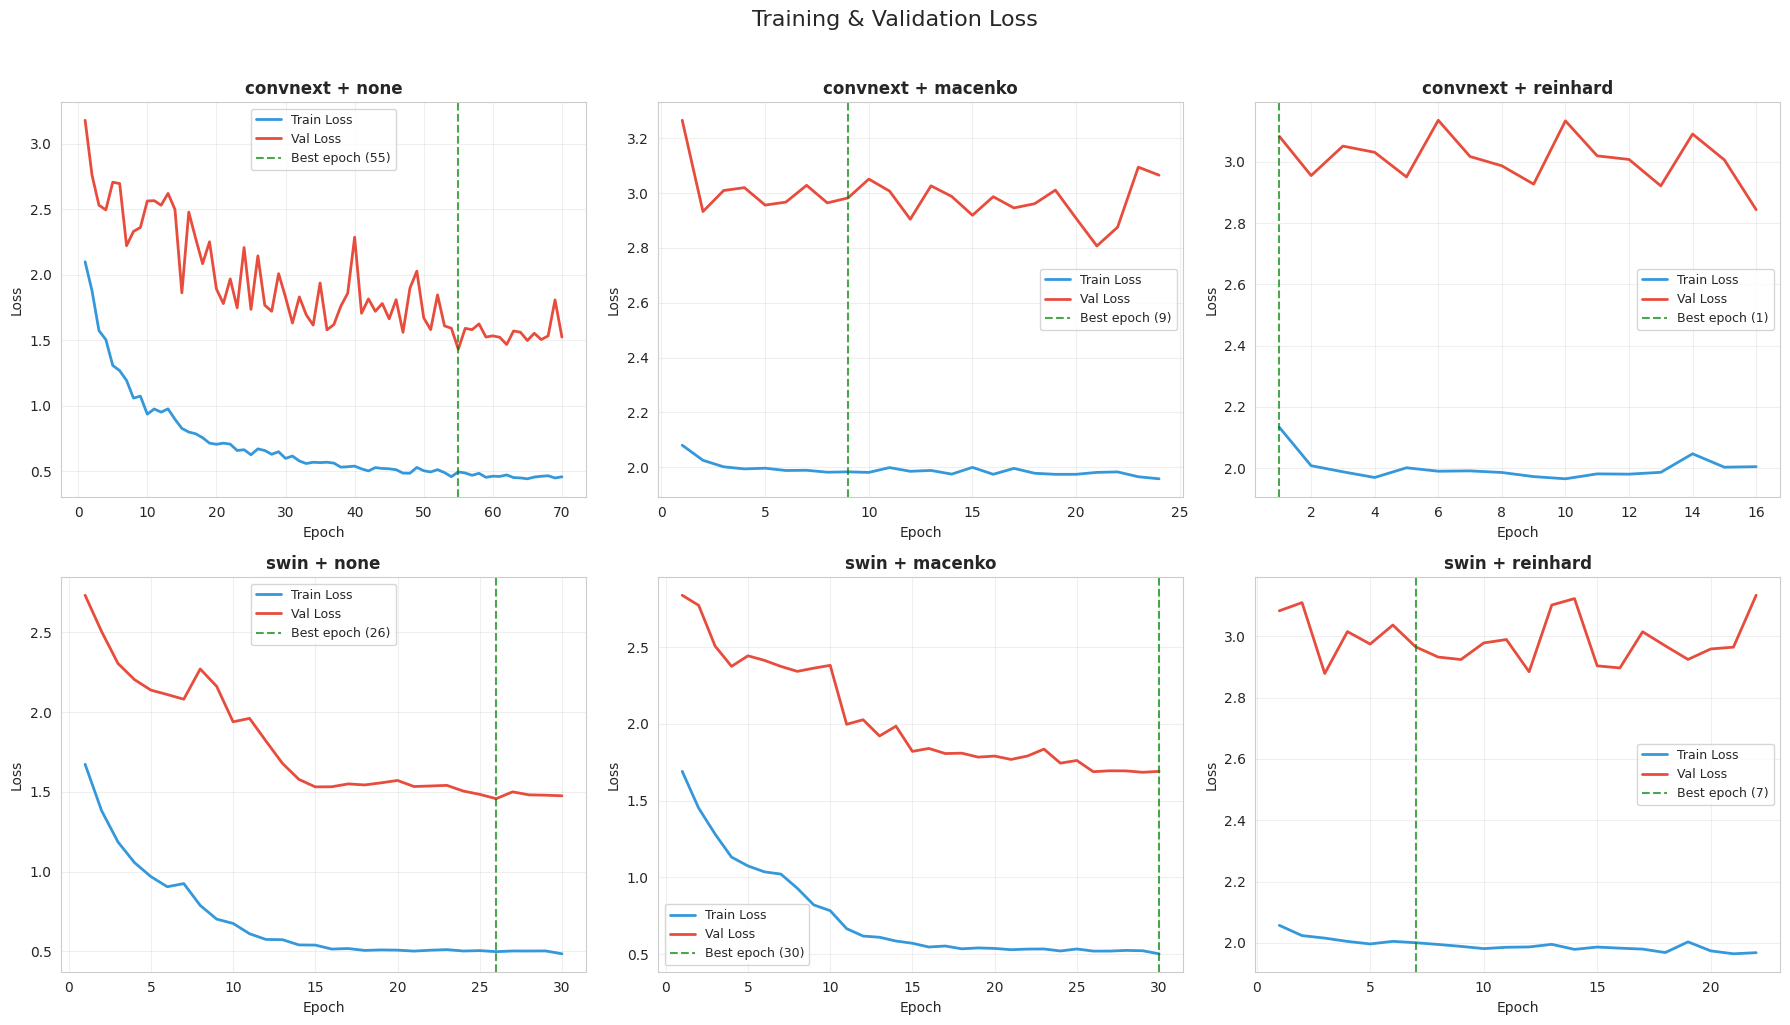

In [21]:
# 3.1 Loss curves - all experiments
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, stain_method in enumerate(STAIN_METHODS):
    for row, model_name in enumerate(MODEL_NAMES):
        ax = axes[row, col]
        exp_name = f"{model_name}_{stain_method}"
        h = all_results[exp_name]["history"]
        
        ax.plot(h["epoch"], h["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
        ax.plot(h["epoch"], h["val_loss"], label="Val Loss", color="#e74c3c", linewidth=2)
        
        best_idx = int(np.argmax(h["val_f1"]))
        ax.axvline(x=h["epoch"][best_idx], color="green", linestyle="--", alpha=0.7, label=f"Best epoch ({h['epoch'][best_idx]})")
        
        ax.set_title(f"{model_name} + {stain_method}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle("Training & Validation Loss", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "learning_curves_loss.png"), dpi=150, bbox_inches="tight")
plt.show()

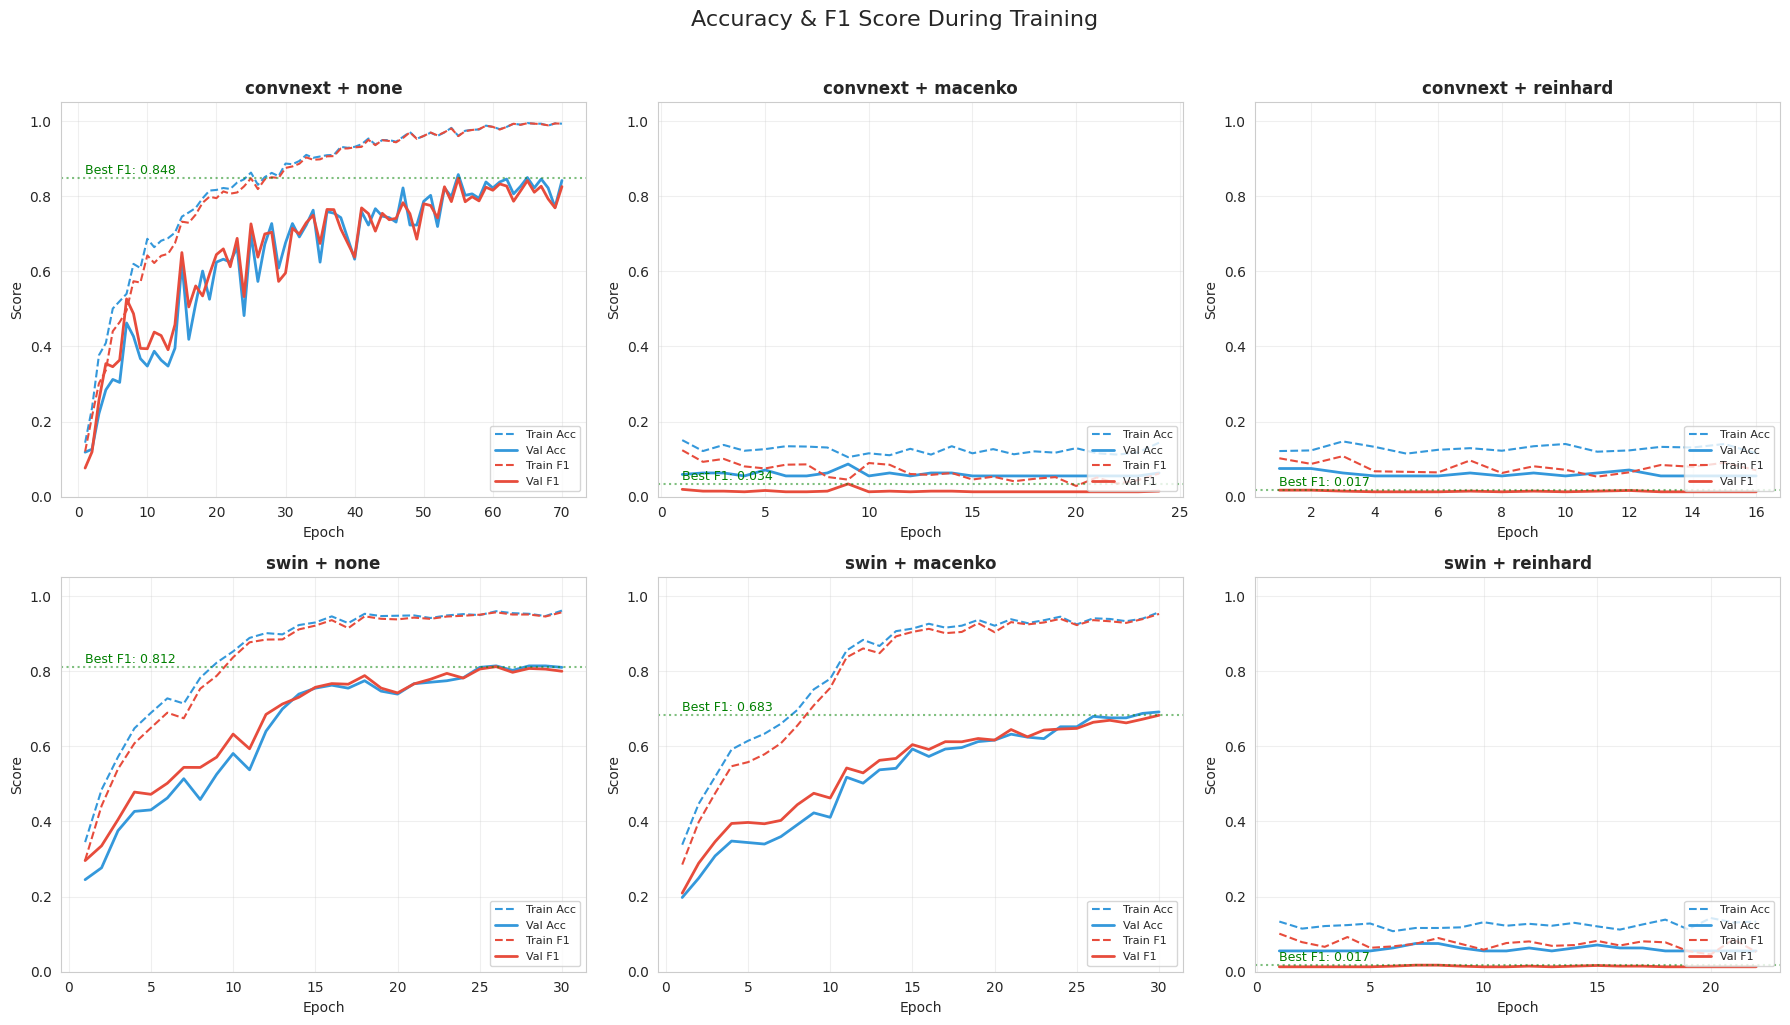

In [22]:
# 3.2 Accuracy and F1 curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, stain_method in enumerate(STAIN_METHODS):
    for row, model_name in enumerate(MODEL_NAMES):
        ax = axes[row, col]
        exp_name = f"{model_name}_{stain_method}"
        h = all_results[exp_name]["history"]
        
        ax.plot(h["epoch"], h["train_acc"], label="Train Acc", color="#3498db", linewidth=1.5, linestyle="--")
        ax.plot(h["epoch"], h["val_acc"], label="Val Acc", color="#3498db", linewidth=2)
        ax.plot(h["epoch"], h["train_f1"], label="Train F1", color="#e74c3c", linewidth=1.5, linestyle="--")
        ax.plot(h["epoch"], h["val_f1"], label="Val F1", color="#e74c3c", linewidth=2)
        
        best_idx = int(np.argmax(h["val_f1"]))
        ax.axhline(y=h["val_f1"][best_idx], color="green", linestyle=":", alpha=0.5)
        ax.text(1, h["val_f1"][best_idx] + 0.01, f"Best F1: {h['val_f1'][best_idx]:.3f}", fontsize=9, color="green")
        
        ax.set_title(f"{model_name} + {stain_method}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(True, alpha=0.3)
        

plt.suptitle("Accuracy & F1 Score During Training", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "learning_curves_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()

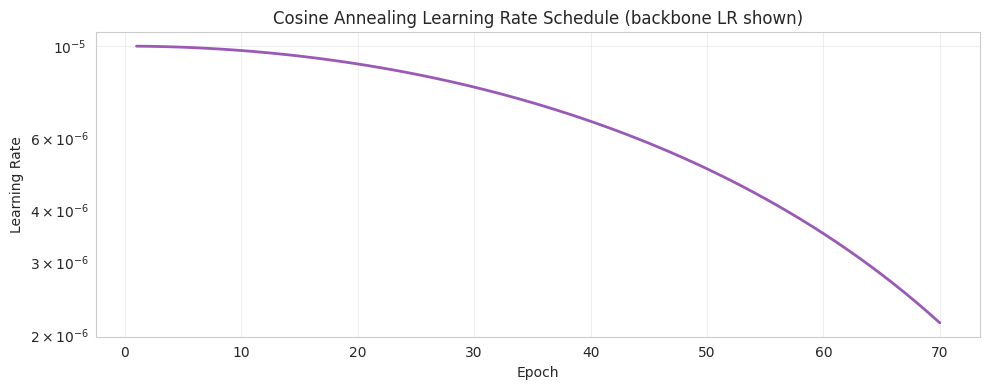

In [10]:
# 3.3 Learning rate schedule
fig, ax = plt.subplots(figsize=(10, 4))

# Just show one experiment's LR curve (they're all the same schedule)
first_exp = list(all_results.keys())[0]
h = all_results[first_exp]["history"]
ax.plot(h["epoch"], h["lr"], color="#9b59b6", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Cosine Annealing Learning Rate Schedule (backbone LR shown)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "lr_schedule.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Results Comparison

### Key questions we're answering:
1. **Model comparison**: Is ConvNeXt or Swin better for histopathology?
2. **Stain normalization impact**: Does Macenko/Reinhard help, hurt, or not matter?
3. **Best combination**: Which model + stain method should we use going forward?

In [11]:
# 4.1 Best validation F1 comparison
results_summary = []
for exp_name, result in all_results.items():
    h = result["history"]
    best_idx = int(np.argmax(h["val_f1"]))
    model_name, stain = exp_name.split("_", 1)
    results_summary.append({
        "Model": model_name,
        "Stain Method": stain,
        "Best Val F1": h["val_f1"][best_idx],
        "Best Val Acc": h["val_acc"][best_idx],
        "Best Epoch": h["epoch"][best_idx],
        "Total Epochs": len(h["epoch"]),
        "Final Train Loss": h["train_loss"][-1],
        "Final Val Loss": h["val_loss"][-1],
    })

df_results = pd.DataFrame(results_summary)
df_results = df_results.sort_values("Best Val F1", ascending=False).reset_index(drop=True)
print("\nResults ranked by Best Validation F1:\n")
print(df_results.to_string(index=False))

# Save
df_results.to_csv(os.path.join(RESULTS_DIR, "ablation_study_results.csv"), index=False)


Results ranked by Best Validation F1:

   Model Stain Method  Best Val F1  Best Val Acc  Best Epoch  Total Epochs  Final Train Loss  Final Val Loss
convnext         none     0.847950      0.857708          55            70          0.458085        1.523944
    swin         none     0.250939      0.229249          88           100          1.415448        2.676027
convnext      macenko     0.095432      0.106719          44            59          1.863883        3.400459
    swin      macenko     0.090897      0.094862          32            47          1.937799        2.938533
convnext     reinhard     0.017463      0.075099           1            16          1.966751        3.009979
    swin     reinhard     0.017463      0.075099           8            23          2.018339        3.047767


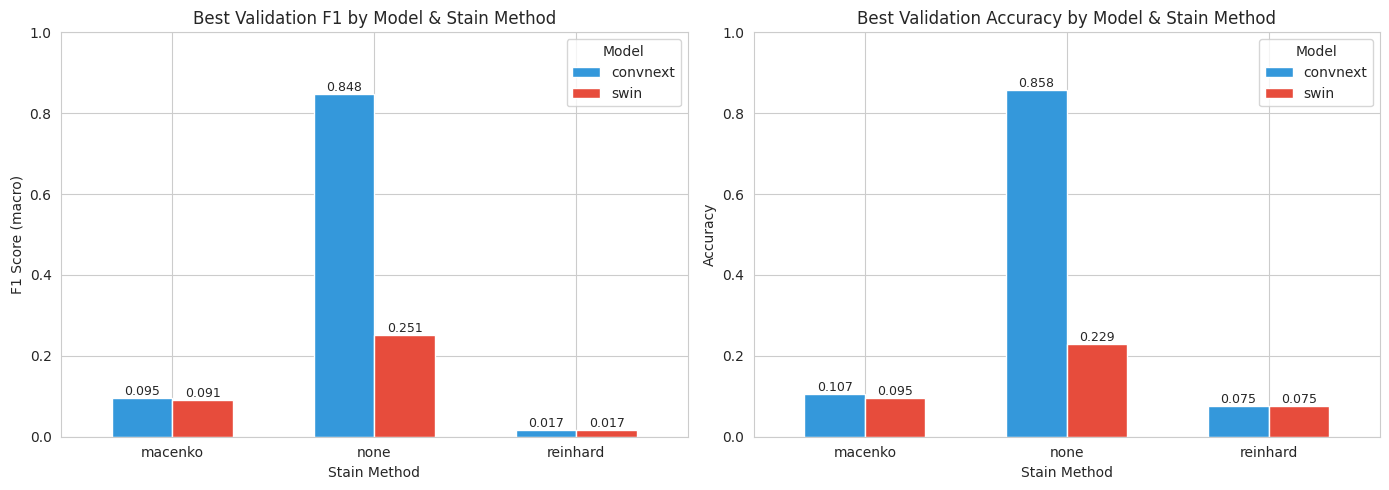

In [12]:
# 4.2 Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 by model and stain method
pivot_f1 = df_results.pivot(index="Stain Method", columns="Model", values="Best Val F1")
pivot_f1.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"], width=0.6)
axes[0].set_title("Best Validation F1 by Model & Stain Method")
axes[0].set_ylabel("F1 Score (macro)")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Model")
axes[0].tick_params(axis="x", rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=9)

# Accuracy comparison
pivot_acc = df_results.pivot(index="Stain Method", columns="Model", values="Best Val Acc")
pivot_acc.plot(kind="bar", ax=axes[1], color=["#3498db", "#e74c3c"], width=0.6)
axes[1].set_title("Best Validation Accuracy by Model & Stain Method")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Model")
axes[1].tick_params(axis="x", rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ablation_study_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# 4.3 Analyze effects

# Model effect (averaging across stain methods)
print("MODEL EFFECT (averaged across stain methods):")
for model in ["convnext", "swin"]:
    mask = df_results["Model"] == model
    avg_f1 = df_results[mask]["Best Val F1"].mean()
    avg_acc = df_results[mask]["Best Val Acc"].mean()
    print(f"  {model:<12s} Avg F1: {avg_f1:.4f}  Avg Acc: {avg_acc:.4f}")

# Stain effect (averaging across models)
print("\nSTAIN NORMALIZATION EFFECT (averaged across models):")
for stain in STAIN_METHODS:
    mask = df_results["Stain Method"] == stain
    avg_f1 = df_results[mask]["Best Val F1"].mean()
    avg_acc = df_results[mask]["Best Val Acc"].mean()
    print(f"  {stain:<12s} Avg F1: {avg_f1:.4f}  Avg Acc: {avg_acc:.4f}")

# Best overall
best_row = df_results.iloc[0]
print(f"\nBEST COMBINATION: {best_row['Model']} + {best_row['Stain Method']}")
print(f"  F1: {best_row['Best Val F1']:.4f}  Acc: {best_row['Best Val Acc']:.4f}  (epoch {int(best_row['Best Epoch'])})")

MODEL EFFECT (averaged across stain methods):
  convnext     Avg F1: 0.3203  Avg Acc: 0.3465
  swin         Avg F1: 0.1198  Avg Acc: 0.1331

STAIN NORMALIZATION EFFECT (averaged across models):
  none         Avg F1: 0.5494  Avg Acc: 0.5435
  macenko      Avg F1: 0.0932  Avg Acc: 0.1008
  reinhard     Avg F1: 0.0175  Avg Acc: 0.0751

BEST COMBINATION: convnext + none
  F1: 0.8480  Acc: 0.8577  (epoch 55)


## Summary

### What we trained:
- **6 models**: 2 architectures (ConvNeXt, Swin) x 3 stain methods (none, macenko, reinhard)
- All with identical hyperparameters for a fair comparison

### Key outputs saved:
- **Model checkpoints**: `weights/{experiment_name}/best_model.pth` - used in notebooks 04 and 05
- **Training histories**: `results/{experiment_name}/training_history.csv` - the learning curves
- **Ablation results**: `results/ablation_study_results.csv` - the summary table

### What happens next:
- **Notebook 04** (Evaluation): Load the best checkpoint for each experiment and evaluate on the held-out **test set** (which the model has never seen)
- **Notebook 05** (Explainability): Generate XAI explanations and evaluate them quantitatively